## Init

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import sys
from pathlib import Path
import xarray as xr
import cfgrib
import cartopy.crs as ccrs  # Projeções de mapas.
import cartopy.feature as cfeature  # Elementos geográficos.
from matplotlib.tri import Triangulation

#Import local libraries
import aux

In [2]:
var_dict={
    "ISR": {
        "era5_name" : "ssrd",
        "era5_longname" :"surface_solar_radiation_downwards",
        "ceres_name" : "adj_all_sw_dn", 
        "monan_name" : "swdnb",
        "unit" : "W m^{-2}",
        "label" : "Surface shortwave radiation downwards",
        "convert_to_flux": "yes",
        "vmin" : 0,
        "vmax" : 1300,
        "vmin_diff" : -200,
        "vmax_diff" : 200,
    },
    "ISRC": {
        "era5_name" : "ssrdc",
        "era5_longname" :"surface_solar_radiation_downward_clear_sky",
        "ceres_name" : "adj_clr_sw_dn", 
        "monan_name" : "swdnbc",
        "unit" : "W m^{-2}",
        "label" : "Surface shortwave radiation downwards (clear sky)",
        "convert_to_flux": "yes",
        "vmin" : 0,
        "vmax" : 1300,
        "vmin_diff" : -200,
        "vmax_diff" : 200,
    },
    "OLR": {
        "era5_name": "ttr",
        "era5_longname" :"top_net_thermal_radiation",
        "ceres_name" : "adj_all_lw_up", 
        "monan_name" : "lwupt",
        "unit" : "W m^{-2}",
        "label" : "TOA Outgoing longwave radiation",
        "convert_to_flux": "yes",
        "vmin" : -400,
        "vmax" : 0
    },
    "OLRC": {
        "era5_name" : "ttrc",
        "era5_longname" : "top_net_thermal_radiation_clear_sky",
        "ceres_name" : "adj_clr_lw_up", 
        "monan_name" : "lwuptc",
        "unit" : "W m^{-2}",
        "label" : "TOA Outgoing longwave radiation (clear sky)",
        "convert_to_flux": "yes",
        "vmin" : -400,
        "vmax" : 0,
        "vmin_diff" : -50,
        "vmax_diff" : 50
    },
    "TISR": {
        "era5_name" : "tisr",
        "era5_longname" : "toa_incident_solar_radiation",
        "ceres_name" : "toa_sw_insol", 
        "monan_name" : "swdnt",
        "unit" : "W m^{-2}",
        "label" : "TOA incident short-wave (solar) radiation",
        "convert_to_flux": "yes",
        "vmin" : 0,
        "vmax" : 1300,
        "vmin_diff" : -50,
        "vmax_diff" : 50
    },
    "PC": {
        "era5_name" : "tclw",
        "era5_longname" :"total_column_cloud_liquid_water",
        "ceres_name" : "obs_cld_lwp", 
        "monan_name" : "precipcloud",
        "unit" : "kg*m^{-2}",
        "label" : "Total column cloud liquid water",
        "vmin" : 0.05,
        "vmax" : 1,
        "vmin_diff" : -2,
        "vmax_diff" : 2,
        "convert_to_flux": "no",
    },
    "PI": {
        "era5_name": "tciw",
        "era5_longname" :"total_column_cloud_ice_water",
        "ceres_name" : "obs_cld_iwp", 
        "monan_name" : "precipice",
        "unit" : "kg*m^{-2}",
        "label" : "Total column cloud ice water",
        "vmin" : 0.05,
        "vmax" : 1,
        "vmin_diff" : -2,
        "vmax_diff" : 2,
        "convert_to_flux": "no",
    },
    "PI+PC": {
        "era5_name" : ["tciw", "tclw"],
        "era5_longname" : ["total_column_cloud_ice_water", "total_column_cloud_liquid_water"],
        "ceres_name" : ["obs_cld_iwp", "obs_cld_lwp"], 
        "monan_name" : ["precipice", "precipcloud"],
        "unit" : "kg*m^{-2}",
        "label" : "Total column cloud condensate (ice + liquid)",
        "vmin" : 0.05,
        "vmax" : 1.0,
        "vmin_diff" : -1.0,
        "vmax_diff" : 1.0,
        "convert_to_flux": "no",
    },
    "PW": {
        "era5_name" : "tcwv",
        "era5_longname" :"total_column_water_vapour",
        "ceres_name" : "adj_pw", 
        "monan_name" : "precipw",
        "unit" : "kg*m^{-2}",
        "label" : "Precipitable water",
        "vmin" : 10,
        "vmax" : 60,
        "vmin_diff" : -20,
        "vmax_diff" : 20,
        "convert_to_flux": "no",
    },
     "RAINC": {
        "era5_name" : "cp",
        "era5_longname" : "convective_precipitation",
        "ceres_name" : "", 
        "monan_name" : "rainc",
        "unit" : "mm",
        "label" : "Convective precipitation",
        "vmin" : 1,
        "vmax" : 200,
        "vmin_diff" : -100,
        "vmax_diff" : 100,
        "convert_to_flux": "no",
    }, 
     "RAIN": {
        "era5_name" : "tp",
        "era5_longname" : "gridbox_precipitation",
        "ceres_name" : "", 
        "monan_name" : "rainnc",
        "unit" : "mm",
        "label" : "Total precipitation",
        "vmin" : 1,
        "vmax" : 200,
        "vmin_diff" : -100,
        "vmax_diff" : 100,
        "convert_to_flux": "no",
    },  
    "CAPE": {
        "era5_name" : "cape",
        "era5_longname" : "convective_available_potential_energy",
        "ceres_name" : "cape", 
        "monan_name" : "cape",
        "unit" : "J kg^{-1}",
        "label" : "Convective available potential energy",
        "convert_to_flux": "no",
        "vmin" : 0,
        "vmax" : 2000
    },
    "CIN": {
        "era5_name" : "cin",
        "era5_longname" : "convective_inhibition",
        "ceres_name" : "cin", 
        "monan_name" : "cin",
        "unit" : "J kg^{-1}",
        "label" : "Convective inhibition",
        "convert_to_flux": "no",
        "vmin" : 0,
        "vmax" : 300
    }
}

surf_flux_dict={
    "HF": {
        "era5_name" : "sshf",
        "era5_longname" : "surface_sensible_heat_flux",
        "monan_name" : "hfx", 
        "unit" : "W/m**2",
        "label" : "Sensible heat flux"
    },
    "LF": {
        "era5_name": "sslf",
        "era5_longname":"surface_latent_heat_flux",
        "monan_name": "lf", 
        "unit": "W m^{-2}",
        "label": "Latent heat flux"
    }
}

profile_vars_dict={
    "ISR": {
        "monan_name" : "ssrd",
        "ceres_name" : "adj_all_sw_dn",
        "unit" : "W m^{-2}",
        "label" : "Incoming shortwave radiation"
    },
    "OSR": {
        "monan_name" : "ssrd",
        "ceres_name" : "adj_all_sw_up", 
        "unit" : "W m^{-2}",
        "label" : "Outgoing shortwave radiation"
    },
    "ILR": {
        "monan_name" : "ttrc",
        "ceres_name" : "adj_all_lw_dn", 
        "unit" : "W m^{-2}",
        "label" : "Incoming longwave radiation"
    },
    "OLR": {
        "monan_name" : "ttr",
        "ceres_name" : "adj_all_lw_up", 
        "unit" : "W m^{-2}",
        "label" : "Outgoing longwave radiation"
    }    
}

In [3]:
extents={"Amaz_reg":{
            "extent":[-90, -30, -20, 20],
            "label":"South America"},
        # "Global":{
        #     "extent":[-180, 180, -90, 90],
        #     "label":"Global"},
        }


cldfrac_vars = ["cldfrac_low_UPP", "cldfrac_mid_UPP", "cldfrac_high_UPP", "cldfrac_tot_UPP"]
cldfrac_labels = {
    "cldfrac_low_UPP":  "Low cloud fraction",
    "cldfrac_mid_UPP":  "Mid cloud fraction",
    "cldfrac_high_UPP": "High cloud fraction",
    "cldfrac_tot_UPP":  "Total cloud fraction",
}
fig_path="/p/projetos/monan_atm/madeleine.gacita/figuras/"


## Teste vars in monan

In [ ]:
init='2025030700'
datetime_analysis = '2025030716'   # datetime of interest for analysis (e.g., 16Z of the same day)
year='2025'
month='03'
base_dir='/p/projetos/monan_atm/madeleine.gacita/global_data/'
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")
resolution = 'x655362L55'  # 'regional' or 'global'
name_initcond='REGNOL2'

monan_path = Path(f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc")
if not monan_path.exists():
    print(f"  ✗ MONAN file not found for {monan_path}")
else:
    ds_pdf = xr.open_dataset(monan_path, engine="netcdf4")
    print(ds_pdf.variables)

Frozen({'initial_time': <xarray.Variable ()> Size: 64B
[1 values with dtype=|S64]
Attributes:
    units:      YYYY-MM-DD_hh:mm:ss
    long_name:  Model initialization time, 'xtime': <xarray.Variable (Time: 1)> Size: 64B
[1 values with dtype=|S64]
Attributes:
    units:      YYYY-MM-DD_hh:mm:ss
    long_name:  Model valid time, 't_iso_levels': <xarray.Variable (nIsoLevelsT: 18)> Size: 72B
[18 values with dtype=float32]
Attributes:
    units:      Pa
    long_name:  Levels for vertical interpolation of temperature to isobaric ..., 'zgeo_isobaric': <xarray.Variable (Time: 1, nCells: 21593, t_iso_levels: 18)> Size: 2MB
[388674 values with dtype=float32]
Attributes:
    units:      m
    long_name:  Geopotential height interpolated to isobaric surfaces defined..., 'lonCell': <xarray.Variable (nCells: 21593)> Size: 86kB
[21593 values with dtype=float32]
Attributes:
    units:      rad
    long_name:  Longitude of cells, 'latCell': <xarray.Variable (nCells: 21593)> Size: 86kB
[21593 values wi

In [10]:
regions = [
    {
        "key": "R1",
        "name": "R1 (11 to 13 lat; -69 to -66 lon)",
        "lat_min": 9.0,
        "lat_max": 13.0,
        "lon_min": -69.0,
        "lon_max": -64.0,
    },
    {
        "key": "R2",
        "name": "R2 (-15 to -10 lat; -60 to -50 lon)",
        "lat_min": -15.0,
        "lat_max": -10.0,
        "lon_min": -60.0,
        "lon_max": -50.0,
    },
]


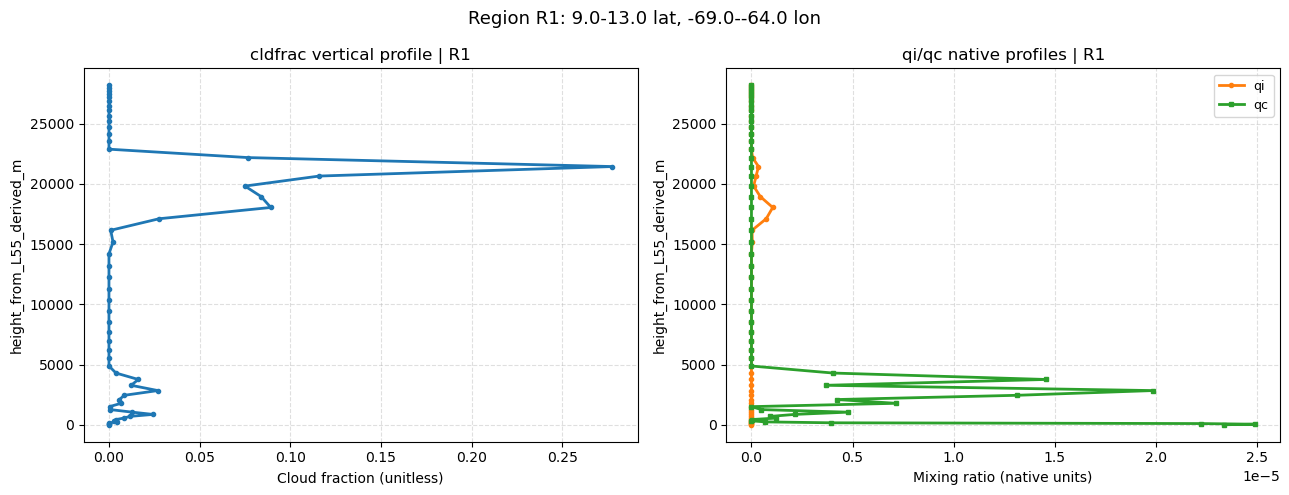

Using derived heights file: /p/projetos/monan_atm/madeleine.gacita/scripts_download_process_plot/radiation/L55_derived.txt
Saved panel: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_cldfrac_qi_qc_panel_R1_2025030718.png
R1 (11 to 13 lat; -69 to -66 lon) -> selected cells: 288
  qi status: ok
  qc status: ok


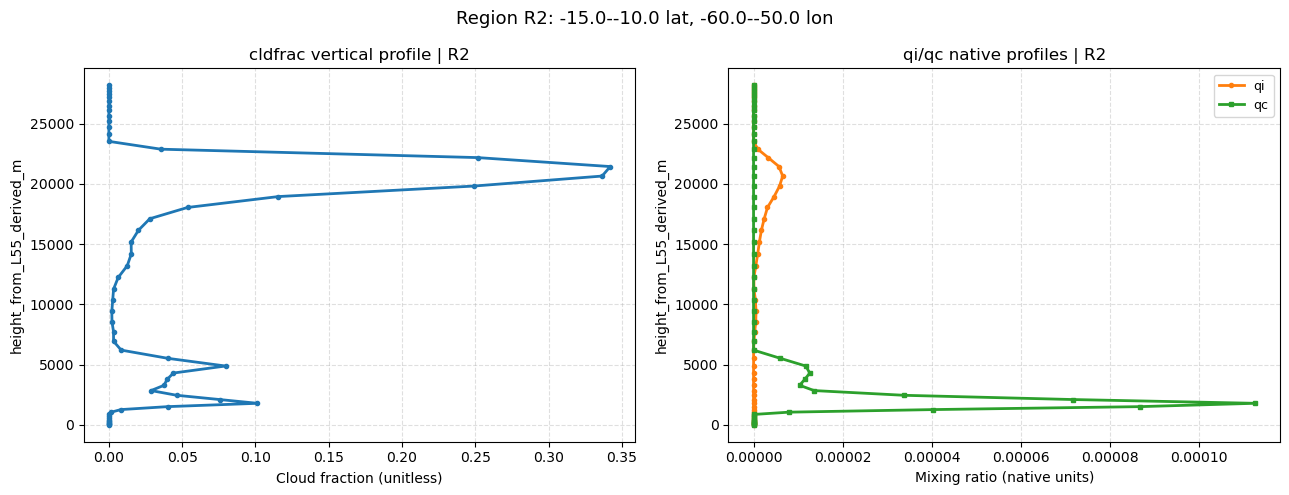

Using derived heights file: /p/projetos/monan_atm/madeleine.gacita/scripts_download_process_plot/radiation/L55_derived.txt
Saved panel: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_cldfrac_qi_qc_panel_R2_2025030718.png
R2 (-15 to -10 lat; -60 to -50 lon) -> selected cells: 781
  qi status: ok
  qc status: ok


In [11]:
# Regional panel: cldfrac + qi/qc vertical profiles (one figure per region)

if "regions" not in globals() or not isinstance(regions, list) or len(regions) == 0:
    raise RuntimeError("regions is not defined. Run the regions definition cell first.")

if "ds_pdf" not in globals():
    raise RuntimeError("ds_pdf is not loaded. Run the previous cell that opens the MONAN file.")
if "cldfrac" not in ds_pdf.data_vars:
    raise KeyError("Variable 'cldfrac' not found in ds_pdf.")
if "latCell" not in ds_pdf.variables or "lonCell" not in ds_pdf.variables:
    raise KeyError("Expected 'latCell' and 'lonCell' in ds_pdf variables.")

if "fig_path" not in globals() or not str(fig_path).strip():
    fig_path = "/p/projetos/monan_atm/madeleine.gacita/figuras/"
Path(fig_path).mkdir(parents=True, exist_ok=True)

# Load derived 55-level heights (midpoints)
heights_file = Path("/p/projetos/monan_atm/madeleine.gacita/scripts_download_process_plot/radiation/L55_derived.txt")
if not heights_file.exists():
    raise FileNotFoundError(f"Derived heights file not found: {heights_file}")
heights_55 = np.loadtxt(heights_file, dtype=float)
if heights_55.ndim != 1 or heights_55.size != 55:
    raise ValueError(f"Expected 55 heights in {heights_file}, found shape={heights_55.shape}")

# Build degree-based lat/lon vectors once
lat = ds_pdf["latCell"]
lon = ds_pdf["lonCell"]
if float(np.nanmax(np.abs(lat.values))) <= np.pi + 0.1:
    lat = np.rad2deg(lat)
if float(np.nanmax(np.abs(lon.values))) <= 2.0 * np.pi + 0.1:
    lon = np.rad2deg(lon)
lon_180 = ((lon + 180.0) % 360.0) - 180.0

# Vertical-dimension candidates (include native isobaric-level dim name)
vert_candidates = ["t_iso_levels", "nIsoLevelsT", "t_iso_level", "nVertLevels", "level", "lev", "plev", "isobaricInhPa", "height", "z"]

# Helper: choose y-axis values, using derived heights when profile has 55 levels
def get_y_for_profile(prof, vdim):
    y = np.asarray(prof[vdim].values, dtype=float)
    if y.size == 55:
        return heights_55, "height_from_L55_derived_m"
    return y, vdim

# Helper: keep surface (0) at bottom for height-like coordinates
def maybe_invert_yaxis(ax, yvals, y_label):
    yl = str(y_label).lower()
    is_height_like = (
        "height" in yl
        or "zgeo" in yl
        or "nvertlevels" in yl
        or "nisolevelst" in yl
        or "t_iso_levels" in yl
    )
    if is_height_like:
        return
    if np.nanmax(yvals) > 200 and np.nanmin(yvals) >= 0:
        ax.invert_yaxis()

# Helper to compute 1-D vertical profile for any variable/coordinate
def compute_profile(var_name, region_mask):
    if var_name in ds_pdf.data_vars:
        da_v = ds_pdf[var_name]
    elif var_name in ds_pdf.variables or var_name in ds_pdf.coords:
        da_v = ds_pdf[var_name]
    else:
        return None, None, "missing"

    # Apply spatial mask only for fields defined on cells
    if "nCells" in da_v.dims:
        da_v = da_v.where(region_mask)

    v_vert_dim = next((d for d in vert_candidates if d in da_v.dims), None)
    if v_vert_dim is None:
        return None, None, f"no vertical dim in {da_v.dims}"

    prof = da_v.mean(dim=[d for d in da_v.dims if d != v_vert_dim], skipna=True)
    return prof, v_vert_dim, "ok"

def compute_first_available_profile(var_names, region_mask):
    for var_name in var_names:
        prof, vdim, status = compute_profile(var_name, region_mask)
        if status == "ok":
            return var_name, prof, vdim, status
    return var_names[0], None, None, "missing"

for reg in regions:
    region_mask = (
        (lat >= reg["lat_min"]) & (lat <= reg["lat_max"]) &
        (lon_180 >= reg["lon_min"]) & (lon_180 <= reg["lon_max"])
    )
    npts = int(region_mask.sum().values) if hasattr(region_mask.sum(), "values") else int(region_mask.sum())

    # cldfrac profile
    da_cld = ds_pdf["cldfrac"].where(region_mask)
    vert_dim_cld = next((d for d in vert_candidates if d in da_cld.dims), None)
    if vert_dim_cld is None:
        raise KeyError(f"Could not detect vertical dimension in cldfrac dims: {da_cld.dims}")
    profile_cld = da_cld.mean(dim=[d for d in da_cld.dims if d != vert_dim_cld], skipna=True)
    y_cld, y_cld_label = get_y_for_profile(profile_cld, vert_dim_cld)

    # qi/qc native profiles
    qi_name, qi_prof, qi_vdim, qi_status = compute_first_available_profile(["qi"], region_mask)
    pc_name, pc_prof, pc_vdim, pc_status = compute_first_available_profile(["pc", "qc"], region_mask)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax00, ax01 = axes

    # Left panel: cldfrac
    ax00.plot(profile_cld.values, y_cld, color="tab:blue", lw=2, marker="o", ms=3)
    ax00.set_xlabel("Cloud fraction (unitless)")
    ax00.set_ylabel(y_cld_label)
    ax00.set_title(f"cldfrac vertical profile | {reg['key']}")
    ax00.grid(True, ls="--", alpha=0.4)
    maybe_invert_yaxis(ax00, y_cld, y_cld_label)

    # Right panel: qi/qc
    n_lines = 0
    if qi_status == "ok":
        x_qi = np.asarray(qi_prof.values, dtype=float)
        y_qi, y_qi_label = get_y_for_profile(qi_prof, qi_vdim)
        ax01.plot(x_qi, y_qi, color="tab:orange", lw=2, marker="o", ms=3, label=qi_name)
        n_lines += 1
    if pc_status == "ok":
        x_pc = np.asarray(pc_prof.values, dtype=float)
        y_pc, y_pc_label = get_y_for_profile(pc_prof, pc_vdim)
        ax01.plot(x_pc, y_pc, color="tab:green", lw=2, marker="s", ms=3, label=pc_name)
        n_lines += 1

    if n_lines > 0:
        ax01.set_xlabel("Mixing ratio (native units)")
        y_ref = y_qi if qi_status == "ok" else y_pc
        y_ref_label = y_qi_label if qi_status == "ok" else y_pc_label
        ax01.set_ylabel(y_ref_label)
        ax01.set_title(f"{qi_name}/{pc_name} native profiles | {reg['key']}")
        ax01.grid(True, ls="--", alpha=0.4)
        ax01.legend(loc="best", fontsize=9)
        maybe_invert_yaxis(ax01, y_ref, y_ref_label)
    else:
        ax01.text(0.5, 0.55, "No qi/qc profile available", ha="center", va="center", transform=ax01.transAxes)
        ax01.text(0.5, 0.45, f"{qi_name}: {qi_status} | {pc_name}: {pc_status}", ha="center", va="center", fontsize=8, transform=ax01.transAxes)
        ax01.set_axis_off()

    fig.suptitle(
        f"Region {reg['key']}: {reg['lat_min']:.1f}-{reg['lat_max']:.1f} lat, {reg['lon_min']:.1f}-{reg['lon_max']:.1f} lon",
        fontsize=13,
    )
    plt.tight_layout()

    out_png = f"{fig_path}/MONAN_cldfrac_qi_qc_panel_{reg['key']}_{analysis_tag}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Using derived heights file: {heights_file}")
    print(f"Saved panel: {out_png}")
    print(f"{reg['name']} -> selected cells: {npts}")
    print(f"  {qi_name} status: {qi_status}")
    print(f"  {pc_name} status: {pc_status}")

In [12]:
# Mean of cldfrac_vars in the shared regions definition
if "regions" not in globals() or not isinstance(regions, list) or len(regions) == 0:
    raise RuntimeError("regions is not defined. Run the regions definition cell first.")

if "ds_pdf" not in globals():
    raise RuntimeError("ds_pdf is not loaded.")
if "cldfrac_vars" not in globals():
    raise RuntimeError("cldfrac_vars is not defined.")

# MONAN variables for surface downward shortwave all-sky / clear-sky
rad_mean_vars = {
    "ISR": "acswdnb",
    "ISRC": "acswdnbc",
}

lat = ds_pdf["latCell"]
lon = ds_pdf["lonCell"]

# Convert radians to degrees when needed (common in MPAS)
if float(np.nanmax(np.abs(lat.values))) <= np.pi + 0.1:
    lat = np.rad2deg(lat)
if float(np.nanmax(np.abs(lon.values))) <= 2.0 * np.pi + 0.1:
    lon = np.rad2deg(lon)

lon_180 = ((lon + 180.0) % 360.0) - 180.0

for reg in regions:
    region_mask = (
        (lat >= reg["lat_min"]) & (lat <= reg["lat_max"]) &
        (lon_180 >= reg["lon_min"]) & (lon_180 <= reg["lon_max"])
    )

    npts = int(region_mask.sum().values) if hasattr(region_mask.sum(), "values") else int(region_mask.sum())
    print(f"Selected cells in {reg['name']}: {npts}")
    print(f"Regional means for cldfrac_vars ({reg['name']}):")

    for vname in cldfrac_vars:
        if vname not in ds_pdf:
            print(f"  {vname}: variable not found in ds_pdf")
            continue

        da = ds_pdf[vname].where(region_mask)
        mean_val = float(da.mean(skipna=True).values)
        print(f"  {vname}: {mean_val:.6f}")

    print(f"Regional means for ISR/ISRC ({reg['name']}):")
    for label, varname in rad_mean_vars.items():
        if varname not in ds_pdf:
            print(f"  {label} ({varname}): variable not found in ds_pdf")
            continue

        da_rad = ds_pdf[varname].where(region_mask)
        rad_mean = float(da_rad.mean(skipna=True).values)
        units = da_rad.attrs.get("units", "native units")
        print(f"  {label} ({varname}): {rad_mean:.6f} {units}")

    print("-")

Selected cells in R1 (11 to 13 lat; -69 to -66 lon): 288
Regional means for cldfrac_vars (R1 (11 to 13 lat; -69 to -66 lon)):
  cldfrac_low_UPP: 0.097962
  cldfrac_mid_UPP: 0.003578
  cldfrac_high_UPP: 0.149966
  cldfrac_tot_UPP: 0.436584
Regional means for ISR/ISRC (R1 (11 to 13 lat; -69 to -66 lon)):
  ISR (acswdnb): 18620644.000000 W m^{-2}
  ISRC (acswdnbc): 19107516.000000 W m^{-2}
-
Selected cells in R2 (-15 to -10 lat; -60 to -50 lon): 781
Regional means for cldfrac_vars (R2 (-15 to -10 lat; -60 to -50 lon)):
  cldfrac_low_UPP: 0.205454
  cldfrac_mid_UPP: 0.102772
  cldfrac_high_UPP: 0.269915
  cldfrac_tot_UPP: 0.526536
Regional means for ISR/ISRC (R2 (-15 to -10 lat; -60 to -50 lon)):
  ISR (acswdnb): 20613574.000000 W m^{-2}
  ISRC (acswdnbc): 22441746.000000 W m^{-2}
-


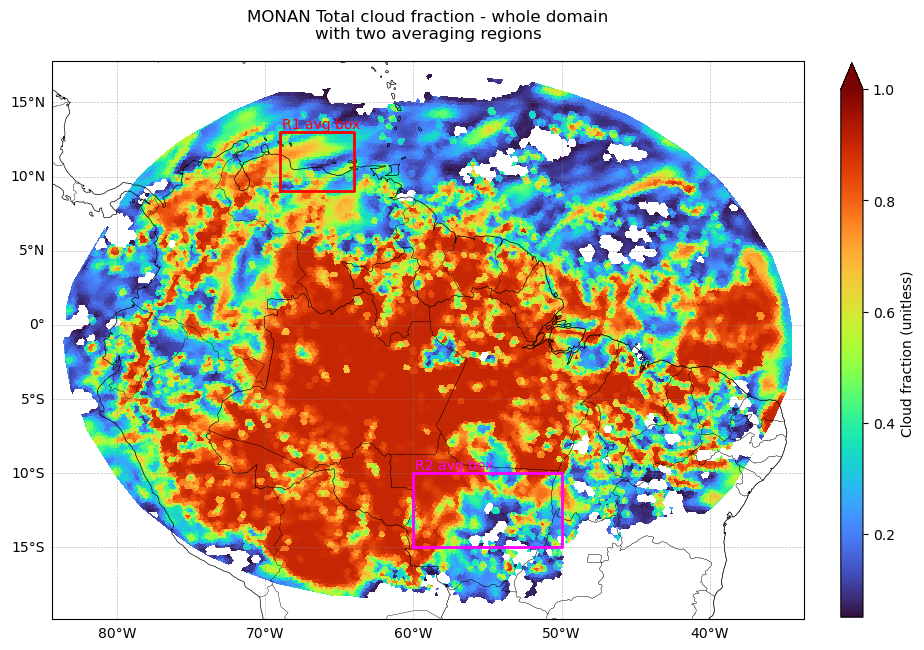

ISR computed from accumulation increment: MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030718.00.00.x655362L55.nc - MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030717.00.00.x655362L55.nc


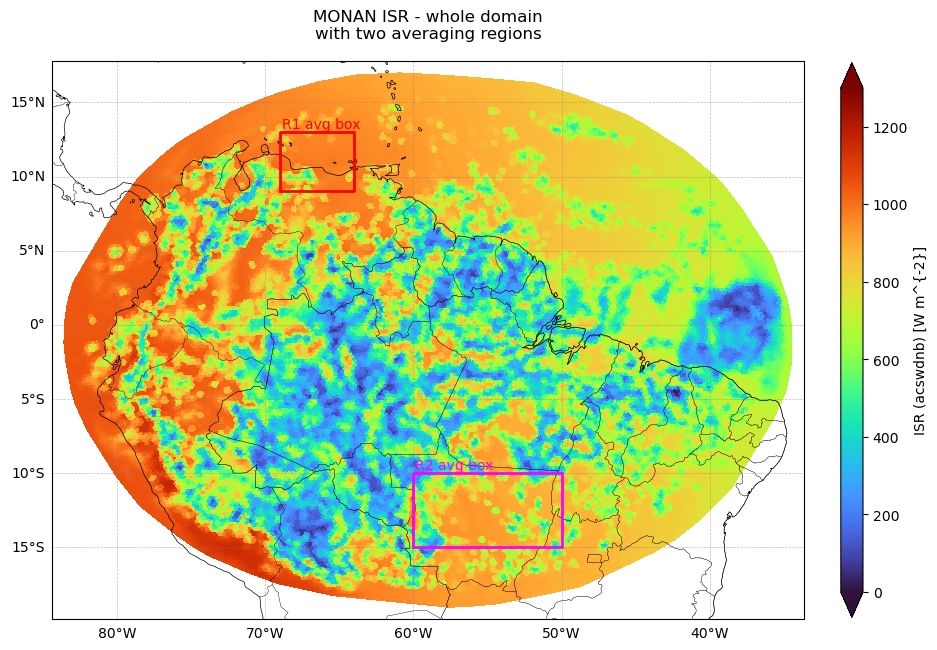

In [18]:
# Full-domain maps with shared averaging regions: cldfrac_tot_UPP + ISR
if "regions" not in globals() or not isinstance(regions, list) or len(regions) == 0:
    raise RuntimeError("regions is not defined. Run the regions definition cell first.")

if "ds_pdf" not in globals():
    raise RuntimeError("ds_pdf is not loaded.")
if "cldfrac_tot_UPP" not in ds_pdf.data_vars:
    raise KeyError("Variable 'cldfrac_tot_UPP' not found in ds_pdf.")
if "latCell" not in ds_pdf.variables or "lonCell" not in ds_pdf.variables:
    raise KeyError("Expected 'latCell' and 'lonCell' in ds_pdf variables.")

lat = ds_pdf["latCell"]
lon = ds_pdf["lonCell"]

# Convert radians to degrees when needed (common in MPAS grids)
if float(np.nanmax(np.abs(lat.values))) <= np.pi + 0.1:
    lat = np.rad2deg(lat)
if float(np.nanmax(np.abs(lon.values))) <= 2.0 * np.pi + 0.1:
    lon = np.rad2deg(lon)

lon_180 = ((lon + 180.0) % 360.0) - 180.0
lon_vals = np.asarray(lon_180.values, dtype=float)
lat_vals = np.asarray(lat.values, dtype=float)
cell_dim = "nCells"

region_colors = {"R1": "red", "R2": "magenta"}

def _draw_region_boxes(ax, regions, region_colors):
    for reg in regions:
        rkey = reg.get("key", "REG")
        color = region_colors.get(rkey, "black")
        box_lon = [reg["lon_min"], reg["lon_max"], reg["lon_max"], reg["lon_min"], reg["lon_min"]]
        box_lat = [reg["lat_min"], reg["lat_min"], reg["lat_max"], reg["lat_max"], reg["lat_min"]]
        ax.plot(box_lon, box_lat, color=color, linewidth=2.0, transform=ccrs.PlateCarree(), zorder=6)
        ax.text(
            reg["lon_min"] + 0.1,
            reg["lat_max"] + 0.25,
            f"{rkey} avg box",
            color=color,
            fontsize=10,
            transform=ccrs.PlateCarree(),
        )

def _domain_extent(lon_points, lat_points, pad_deg=0.8):
    return [
        float(np.nanmin(lon_points) - pad_deg),
        float(np.nanmax(lon_points) + pad_deg),
        float(np.nanmin(lat_points) - pad_deg),
        float(np.nanmax(lat_points) + pad_deg),
    ]

def _collapse_to_cells(da, cell_dim="nCells"):
    if cell_dim not in da.dims:
        raise KeyError(f"Expected '{cell_dim}' in dims: {da.dims}")
    extra_dims = [d for d in da.dims if d != cell_dim]
    if extra_dims:
        da = da.mean(dim=extra_dims, skipna=True)
    return np.asarray(da.values, dtype=float)

# ---------- Cloud fraction map ----------
da_tot = ds_pdf["cldfrac_tot_UPP"]
vals = _collapse_to_cells(da_tot, cell_dim=cell_dim)
valid = np.isfinite(vals) & np.isfinite(lon_vals) & np.isfinite(lat_vals)
lon_p = lon_vals[valid]
lat_p = lat_vals[valid]
val_p = vals[valid]

white_below = 0.05
if np.nanmax(val_p) > 1.5:
    val_p = val_p / 100.0

plot_cmap_obj = plt.get_cmap("turbo").copy()
plot_cmap_obj.set_bad("white")
plot_cmap_obj.set_under("white")

val_masked = np.ma.masked_invalid(np.where(val_p >= white_below, val_p, np.nan))
tri = Triangulation(lon_p, lat_p)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
tpc = ax.tripcolor(
    tri,
    val_masked,
    cmap=plot_cmap_obj,
    vmin=white_below,
    vmax=1.0,
    shading="flat",
    rasterized=True,
)

ax.set_extent(_domain_extent(lon_p, lat_p), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

_draw_region_boxes(ax, regions, region_colors)

cb = plt.colorbar(tpc, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="max")
cb.set_label("Cloud fraction (unitless)")
ax.set_title("MONAN Total cloud fraction - whole domain\nwith two averaging regions", fontsize=12, pad=16)

plt.tight_layout()
plt.savefig(f"{fig_path}/Total_cloud_fraction_regions.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- ISR map ----------
from pathlib import Path

isr_candidates = []
if "var_dict" in globals() and "ISR" in var_dict and "monan_name" in var_dict["ISR"]:
    isr_candidates.append(var_dict["ISR"]["monan_name"])
for fallback in ["acswdnb", "swdnb", "isr"]:
    if fallback not in isr_candidates:
        isr_candidates.append(fallback)

isr_name = next((v for v in isr_candidates if v in ds_pdf.data_vars), None)
if isr_name is None:
    raise KeyError(f"Could not find ISR variable in dataset. Candidates checked: {isr_candidates}")

da_isr = ds_pdf[isr_name]
isr_vals = _collapse_to_cells(da_isr, cell_dim=cell_dim)
isr_units = str(da_isr.attrs.get("units", "")).strip().lower()

dt_seconds = float(deltat * 3600.0) if "deltat" in globals() else 3600.0
is_accum = isr_name.startswith("ac") or ("j" in isr_units or "joule" in isr_units or np.nanmax(np.abs(isr_vals)) > 5000.0)

# For accumulated ISR fields, use current minus previous timestep to recover hourly flux variability.
if is_accum and dt_seconds > 0.0:
    curr_path = None
    if "monan_path" in globals() and monan_path is not None:
        curr_path = Path(monan_path)
    else:
        src = str(ds_pdf.encoding.get("source", "")).strip()
        if src:
            curr_path = Path(src)

    used_increment = False
    if curr_path is not None and curr_path.exists() and "datetime_analysis" in globals():
        curr_tag = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
        prev_tag = (curr_tag - pd.Timedelta(hours=float(deltat) if "deltat" in globals() else 1.0)).strftime("%Y%m%d%H")
        curr_stamp = f"_{curr_tag.strftime('%Y%m%d%H')}.00.00."
        prev_stamp = f"_{prev_tag}.00.00."
        prev_name = curr_path.name.replace(curr_stamp, prev_stamp)
        prev_path = curr_path.with_name(prev_name)

        if prev_path.exists():
            with xr.open_dataset(prev_path, engine="netcdf4") as ds_prev:
                if isr_name in ds_prev.data_vars:
                    prev_vals = _collapse_to_cells(ds_prev[isr_name], cell_dim=cell_dim)
                    isr_vals = (isr_vals - prev_vals) / dt_seconds
                    used_increment = True
                    print(f"ISR computed from accumulation increment: {curr_path.name} - {prev_path.name}")

    if not used_increment:
        isr_vals = isr_vals / dt_seconds
        print("Warning: previous timestep file not found; ISR used accumulated/dt fallback.")

valid_isr = np.isfinite(isr_vals) & np.isfinite(lon_vals) & np.isfinite(lat_vals)
lon_isr = lon_vals[valid_isr]
lat_isr = lat_vals[valid_isr]
val_isr = isr_vals[valid_isr]

if val_isr.size == 0:
    raise RuntimeError("No finite ISR points available for plotting.")

if "var_dict" in globals() and "ISR" in var_dict:
    vmin_isr = float(var_dict["ISR"].get("vmin", 0.0))
    vmax_isr = float(var_dict["ISR"].get("vmax", 1300.0))
else:
    vmin_isr = 0.0
    vmax_isr = 1300.0

plot_cmap_isr = plt.get_cmap("turbo").copy()
plot_cmap_isr.set_bad("white")

tri_isr = Triangulation(lon_isr, lat_isr)
val_isr_masked = np.ma.masked_invalid(val_isr)

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
tpc = ax.tripcolor(
    tri_isr,
    val_isr_masked,
    cmap=plot_cmap_isr,
    vmin=vmin_isr,
    vmax=vmax_isr,
    shading="flat",
    rasterized=True,
)

ax.set_extent(_domain_extent(lon_isr, lat_isr), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

_draw_region_boxes(ax, regions, region_colors)

cb = plt.colorbar(tpc, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="both")
cb.set_label(f"ISR ({isr_name}) [W m^{{-2}}]")
ax.set_title("MONAN ISR - whole domain\nwith two averaging regions", fontsize=12, pad=16)

plt.tight_layout()
plt.savefig(f"{fig_path}/ISR_regions.png", dpi=150, bbox_inches="tight")
plt.show()

## Init analysis

In [27]:
init='2025030700'
datetime_analysis = '2025030716'   # datetime of interest for analysis (e.g., 16Z of the same day)
year='2025'
month='03'
base_dir='/p/projetos/monan_atm/madeleine.gacita/global_data/'
exps_data={
    "CTRL": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/CTRL/"},
    "TIEDTKE": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/TIEDTKE/"},
    "MESO_cld_monan": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/MESO_cld_fraction_monan/"},
    "MESO_cu_GF": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/MESO_cu_GF/"},
    "MESO_mp_thompson": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/MESO_mp_thompson/"},
    "MESO_bl_mynn": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/MESO_bl_mynn/"},
    "MESO_mynn_edmf_1": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/REGNOL2/MESO_mynn_edmf_1_bl/"},
}
extents={"Amaz_reg":{
            "extent":[-90, -30, -20, 20],
            "label":"South America"},
        # "Global":{
        #     "extent":[-180, 180, -90, 90],
        #     "label":"Global"},
        }


cldfrac_vars = ["cldfrac_low_UPP", "cldfrac_mid_UPP", "cldfrac_high_UPP", "cldfrac_tot_UPP"]
cldfrac_labels = {
    "cldfrac_low_UPP":  "Low cloud fraction",
    "cldfrac_mid_UPP":  "Mid cloud fraction",
    "cldfrac_high_UPP": "High cloud fraction",
    "cldfrac_tot_UPP":  "Total cloud fraction",
}


# Derived date range from init + forecast_length_h
init_dt = pd.to_datetime(init, format='%Y%m%d%H')
end_dt = pd.to_datetime(datetime_analysis, format='%Y%m%d%H')
resolution = 'x655362L55'  # 'regional' or 'global'
name_initcond='REGNOL2'
deltat=1 #time resolution of monan output (in hours)
buffer_deg = 1.2  # Elliptical buffer margin in degrees (removes lateral boundary cells)

def get_monan_mask_outline():
    global ellipse_lons, ellipse_lats, monan_ellipse_ready
    if "ellipse_lons" in globals() and "ellipse_lats" in globals():
        return ellipse_lons, ellipse_lats

    from pathlib import Path

    monan_ellipse_ready = False
    for exp in exps_data.keys():
        monan_dir = exps_data[exp]["dir"]
        monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"
        if not monan_path.exists():
            continue

        ds_mask = xr.open_dataset(monan_path, engine="netcdf4")
        if "lonCell" not in ds_mask.variables or "latCell" not in ds_mask.variables:
            ds_mask.close()
            continue

        raw_lons = np.asarray(ds_mask["lonCell"].values)
        raw_lats = np.asarray(ds_mask["latCell"].values)
        ds_mask.close()

        lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
        lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
        lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
        lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
        if lon_in_radians and lat_in_radians:
            raw_lons = np.degrees(raw_lons)
            raw_lats = np.degrees(raw_lats)

        monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
        monan_lats = raw_lats
        dom_lon_min = float(np.nanmin(monan_lons))
        dom_lon_max = float(np.nanmax(monan_lons))
        dom_lat_min = float(np.nanmin(monan_lats))
        dom_lat_max = float(np.nanmax(monan_lats))
        lon_c = 0.5 * (dom_lon_min + dom_lon_max)
        lat_c = 0.5 * (dom_lat_min + dom_lat_max)
        a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
        b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
        if a > 0 and b > 0:
            theta = np.linspace(0.0, 2.0 * np.pi, 361)
            ellipse_lons = lon_c + a * np.cos(theta)
            ellipse_lats = lat_c + b * np.sin(theta)
            monan_ellipse_ready = True
            break

    if not monan_ellipse_ready:
        raise RuntimeError("Could not build MONAN ellipse outline.")

    return ellipse_lons, ellipse_lats

### Variables dictionary

### Plots general settings

## Opening MONAN data and extracting cloud vars

### Plot MONAN cloud fraction (low, mid, high, total) at analysis time

In [20]:
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

plot_cmap_obj = plt.get_cmap("turbo").copy()
plot_cmap_obj.set_bad("white")
plot_cmap_obj.set_under("white")

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"
    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

In [7]:
from scipy import stats

if "analysis_dt" not in globals():
    analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
if "analysis_time_str" not in globals():
    analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
if "analysis_tag" not in globals():
    analysis_tag = analysis_dt.strftime("%Y%m%d%H")
if "fig_path" not in globals():
    fig_path = "/p/projetos/monan_atm/madeleine.gacita/figuras/"

hist_min, hist_max = 0.0, 1.0
n_bins = 120
bins = np.linspace(hist_min, hist_max, n_bins + 1)
x = np.linspace(hist_min, hist_max, 200)
plot_jobs = []
positive_density_mins = []
global_density_max = 0.0

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_pdf = xr.open_dataset(monan_path, engine="netcdf4")

    # Build coordinate arrays for buffer mask
    lon_src = "lonCell" if "lonCell" in ds_pdf.variables else None
    lat_src = "latCell" if "latCell" in ds_pdf.variables else None
    if lon_src is None or lat_src is None:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_pdf.close()
        continue

    raw_lons = ds_pdf[lon_src].values
    raw_lats = ds_pdf[lat_src].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0*np.pi - 0.1 <= lon_min) and (lon_max <= 2.0*np.pi + 0.1)
    lat_in_radians = (-np.pi/2.0 - 0.1 <= lat_min) and (lat_max <= np.pi/2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)
    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    # Elliptical (ellipsoid) buffer mask
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_pdf.close()
        continue
    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0
    kept_frac = 100.0 * float(np.mean(interior_mask)) if interior_mask.size else 0.0
    print(f"Applying elliptical buffer of {buffer_deg:.1f} deg for {exp_name} (kept {kept_frac:.1f}% cells)")

    for plot_var_name in cldfrac_vars:
        if plot_var_name not in ds_pdf.data_vars:
            print(f"  ✗ Variable {plot_var_name} not found in {monan_path.name}")
            continue

        da = ds_pdf[plot_var_name].squeeze(drop=True)
        data = np.asarray(da.values, dtype=float).ravel()

        # Apply buffer mask (masked area only)
        data = np.where(interior_mask, data, np.nan)

        data_clean = data[np.isfinite(data)]

        if data_clean.size == 0:
            print(f"  ✗ No valid values for {plot_var_name} in {exp_name}")
            continue

        if float(np.nanmax(data_clean)) > 1.5:
            data_clean = data_clean / 100.0

        data_for_hist = data_clean[(data_clean >= hist_min) & (data_clean <= hist_max)]

        print(f"Plotting PDF for {plot_var_name} in experiment: {exp_name}")
        print(f"  Clean sample size: {len(data_clean)} (masked area only)")
        print(f"  Samples in [0, 1]: {len(data_for_hist)}")

        if data_for_hist.size == 0:
            print(f"  ✗ No samples in histogram range for {plot_var_name}")
            continue

        mu, sigma = data_for_hist.mean(), data_for_hist.std()
        hist_density, _ = np.histogram(data_for_hist, bins=bins, density=True)
        positive_hist = hist_density[hist_density > 0.0]
        if positive_hist.size > 0:
            positive_density_mins.append(float(np.min(positive_hist)))
            global_density_max = max(global_density_max, float(np.max(positive_hist)))

        kde = None
        kde_vals = None
        if data_for_hist.size > 1 and np.unique(data_for_hist).size > 1:
            try:
                kde = stats.gaussian_kde(data_for_hist)
                kde_vals = kde(x)
                positive_kde = kde_vals[kde_vals > 0.0]
                if positive_kde.size > 0:
                    positive_density_mins.append(float(np.min(positive_kde)))
                    global_density_max = max(global_density_max, float(np.max(positive_kde)))
            except (np.linalg.LinAlgError, ValueError) as exc:
                print(f"  KDE skipped for {plot_var_name}: {exc}")

        plot_jobs.append(
            {
                "exp_name": exp_name,
                "plot_var_name": plot_var_name,
                "data_for_hist": data_for_hist,
                "mu": mu,
                "sigma": sigma,
                "kde_vals": kde_vals,
            }
        )

    ds_pdf.close()

if positive_density_mins:
    global_density_floor = max(1.0e-1, 10.0 ** np.floor(np.log10(min(positive_density_mins))))
else:
    global_density_floor = 1.0e-1

if global_density_max > 0.0:
    global_density_ceiling = 10.0 ** np.ceil(np.log10(global_density_max))
else:
    global_density_ceiling = 1.0

panel_jobs = {}
for plot_job in plot_jobs:
    panel_jobs.setdefault(plot_job["exp_name"], {})[plot_job["plot_var_name"]] = plot_job

for exp_name, exp_panel_jobs in panel_jobs.items():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, plot_var_name in zip(axes, cldfrac_vars):
        plot_job = exp_panel_jobs.get(plot_var_name)
        if plot_job is None:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"No valid data for {cldfrac_labels[plot_var_name]}", ha="center", va="center")
            continue

        data_for_hist = plot_job["data_for_hist"]
        mu = plot_job["mu"]
        sigma = plot_job["sigma"]
        kde_vals = plot_job["kde_vals"]

        ax.hist(
            data_for_hist,
            bins=bins,
            density=True,
            alpha=0.7,
            color="skyblue",
            edgecolor="black",
            label="Histogram",
        )

        if kde_vals is not None:
            ax.plot(x, kde_vals, color="navy", linewidth=2, linestyle="--", label="KDE")

        ax.set_xlim(hist_min, hist_max)
        ax.set_yscale("log")
        ax.set_ylim(global_density_floor, global_density_ceiling)
        ax.set_xlabel(f"{cldfrac_labels[plot_var_name]} (unitless)", fontsize=11)
        ax.set_ylabel("Probability Density", fontsize=11)
        ax.set_title(cldfrac_labels[plot_var_name], fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, which="both", alpha=0.3)

        print(f"\n{exp_name} {plot_var_name} Distribution Statistics:")
        print(f"  Mean: {mu:.4f}")
        print(f"  Std Dev: {sigma:.4f}")
        print(f"  Min: {data_for_hist.min():.4f}")
        print(f"  Max: {data_for_hist.max():.4f}")
        print(f"  Median: {np.median(data_for_hist):.4f}")
        print(f"  Samples: {len(data_for_hist)}")
        print(f"  Shared log y-range: [{global_density_floor:.1e}, {global_density_ceiling:.1e}]")

    fig.suptitle("CERES Cloud Amount Panel", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])

    out_png = f"{fig_path}/MONAN_2set_cloud_fraction_pdf_panel_{analysis_tag}_{exp_name}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved panel: {out_png}")
    plt.close(fig)

Applying elliptical buffer of 1.2 deg for CTRL (kept 88.6% cells)
Plotting PDF for cldfrac_low_UPP in experiment: CTRL
  Clean sample size: 19137 (masked area only)
  Samples in [0, 1]: 19137
Plotting PDF for cldfrac_mid_UPP in experiment: CTRL
  Clean sample size: 19137 (masked area only)
  Samples in [0, 1]: 19137
Plotting PDF for cldfrac_high_UPP in experiment: CTRL
  Clean sample size: 19137 (masked area only)
  Samples in [0, 1]: 19137
Plotting PDF for cldfrac_tot_UPP in experiment: CTRL
  Clean sample size: 19137 (masked area only)
  Samples in [0, 1]: 19137
Applying elliptical buffer of 1.2 deg for TIEDTKE (kept 88.6% cells)
Plotting PDF for cldfrac_low_UPP in experiment: TIEDTKE
  Clean sample size: 19137 (masked area only)
  Samples in [0, 1]: 19137
Plotting PDF for cldfrac_mid_UPP in experiment: TIEDTKE
  Clean sample size: 19137 (masked area only)
  Samples in [0, 1]: 19137
Plotting PDF for cldfrac_high_UPP in experiment: TIEDTKE
  Clean sample size: 19137 (masked area only)

In [8]:
# Plot MONAN cloud fractions as spatial maps with white masking below 0.0 !0.05
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

white_below = 0.0

plot_cmap_obj = plt.get_cmap("turbo").copy()
plot_cmap_obj.set_bad("white")
plot_cmap_obj.set_under("white")

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

### Cloud fraction spatial panel by level

In [9]:
# Cloud fraction spatial panels by cloud level (one figure per level, one subplot per experiment)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.tri import Triangulation

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

cldfrac_vars = ["cldfrac_low_UPP", "cldfrac_mid_UPP", "cldfrac_high_UPP", "cldfrac_tot_UPP"]
cldfrac_labels = {
    "cldfrac_low_UPP":  "Low cloud fraction",
    "cldfrac_mid_UPP":  "Mid cloud fraction",
    "cldfrac_high_UPP": "High cloud fraction",
    "cldfrac_tot_UPP":  "Total cloud fraction",
}

white_below = 0.05
plot_cmap_obj = plt.get_cmap("turbo").copy()
plot_cmap_obj.set_bad("white")
plot_cmap_obj.set_under("white")

# --- Step 1: load and mask data for every experiment ---
exp_data = {}   # exp_name -> {"tri": ..., "interior_mask": ..., "datasets": {var: masked_array}}

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_cf = xr.open_dataset(monan_path, engine="netcdf4")

    if "lonCell" not in ds_cf.variables or "latCell" not in ds_cf.variables:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_cf.close()
        continue

    raw_lons = ds_cf["lonCell"].values
    raw_lats = ds_cf["latCell"].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg

    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_cf.close()
        continue

    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    var_arrays = {}
    for plot_var_name in cldfrac_vars:
        if plot_var_name not in ds_cf.data_vars:
            print(f"  ✗ {plot_var_name} not found for {exp_name}")
            continue
        da = ds_cf[plot_var_name].squeeze(drop=True)
        data = np.asarray(da.values, dtype=float)
        data = np.where(interior_mask, data, np.nan)
        data_clean = data[np.isfinite(data)]
        if data_clean.size == 0:
            continue
        if float(np.nanmax(data_clean)) > 1.5:
            data = data / 100.0
        data = np.where(data >= white_below, data, np.nan)
        var_arrays[plot_var_name] = np.ma.masked_invalid(data)

    exp_data[exp_name] = {
        "tri": tri,
        "monan_lons": monan_lons,
        "monan_lats": monan_lats,
        "arrays": var_arrays,
    }
    ds_cf.close()

# --- Step 2: one figure per cloud level, one subplot per experiment ---
exp_names = list(exp_data.keys())[:8]
n_rows, n_cols = 2, 4

for myext in extents.keys():
    extent_label = extents[myext]["label"]

    for plot_var_name in cldfrac_vars:
        level_label = cldfrac_labels[plot_var_name]

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.4 * n_cols + 1.3, 4.1 * n_rows + 1.2),
            subplot_kw=dict(projection=ccrs.PlateCarree()),
            squeeze=False,
        )
        axes = axes.flatten()

        fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.90, wspace=0.08, hspace=0.12)
        cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])

        mappable = None
        for i, exp_name in enumerate(exp_names):
            ax = axes[i]
            job = exp_data.get(exp_name, {})
            data_masked = job.get("arrays", {}).get(plot_var_name)

            if data_masked is None:
                ax.set_axis_off()
                ax.text(0.5, 0.5, f"No data\n({exp_name})", ha="center", va="center", transform=ax.transAxes)
                continue

            tpc = ax.tripcolor(
                job["tri"],
                data_masked,
                cmap=plot_cmap_obj,
                vmin=white_below,
                vmax=1.0,
                shading="flat",
                rasterized=True,
            )
            if mappable is None:
                mappable = tpc

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 9}
            gl.ylabel_style = {"size": 9}
            ax.set_title(exp_name, fontsize=12, fontweight="bold")
        for j in range(len(exp_names), n_rows * n_cols):
            axes[j].set_visible(False)

        if mappable is not None:
            fig.colorbar(
                mappable,
                cax=cbar_ax,
                extend="max",
                label="Cloud fraction (unitless)",
            )

        fig.suptitle(
            f"MONAN {level_label} - 2x4 panel at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=14,
            fontweight="bold",
            y=0.96,
        )

        var_tag = plot_var_name.replace("_UPP", "")
        out_png = f"{fig_path}/MONAN_2set_{var_tag}_panel_2x4_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_cldfrac_low_panel_2x4_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_cldfrac_mid_panel_2x4_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_cldfrac_high_panel_2x4_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_cldfrac_tot_panel_2x4_2025030716_Amaz_reg.png


### Plotting cloud top temperature

In [10]:
import re

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

# Preferred MONAN names for cloud-top temperature
ctt_name = "ctt"

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_ctt = xr.open_dataset(monan_path, engine="netcdf4")

    available_vars = list(ds_ctt.data_vars)
    ctt_var_name = None

    if ctt_name in ds_ctt.data_vars:
        ctt_var_name = ctt_name

    if ctt_var_name is None:
        regex_matches = [v for v in available_vars if ctt_pattern.search(v)]
        if regex_matches:
            ctt_var_name = regex_matches[0]

    # if ctt_var_name is None:
    #     hints = [v for v in available_vars if any(k in v.lower() for k in ["cld", "cloud", "top", "temp", "ctt"])]
    #     print(f"  ✗ Could not find a CTT-like variable in {monan_path.name} for {exp_name}")
    #     print(f"    Candidate-like vars: {hints[:30]}")
    #     ds_ctt.close()
    #     continue

    print(f"Plotting CTT variable '{ctt_var_name}' for experiment: {exp_name}")

    da_ctt = ds_ctt[ctt_var_name].squeeze(drop=True)
    ctt_data = np.asarray(da_ctt.values, dtype=float)
    finite_vals = ctt_data[np.isfinite(ctt_data)]

    if finite_vals.size == 0:
        print(f"  ✗ No valid values for {ctt_var_name} in {exp_name}")
        ds_ctt.close()
        continue

    # Treat CTT data as Celsius in this workflow.
    ctt_units_raw = str(da_ctt.attrs.get("units", "")).strip()
    ctt_units = "degC"
    if ctt_units_raw.lower() in ["k", "kelvin"] and float(np.nanmin(finite_vals)) < 0.0:
        print("  Note: units metadata says Kelvin, but data contains negative values; assuming Celsius.")

    ctt_label = da_ctt.attrs.get("long_name", "Cloud top temperature")

    lon_src = "lonCell" if "lonCell" in ds_ctt.variables else None
    lat_src = "latCell" if "latCell" in ds_ctt.variables else None
    if lon_src is None or lat_src is None:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_ctt.close()
        continue

    raw_lons = ds_ctt[lon_src].values
    raw_lats = ds_ctt[lat_src].values

    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)

    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    # Elliptical buffer mask
    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_ctt.close()
        continue
    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0
    ctt_data = np.where(interior_mask, ctt_data, np.nan)

    ctt_masked = np.ma.masked_invalid(ctt_data)

    # p2 = float(np.nanpercentile(finite_vals, 2))
    # p98 = float(np.nanpercentile(finite_vals, 98))
    # if p98 <= p2:
    #     p2 = float(np.nanmin(finite_vals))
    #     p98 = float(np.nanmax(finite_vals))
    vmin, vmax = -70, 30
    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

        tpc = ax.tripcolor(
            tri,
            ctt_masked,
            cmap="turbo",
            vmin=vmin,
            vmax=vmax,
            shading="flat",
        )
        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())

        cbar_label = f"{ctt_label} ({ctt_units})"
        plt.colorbar(
            tpc,
            ax=ax,
            label=cbar_label,
            shrink=0.5,
            aspect=25,
            pad=0.05,
            extend="both",
        )

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

        ax.set_title(
            f"MONAN {exp_name} Cloud Top Temperature at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=12,
            pad=20,
        )

        plt.tight_layout()
        out_png = f"{fig_path}/MONAN_CTT_analysis_{analysis_tag}_{exp_name}_{myext}.png"
        # out_pdf = f"{fig_path}/MONAN_CTT_analysis_{analysis_tag}_{exp_name}_{myext}.pdf"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        # plt.savefig(out_pdf, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        # print(f"  Saved: {out_pdf}")
        plt.close()

    ds_ctt.close()


Plotting CTT variable 'ctt' for experiment: CTRL
  Note: units metadata says Kelvin, but data contains negative values; assuming Celsius.
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_CTT_analysis_2025030716_CTRL_Amaz_reg.png
Plotting CTT variable 'ctt' for experiment: TIEDTKE
  Note: units metadata says Kelvin, but data contains negative values; assuming Celsius.
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_CTT_analysis_2025030716_TIEDTKE_Amaz_reg.png
Plotting CTT variable 'ctt' for experiment: MESO_cld_monan
  Note: units metadata says Kelvin, but data contains negative values; assuming Celsius.
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_CTT_analysis_2025030716_MESO_cld_monan_Amaz_reg.png
Plotting CTT variable 'ctt' for experiment: MESO_cu_GF
  Note: units metadata says Kelvin, but data contains negative values; assuming Celsius.
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_CTT_analysis_2025030716_MESO_cu_GF_Ama

### Three-experiment panel: Cloud top temperature (CTT)

In [11]:
# Panel with all experiments for CTT at analysis time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.tri import Triangulation

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

ctt_preferred_names = ["ctt", "CTT", "ctt_UPP", "CTT_UPP", "cldtop_temp_tot_UPP", "cloud_top_temperature"]
ctt_pattern_panel = re.compile(r"(ctt|cloud.*top.*temp|cldtop.*temp)", re.IGNORECASE)

ctt_jobs = {}
vmin_ctt, vmax_ctt = -70.0, 30.0

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_ctt = xr.open_dataset(monan_path, engine="netcdf4")

    ctt_var_name = None
    for vname in ctt_preferred_names:
        if vname in ds_ctt.data_vars:
            ctt_var_name = vname
            break
    if ctt_var_name is None:
        matches = [v for v in ds_ctt.data_vars if ctt_pattern_panel.search(v)]
        if matches:
            ctt_var_name = matches[0]

    if ctt_var_name is None:
        print(f"  ✗ CTT variable not found for {exp_name}")
        ds_ctt.close()
        continue

    if "lonCell" not in ds_ctt.variables or "latCell" not in ds_ctt.variables:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_ctt.close()
        continue

    raw_lons = ds_ctt["lonCell"].values
    raw_lats = ds_ctt["latCell"].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_ctt.close()
        continue

    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    ctt_data = np.asarray(ds_ctt[ctt_var_name].squeeze(drop=True).values, dtype=float)
    ctt_data = np.where(interior_mask, ctt_data, np.nan)
    ctt_masked = np.ma.masked_invalid(ctt_data)

    if np.count_nonzero(np.isfinite(ctt_data)) == 0:
        print(f"  ✗ No valid CTT values for {exp_name}")
        ds_ctt.close()
        continue

    ctt_jobs[exp_name] = {
        "tri": Triangulation(monan_lons, monan_lats),
        "data": ctt_masked,
    }
    ds_ctt.close()

if not ctt_jobs:
    print("  ✗ No valid CTT data found for panel plot")
else:
    exp_names = list(ctt_jobs.keys())[:8]
    n_rows, n_cols = 2, 4
    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.4 * n_cols + 1.3, 4.1 * n_rows + 1.2),
            subplot_kw=dict(projection=ccrs.PlateCarree()),
            squeeze=False,
        )
        axes = axes.flatten()

        fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.90, wspace=0.08, hspace=0.12)
        cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])

        mappable = None
        for i, exp_name in enumerate(exp_names):
            ax = axes[i]
            tri = ctt_jobs[exp_name]["tri"]
            data = ctt_jobs[exp_name]["data"]
            tpc = ax.tripcolor(
                tri,
                data,
                cmap="turbo",
                vmin=vmin_ctt,
                vmax=vmax_ctt,
                shading="flat",
                rasterized=True,
            )
            if mappable is None:
                mappable = tpc

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 9}
            gl.ylabel_style = {"size": 9}
            ax.set_title(exp_name, fontsize=12, fontweight="bold")
        for j in range(len(exp_names), n_rows * n_cols):
            axes[j].set_visible(False)

        if mappable is not None:
            fig.colorbar(
                mappable,
                cax=cbar_ax,
                extend="both",
                label="Cloud top temperature (degC)",
            )

        fig.suptitle(
            f"MONAN CTT - 2x4 panel at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=14,
            fontweight="bold",
            y=0.96,
        )
        out_png = f"{fig_path}/MONAN_2set_CTT_panel_2x4_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_CTT_panel_2x4_2025030716_Amaz_reg.png


### Plot equivalent OLR derived from CTT

In [12]:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

ctt_preferred_names = ["ctt", "CTT", "ctt_UPP", "CTT_UPP", "cloud_top_temperature"]
ctt_pattern_local = re.compile(r"(ctt|cloud.*top.*temp|cldtop.*temp)", re.IGNORECASE)

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_olr = xr.open_dataset(monan_path, engine="netcdf4")

    ctt_var_name = None
    for vname in ctt_preferred_names:
        if vname in ds_olr.data_vars:
            ctt_var_name = vname
            break

    if ctt_var_name is None:
        matches = [v for v in ds_olr.data_vars if ctt_pattern_local.search(v)]
        if matches:
            ctt_var_name = matches[0]

    if ctt_var_name is None:
        print(f"  ✗ CTT variable not found for {exp_name}")
        ds_olr.close()
        continue

    da_ctt = ds_olr[ctt_var_name].squeeze(drop=True)
    ctt_c = np.asarray(da_ctt.values, dtype=float)
    valid_ctt = np.isfinite(ctt_c)
    if not np.any(valid_ctt):
        print(f"  ✗ No valid CTT values for {exp_name}")
        ds_olr.close()
        continue

    # CTT is treated as Celsius, then converted to Kelvin for Stefan-Boltzmann.
    # Sign is inverted to follow upward-longwave negative convention.
    t_kelvin = ctt_c + 273.15
    t_kelvin = np.where(t_kelvin > 0.0, t_kelvin, np.nan)
    olr_eq = -sigma_sb * np.power(t_kelvin, 4)

    finite_olr = olr_eq[np.isfinite(olr_eq)]
    if finite_olr.size == 0:
        print(f"  ✗ Equivalent OLR has no valid values for {exp_name}")
        ds_olr.close()
        continue

    lon_src = "lonCell" if "lonCell" in ds_olr.variables else None
    lat_src = "latCell" if "latCell" in ds_olr.variables else None
    if lon_src is None or lat_src is None:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_olr.close()
        continue

    raw_lons = ds_olr[lon_src].values
    raw_lats = ds_olr[lat_src].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    # Elliptical buffer mask
    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_olr.close()
        continue
    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0
    olr_eq = np.where(interior_mask, olr_eq, np.nan)

    olr_masked = np.ma.masked_invalid(olr_eq)

    # Fixed plotting range requested by user.
    vmin = -400.0
    vmax = 0.0

    print(f"Plotting equivalent OLR from '{ctt_var_name}' for experiment: {exp_name}")
    print(f"  OLR plotting range fixed to [{vmin:.1f}, {vmax:.1f}] W m^-2")

    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

        tpc = ax.tripcolor(tri, olr_masked, cmap="turbo", vmin=vmin, vmax=vmax, shading="flat")
        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
        plt.colorbar(
            tpc,
            ax=ax,
            label="Equivalent OLR (W m^-2)",
            shrink=0.5,
            aspect=25,
            pad=0.05,
            extend="both",
        )

        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

        ax.set_title(
            f"MONAN {exp_name} Equivalent OLR from CTT at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=12,
            pad=20,
        )

        plt.tight_layout()
        out_png = f"{fig_path}/MONAN_OLR_EQ_from_CTT_analysis_{analysis_tag}_{exp_name}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

    ds_olr.close()

Plotting equivalent OLR from 'ctt' for experiment: CTRL
  OLR plotting range fixed to [-400.0, 0.0] W m^-2
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_OLR_EQ_from_CTT_analysis_2025030716_CTRL_Amaz_reg.png
Plotting equivalent OLR from 'ctt' for experiment: TIEDTKE
  OLR plotting range fixed to [-400.0, 0.0] W m^-2
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_OLR_EQ_from_CTT_analysis_2025030716_TIEDTKE_Amaz_reg.png
Plotting equivalent OLR from 'ctt' for experiment: MESO_cld_monan
  OLR plotting range fixed to [-400.0, 0.0] W m^-2
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_OLR_EQ_from_CTT_analysis_2025030716_MESO_cld_monan_Amaz_reg.png
Plotting equivalent OLR from 'ctt' for experiment: MESO_cu_GF
  OLR plotting range fixed to [-400.0, 0.0] W m^-2
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_OLR_EQ_from_CTT_analysis_2025030716_MESO_cu_GF_Amaz_reg.png
Plotting equivalent OLR from 'ctt' for experiment: MESO_mp_thompso

### Opening and plotting cloud base and top heights for the same analysis time

In [13]:
# Plot MONAN cloud-top heights for shallow and deep convection at analysis time
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

rtop_vars = ["rtopshcu", "rtopdpcu"]
rtop_labels = {
    "rtopshcu": "Cloud-top height (shallow convection)",
    "rtopdpcu": "Cloud-top height (deep convection)",
}

plot_cmap_obj = plt.get_cmap("turbo").copy()
plot_cmap_obj.set_bad("white")
plot_cmap_obj.set_under("white")


for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_rtop = xr.open_dataset(monan_path, engine="netcdf4")

    lon_src = "lonCell" if "lonCell" in ds_rtop.variables else None
    lat_src = "latCell" if "latCell" in ds_rtop.variables else None
    if lon_src is None or lat_src is None:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_rtop.close()
        continue

    raw_lons = ds_rtop[lon_src].values
    raw_lats = ds_rtop[lat_src].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))

    # Elliptical (ellipsoid) buffer mask
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_rtop.close()
        continue
    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    for plot_var_name in rtop_vars:
        if plot_var_name not in ds_rtop.data_vars:
            print(f"  ✗ Variable {plot_var_name} not found in {monan_path.name}")
            continue

        da = ds_rtop[plot_var_name].squeeze(drop=True)
        data = np.asarray(da.values, dtype=float)
        data = np.where(data >= 0.0, data, np.nan)
        # Apply buffer mask
        data = np.where(interior_mask, data, np.nan)
        finite_vals = data[np.isfinite(data)]

        if finite_vals.size == 0:
            print(f"  ✗ No valid values for {plot_var_name} in {exp_name}")
            continue

        p98 = float(np.nanpercentile(finite_vals, 98))
        vmin = 100.0
        vmax = max(vmin + 1.0, p98)

        units = str(da.attrs.get("units", "m")).strip() or "m"
        long_name = rtop_labels.get(plot_var_name, da.attrs.get("long_name", plot_var_name))

        print(f"Plotting {plot_var_name} for experiment: {exp_name}")
        print(f"  Values below {vmin:.0f} {units} plotted in white")
        print(f"  Range used: [{vmin:.2f}, {vmax:.2f}] {units}")

        data_masked = np.ma.masked_invalid(data)

        for myext in extents.keys():
            extent_label = extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            tpc = ax.tripcolor(
                tri,
                data_masked,
                cmap=plot_cmap_obj,
                vmin=vmin,
                vmax=vmax,
                shading="flat",
                rasterized=True,
            )
            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            plt.colorbar(
                tpc,
                ax=ax,
                label=f"{long_name} ({units})",
                shrink=0.5,
                aspect=25,
                pad=0.05,
                extend="both",
            )

            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 10}
            gl.ylabel_style = {"size": 10}

            ax.set_title(
                f"MONAN {exp_name} {long_name} at analysis time\n{analysis_time_str}, {extent_label}",
                fontsize=12,
                pad=20,
            )

            plt.tight_layout()
            out_png = f"{fig_path}/MONAN_{plot_var_name}_analysis_{analysis_tag}_{exp_name}_{myext}.png"
            plt.savefig(out_png, dpi=120)
            print(f"  Saved: {out_png}")
            plt.close(fig)

    ds_rtop.close()


Plotting rtopshcu for experiment: CTRL
  Values below 100 m plotted in white
  Range used: [100.00, 101.00] m
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_rtopshcu_analysis_2025030716_CTRL_Amaz_reg.png
Plotting rtopdpcu for experiment: CTRL
  Values below 100 m plotted in white
  Range used: [100.00, 9676.77] m
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_rtopdpcu_analysis_2025030716_CTRL_Amaz_reg.png
  ✗ Variable rtopshcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopshcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopshcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_M

### Three-experiment panel: rtopdpcu

In [14]:
# Three-experiment panel for rtopdpcu at analysis time
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

plot_var_name = "rtopdpcu"
panel_jobs = {}

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_rtop = xr.open_dataset(monan_path, engine="netcdf4")

    if "lonCell" not in ds_rtop.variables or "latCell" not in ds_rtop.variables:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_rtop.close()
        continue

    raw_lons = ds_rtop["lonCell"].values
    raw_lats = ds_rtop["latCell"].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))

    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_rtop.close()
        continue

    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    if plot_var_name not in ds_rtop.data_vars:
        print(f"  ✗ Variable {plot_var_name} not found in {monan_path.name}")
        ds_rtop.close()
        continue

    da = ds_rtop[plot_var_name].squeeze(drop=True)
    data = np.asarray(da.values, dtype=float)
    data = np.where(data >= 0.0, data, np.nan)
    data = np.where(interior_mask, data, np.nan)
    finite_vals = data[np.isfinite(data)]

    if finite_vals.size == 0:
        print(f"  ✗ No valid values for {plot_var_name} in {exp_name}")
        ds_rtop.close()
        continue

    p98 = float(np.nanpercentile(finite_vals, 98))
    vmin = 100.0
    vmax = max(vmin + 1.0, p98)

    units = str(da.attrs.get("units", "m")).strip() or "m"
    long_name = da.attrs.get("long_name", "Cloud-top height (deep convection)")

    panel_jobs[exp_name] = {
        "tri": tri,
        "data": np.ma.masked_invalid(data),
        "vmin": vmin,
        "vmax": vmax,
        "units": units,
        "long_name": long_name,
    }
    ds_rtop.close()

if not panel_jobs:
    print("  ✗ No valid rtopdpcu data found for panel plot")
else:
    exp_names = list(panel_jobs.keys())[:8]
    n_rows, n_cols = 2, 4
    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.4 * n_cols + 1.3, 4.1 * n_rows + 1.2),
            subplot_kw=dict(projection=ccrs.PlateCarree()),
            squeeze=False,
        )
        axes = axes.flatten()

        fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.90, wspace=0.08, hspace=0.12)
        cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])

        mappable = None
        for i, exp_name in enumerate(exp_names):
            job = panel_jobs[exp_name]
            ax = axes[i]
            tpc = ax.tripcolor(
                job["tri"],
                job["data"],
                cmap="turbo",
                vmin=job["vmin"],
                vmax=job["vmax"],
                shading="flat",
                rasterized=True,
            )
            if mappable is None:
                mappable = tpc

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 9}
            gl.ylabel_style = {"size": 9}
            ax.set_title(exp_name, fontsize=12, fontweight="bold")
        for j in range(len(exp_names), n_rows * n_cols):
            axes[j].set_visible(False)

        if mappable is not None:
            fig.colorbar(
                mappable,
                cax=cbar_ax,
                extend="both",
                label=f"rtopdpcu ({panel_jobs[exp_names[0]]['units']})",
            )

        fig.suptitle(
            f"MONAN rtopdpcu - 2x4 panel at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=14,
            fontweight="bold",
            y=0.96,
        )
        out_png = f"{fig_path}/MONAN_2set_rtopdpcu_panel_2x4_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  ✗ Variable rtopdpcu not found in MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030716.00.00.x655362L55.nc
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_rtopdpcu_panel_2x4_2025030716_Amaz_reg.png


### ISR (Surface) and OLR (TOA) - MONAN

In [15]:
# Plot MONAN ISR/ISRC (surface) and OLR/OLRC (TOA) at analysis time, using accumulated variables with ac suffix
# Sign convention: downward = positive
#   ISR (acswdnb):  downward SW  → positive values → range [0, 1300]
#   OLR (aclwupt):  upward LW    → MONAN stores as positive magnitude → negate → negative → range [-400, 0]
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

# Extract ISR, ISRC, OLR and OLRC from var_dict
rad_vars = {}
for key in ["ISR", "ISRC", "OLR", "OLRC"]:
    if key in var_dict:
        rad_vars[key] = var_dict[key]
    else:
        print(f"  ✗ {key} not found in var_dict")

if not rad_vars:
    raise ValueError("None of ISR/ISRC/OLR/OLRC found in var_dict")

plot_cmap_rad = plt.get_cmap("turbo").copy()
plot_cmap_rad.set_bad("white")
plot_cmap_rad.set_under("white")


for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ MONAN file not found for {exp_name}: {monan_path}")
        continue

    ds_rad = xr.open_dataset(monan_path, engine="netcdf4")

    monan_path_prev = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{(analysis_dt - pd.Timedelta(hours=deltat)).strftime('%Y%m%d%H')}.00.00.{resolution}.nc"

    if not monan_path_prev.exists():
        print(f"  ✗ Previous MONAN file not found for {exp_name}: {monan_path_prev}")
        ds_rad.close()
        continue

    ds_rad_prev = xr.open_dataset(monan_path_prev, engine="netcdf4")

    lon_src = "lonCell" if "lonCell" in ds_rad.variables else None
    lat_src = "latCell" if "latCell" in ds_rad.variables else None
    if lon_src is None or lat_src is None:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_rad.close()
        ds_rad_prev.close()
        continue

    raw_lons = ds_rad[lon_src].values
    raw_lats = ds_rad[lat_src].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))

    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_rad.close()
        ds_rad_prev.close()
        continue
    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    for var_key, var_info in rad_vars.items():
        monan_var_name = var_info.get("monan_name")
        if not monan_var_name:
            print(f"  ✗ monan_name not found for {var_key}")
            continue

        monan_var_acc = f"ac{monan_var_name}"

        if monan_var_acc not in ds_rad.data_vars:
            print(f"  ✗ Accumulated variable {monan_var_acc} not found in {monan_path.name}")
            continue

        if monan_var_acc not in ds_rad_prev.data_vars:
            print(f"  ✗ Accumulated variable {monan_var_acc} not found in previous file for {exp_name}")
            continue

        da_curr = ds_rad[monan_var_acc].squeeze(drop=True)
        da_prev = ds_rad_prev[monan_var_acc].squeeze(drop=True)

        # Instantaneous flux from accumulated values
        flux_data = (da_curr.values - da_prev.values) / (deltat * 3600.0)  # W m^-2

        print(f"  {monan_var_acc} curr:  [{float(np.nanmin(da_curr.values)):.4g}, {float(np.nanmax(da_curr.values)):.4g}]")
        print(f"  {monan_var_acc} prev:  [{float(np.nanmin(da_prev.values)):.4g}, {float(np.nanmax(da_prev.values)):.4g}]")
        print(f"  flux (raw):            [{float(np.nanmin(flux_data)):.4g}, {float(np.nanmax(flux_data)):.4g}]")

        # OLR: downward-positive convention → upward flux must be negative.
        # MONAN stores aclwupt as positive upward magnitude → negate.
        # Adaptive: skip negation if values are already negative.
        if var_key in ("OLR", "OLRC"):
            if np.nanmean(flux_data) > 0:
                flux_data = -flux_data
                print(f"  OLR: upward-positive detected → negated for downward-positive convention")
            else:
                print(f"  OLR: already negative (downward-positive convention applied in data)")
            print(f"  flux (after sign):     [{float(np.nanmin(flux_data)):.4g}, {float(np.nanmax(flux_data)):.4g}]")

        data = np.asarray(flux_data, dtype=float)
        data = np.where(interior_mask, data, np.nan)
        finite_vals = data[np.isfinite(data)]

        if finite_vals.size == 0:
            print(f"  ✗ No valid flux values for {monan_var_acc} in {exp_name}")
            continue

        vmin = var_info.get("vmin")
        vmax = var_info.get("vmax")
        if vmin is None or vmax is None:
            p2 = float(np.nanpercentile(finite_vals, 2))
            p98 = float(np.nanpercentile(finite_vals, 98))
            if vmin is None:
                vmin = p2
            if vmax is None:
                vmax = p98

        units = var_info.get("unit", "W m^-2").strip() or "W m^-2"
        long_name = var_info.get("label", da_curr.attrs.get("long_name", monan_var_name))

        print(f"Plotting {var_key} (flux from {monan_var_acc}) for experiment: {exp_name}")
        print(f"  Range used: [{vmin:.2f}, {vmax:.2f}] {units}")

        data_masked = np.ma.masked_invalid(data)

        for myext in extents.keys():
            extent_label = extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            tpc = ax.tripcolor(
                tri,
                data_masked,
                cmap=plot_cmap_rad,
                vmin=vmin,
                vmax=vmax,
                shading="flat",
                rasterized=True,
            )
            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            plt.colorbar(
                tpc,
                ax=ax,
                label=f"{long_name} ({units})",
                shrink=0.5,
                aspect=25,
                pad=0.05,
                extend="both",
            )

            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 10}
            gl.ylabel_style = {"size": 10}

            ax.set_title(
                f"MONAN {exp_name} {long_name} at analysis time\n{analysis_time_str}, {extent_label}",
                fontsize=12,
                pad=20,
            )

            plt.tight_layout()
            out_png = f"{fig_path}/MONAN_{monan_var_name}_analysis_{analysis_tag}_{exp_name}_{myext}.png"
            plt.savefig(out_png, dpi=120)
            print(f"  Saved: {out_png}")
            plt.close(fig)

    ds_rad.close()
    ds_rad_prev.close()


  acswdnb curr:  [4.878e+05, 2.061e+07]
  acswdnb prev:  [2.344e+05, 1.686e+07]
  flux (raw):            [21.13, 1115]
Plotting ISR (flux from acswdnb) for experiment: CTRL
  Range used: [0.00, 1300.00] W m^{-2}
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_swdnb_analysis_2025030716_CTRL_Amaz_reg.png
  acswdnbc curr:  [8.064e+06, 2.061e+07]
  acswdnbc prev:  [4.895e+06, 1.686e+07]
  flux (raw):            [880.2, 1119]
Plotting ISRC (flux from acswdnbc) for experiment: CTRL
  Range used: [0.00, 1300.00] W m^{-2}
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_swdnbc_analysis_2025030716_CTRL_Amaz_reg.png
  aclwupt curr:  [8.161e+06, 1.733e+07]
  aclwupt prev:  [7.36e+06, 1.625e+07]
  flux (raw):            [97.53, 314.9]
  OLR: upward-positive detected → negated for downward-positive convention
  flux (after sign):     [-314.9, -97.53]
Plotting OLR (flux from aclwupt) for experiment: CTRL
  Range used: [-400.00, 0.00] W m^{-2}
  Saved: /p/projetos/monan_a

### Three-experiment panels: ISR and OLR

In [16]:
# Panels with all experiments for ISR/ISRC and OLR/OLRC at analysis time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.tri import Triangulation

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

panel_var_keys = ["ISR", "ISRC", "OLR", "OLRC"]
panel_jobs = {k: {} for k in panel_var_keys}

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"
    monan_path_prev = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{(analysis_dt - pd.Timedelta(hours=deltat)).strftime('%Y%m%d%H')}.00.00.{resolution}.nc"

    if not monan_path.exists() or not monan_path_prev.exists():
        print(f"  ✗ Missing current/previous MONAN file for {exp_name}")
        continue

    ds_curr = xr.open_dataset(monan_path, engine="netcdf4")
    ds_prev = xr.open_dataset(monan_path_prev, engine="netcdf4")

    if "lonCell" not in ds_curr.variables or "latCell" not in ds_curr.variables:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_curr.close()
        ds_prev.close()
        continue

    raw_lons = ds_curr["lonCell"].values
    raw_lats = ds_curr["latCell"].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_curr.close()
        ds_prev.close()
        continue

    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    for var_key in panel_var_keys:
        if var_key not in var_dict:
            print(f"  ✗ {var_key} not found in var_dict")
            continue

        monan_var_name = var_dict[var_key].get("monan_name")
        if not monan_var_name:
            print(f"  ✗ monan_name missing for {var_key}")
            continue

        acc_name = f"ac{monan_var_name}"
        if acc_name not in ds_curr.data_vars or acc_name not in ds_prev.data_vars:
            print(f"  ✗ {acc_name} not found for {exp_name}")
            continue

        flux = (
            ds_curr[acc_name].squeeze(drop=True).values
            - ds_prev[acc_name].squeeze(drop=True).values
        ) / (deltat * 3600.0)

        # OLR in panel follows downward-positive convention.
        if var_key in ("OLR", "OLRC") and np.nanmean(flux) > 0:
            flux = -flux

        data = np.asarray(flux, dtype=float)
        data = np.where(interior_mask, data, np.nan)

        if np.count_nonzero(np.isfinite(data)) == 0:
            print(f"  ✗ No valid values for {var_key} in {exp_name}")
            continue

        panel_jobs[var_key][exp_name] = {
            "tri": tri,
            "data": np.ma.masked_invalid(data),
        }

    ds_curr.close()
    ds_prev.close()

for var_key in panel_var_keys:
    exp_jobs = panel_jobs[var_key]
    if not exp_jobs:
        print(f"  ✗ No data available for {var_key} panel")
        continue

    vmin = float(var_dict[var_key].get("vmin", np.nanmin([np.nanmin(j["data"]) for j in exp_jobs.values()])))
    vmax = float(var_dict[var_key].get("vmax", np.nanmax([np.nanmax(j["data"]) for j in exp_jobs.values()])))
    long_name = var_dict[var_key].get("label", var_key)
    unit_name = var_dict[var_key].get("unit", "W m^{-2}")

    exp_names = list(exp_jobs.keys())[:8]
    n_rows, n_cols = 2, 4

    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.4 * n_cols + 1.3, 4.1 * n_rows + 1.2),
            subplot_kw=dict(projection=ccrs.PlateCarree()),
            squeeze=False,
        )
        axes = axes.flatten()

        fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.90, wspace=0.08, hspace=0.12)
        cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])

        mappable = None
        for i, exp_name in enumerate(exp_names):
            ax = axes[i]
            tri = exp_jobs[exp_name]["tri"]
            data = exp_jobs[exp_name]["data"]

            tpc = ax.tripcolor(
                tri,
                data,
                cmap="turbo",
                vmin=vmin,
                vmax=vmax,
                shading="flat",
                rasterized=True,
            )
            if mappable is None:
                mappable = tpc

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 9}
            gl.ylabel_style = {"size": 9}
            ax.set_title(exp_name, fontsize=12, fontweight="bold")
        for j in range(len(exp_names), n_rows * n_cols):
            axes[j].set_visible(False)

        if mappable is not None:
            fig.colorbar(
                mappable,
                cax=cbar_ax,
                extend="both",
                label=f"{long_name} ({unit_name})",
            )

        fig.suptitle(
            f"MONAN {var_key} - Analysis time {analysis_time_str}, {extent_label}",
            fontsize=14,
            fontweight="bold",
            y=0.91,
        )
        out_png = f"{fig_path}/MONAN_2set_{var_key}_panel_3exp_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_ISR_panel_3exp_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_ISRC_panel_3exp_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_OLR_panel_3exp_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_OLRC_panel_3exp_2025030716_Amaz_reg.png


In [17]:
# Panels with all experiments for PI, PC and PI+PC (sum) at analysis time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.tri import Triangulation

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

panel_var_keys = ["PI", "PC", "PI+PC"]
panel_jobs = {k: {} for k in panel_var_keys}

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ Missing MONAN file for {exp_name}")
        continue

    ds_curr = xr.open_dataset(monan_path, engine="netcdf4")

    if "lonCell" not in ds_curr.variables or "latCell" not in ds_curr.variables:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_curr.close()
        continue

    raw_lons = ds_curr["lonCell"].values
    raw_lats = ds_curr["latCell"].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_curr.close()
        continue

    norm_dist = ((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2
    interior_mask = norm_dist <= 1.0

    data_fields = {}
    for var_key in ["PI", "PC"]:
        if var_key not in var_dict:
            print(f"  ✗ {var_key} not found in var_dict")
            continue

        monan_var_name = var_dict[var_key].get("monan_name")
        if not monan_var_name:
            print(f"  ✗ monan_name missing for {var_key}")
            continue

        if monan_var_name not in ds_curr.data_vars:
            print(f"  ✗ {monan_var_name} not found for {exp_name}")
            continue

        data_fields[var_key] = np.asarray(ds_curr[monan_var_name].squeeze(drop=True).values, dtype=float)

    if "PI" in data_fields:
        data_fields["PI"] = np.where(interior_mask, data_fields["PI"], np.nan)
        if np.count_nonzero(np.isfinite(data_fields["PI"])) > 0:
            panel_jobs["PI"][exp_name] = {
                "tri": tri,
                "data": np.ma.masked_invalid(data_fields["PI"]),
            }

    if "PC" in data_fields:
        data_fields["PC"] = np.where(interior_mask, data_fields["PC"], np.nan)
        if np.count_nonzero(np.isfinite(data_fields["PC"])) > 0:
            panel_jobs["PC"][exp_name] = {
                "tri": tri,
                "data": np.ma.masked_invalid(data_fields["PC"]),
            }

    if "PI" in data_fields and "PC" in data_fields:
        sum_data = np.where(interior_mask, data_fields["PI"] + data_fields["PC"], np.nan)
        if np.count_nonzero(np.isfinite(sum_data)) > 0:
            panel_jobs["PI+PC"][exp_name] = {
                "tri": tri,
                "data": np.ma.masked_invalid(sum_data),
            }

    ds_curr.close()

for var_key in panel_var_keys:
    exp_jobs = panel_jobs[var_key]
    if not exp_jobs:
        print(f"  ✗ No data available for {var_key} panel")
        continue

    all_vals = np.concatenate([np.asarray(j["data"].filled(np.nan)).ravel() for j in exp_jobs.values()])
    all_vals = all_vals[np.isfinite(all_vals)]

    if var_key in var_dict:
        vmin = float(var_dict[var_key].get("vmin", np.nanpercentile(all_vals, 2)))
        vmax = float(var_dict[var_key].get("vmax", np.nanpercentile(all_vals, 98)))
        long_name = var_dict[var_key].get("label", var_key)
        unit_name = var_dict[var_key].get("unit", "kg*m^{-2}")
    else:
        vmin = float(np.nanpercentile(all_vals, 2))
        vmax = float(np.nanpercentile(all_vals, 98))
        long_name = "Total column cloud water (ice + liquid)"
        unit_name = "kg*m^{-2}"

    exp_names = list(exp_jobs.keys())[:8]
    n_rows, n_cols = 2, 4

    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.4 * n_cols + 1.3, 4.1 * n_rows + 1.2),
            subplot_kw=dict(projection=ccrs.PlateCarree()),
            squeeze=False,
        )
        axes = axes.flatten()

        fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.90, wspace=0.08, hspace=0.12)
        cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])

        mappable = None
        for i, exp_name in enumerate(exp_names):
            ax = axes[i]
            tri = exp_jobs[exp_name]["tri"]
            data = exp_jobs[exp_name]["data"]

            tpc = ax.tripcolor(
                tri,
                data,
                cmap="turbo",
                vmin=vmin,
                vmax=vmax,
                shading="flat",
                rasterized=True,
            )
            if mappable is None:
                mappable = tpc

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 9}
            gl.ylabel_style = {"size": 9}
            ax.set_title(exp_name, fontsize=12, fontweight="bold")

        for j in range(len(exp_names), n_rows * n_cols):
            axes[j].set_visible(False)

        if mappable is not None:
            fig.colorbar(
                mappable,
                cax=cbar_ax,
                extend="max",
                label=f"{long_name} ({unit_name})",
            )

        fig.suptitle(
            f"MONAN {var_key} - 2x4 panel at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=14,
            fontweight="bold",
            y=0.96,
        )
        out_png = f"{fig_path}/MONAN_2set_{var_key.replace('+', 'plus')}_panel_2x4_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_PI_panel_2x4_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_PC_panel_2x4_2025030716_Amaz_reg.png
  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_PIplusPC_panel_2x4_2025030716_Amaz_reg.png


In [18]:
# PDF + KDE panels for MONAN ISR and OLR (one panel per variable, one subplot per experiment)
# Uses the same accumulated-variable flux approach as the spatial maps cell.
from scipy import stats as scipy_stats

# Variables to plot: var_key → (monan_name, label, x_min, x_max, n_bins, negate_olr)
rad_pdf_vars = {
    "ISR": {
        "monan_name": var_dict["ISR"]["monan_name"],
        "label":      var_dict["ISR"]["label"],
        "unit":       var_dict["ISR"].get("unit", "W m^{-2}"),
        "xmin":       float(var_dict["ISR"].get("vmin", 0)),
        "xmax":       float(var_dict["ISR"].get("vmax", 1300)),
        "n_bins":     130,
        "negate":     False,
    },
    "OLR": {
        "monan_name": var_dict["OLR"]["monan_name"],
        "label":      var_dict["OLR"]["label"],
        "unit":       var_dict["OLR"].get("unit", "W m^{-2}"),
        "xmin":       float(var_dict["OLR"].get("vmin", -400)),
        "xmax":       float(var_dict["OLR"].get("vmax", 0)),
        "n_bins":     100,
        "negate":     True,   # aclwupt is upward-positive; negate for downward-positive convention
    },
}

# Collect plot data keyed by var_key → exp_name → dict
rad_pdf_jobs = {vk: {} for vk in rad_pdf_vars}

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"
    monan_path_prev = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{(analysis_dt - pd.Timedelta(hours=deltat)).strftime('%Y%m%d%H')}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ File not found: {monan_path}")
        continue
    if not monan_path_prev.exists():
        print(f"  ✗ Previous file not found: {monan_path_prev}")
        continue

    ds_c = xr.open_dataset(monan_path, engine="netcdf4")
    ds_p = xr.open_dataset(monan_path_prev, engine="netcdf4")

    # Build elliptical buffer mask
    lon_src = "lonCell" if "lonCell" in ds_c.variables else None
    lat_src = "latCell" if "latCell" in ds_c.variables else None
    if lon_src is None or lat_src is None:
        ds_c.close(); ds_p.close()
        continue
    raw_lons = ds_c[lon_src].values
    raw_lats = ds_c[lat_src].values
    lon_min_, lon_max_ = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min_, lat_max_ = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    if (-2*np.pi-0.1 <= lon_min_) and (lon_max_ <= 2*np.pi+0.1) and \
       (-np.pi/2-0.1 <= lat_min_) and (lat_max_ <= np.pi/2+0.1):
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)
    mlons = ((raw_lons + 180.0) % 360.0) - 180.0
    mlats = raw_lats
    lon_c_ = 0.5 * (mlons.min() + mlons.max())
    lat_c_ = 0.5 * (mlats.min() + mlats.max())
    a_ = 0.5 * (mlons.max() - mlons.min()) - buffer_deg
    b_ = 0.5 * (mlats.max() - mlats.min()) - buffer_deg
    if a_ <= 0 or b_ <= 0:
        print(f"  ✗ Buffer too large for {exp_name}")
        ds_c.close(); ds_p.close()
        continue
    interior_mask = (((mlons - lon_c_) / a_) ** 2 + ((mlats - lat_c_) / b_) ** 2) <= 1.0

    for var_key, vinfo in rad_pdf_vars.items():
        acc_name = f"ac{vinfo['monan_name']}"
        if acc_name not in ds_c.data_vars or acc_name not in ds_p.data_vars:
            print(f"  ✗ {acc_name} not found for {exp_name}")
            continue

        flux = (ds_c[acc_name].squeeze(drop=True).values -
                ds_p[acc_name].squeeze(drop=True).values) / (deltat * 3600.0)

        # Apply downward-positive convention for OLR
        if vinfo["negate"] and np.nanmean(flux) > 0:
            flux = -flux

        # Apply buffer mask
        flux_masked = flux[interior_mask]
        flux_clean = flux_masked[np.isfinite(flux_masked)]

        if flux_clean.size == 0:
            print(f"  ✗ No valid samples for {var_key} in {exp_name}")
            continue

        xmin, xmax = vinfo["xmin"], vinfo["xmax"]
        flux_in_range = flux_clean[(flux_clean >= xmin) & (flux_clean <= xmax)]

        kde_vals = None
        if flux_in_range.size > 1 and np.unique(flux_in_range).size > 1:
            try:
                kde_obj = scipy_stats.gaussian_kde(flux_in_range)
                x_kde = np.linspace(xmin, xmax, 300)
                kde_vals = kde_obj(x_kde)
            except Exception as exc:
                print(f"  KDE skipped for {var_key} / {exp_name}: {exc}")
                x_kde = None

        rad_pdf_jobs[var_key][exp_name] = {
            "flux_in_range": flux_in_range,
            "flux_clean":    flux_clean,
            "kde_vals":      kde_vals,
            "x_kde":         x_kde if kde_vals is not None else None,
        }
        print(f"  {var_key} {exp_name}: {flux_in_range.size} samples, "
              f"range [{flux_in_range.min():.1f}, {flux_in_range.max():.1f}] W m⁻²")

    ds_c.close()
    ds_p.close()

# ── Plot one panel per variable ──────────────────────────────────────────────
for var_key, vinfo in rad_pdf_vars.items():
    exp_jobs = rad_pdf_jobs[var_key]
    if not exp_jobs:
        print(f"  ✗ No data collected for {var_key}, skipping panel")
        continue

    n_exps = len(exp_jobs)
    n_cols = min(n_exps, 3)
    n_rows = int(np.ceil(n_exps / n_cols))
    xmin, xmax, n_bins = vinfo["xmin"], vinfo["xmax"], vinfo["n_bins"]
    bins_v = np.linspace(xmin, xmax, n_bins + 1)
    x_plot = np.linspace(xmin, xmax, 300)
    unit_str = vinfo["unit"]

    # Compute shared y-range (linear scale)
    all_dens = []
    for job in exp_jobs.values():
        h, _ = np.histogram(job["flux_in_range"], bins=bins_v, density=True)
        all_dens.extend(h[h > 0].tolist())
        if job["kde_vals"] is not None:
            all_dens.extend(job["kde_vals"][job["kde_vals"] > 0].tolist())
    y_floor = 0.0
    y_ceil  = float(max(all_dens)) * 1.1 if all_dens else 1.0

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 5 * n_rows),
                              sharex=True, sharey=True)
    axes_flat = np.array(axes).flatten()

    for ax_i, (exp_name, job) in enumerate(exp_jobs.items()):
        ax = axes_flat[ax_i]
        flux_in_range = job["flux_in_range"]

        ax.hist(flux_in_range, bins=bins_v, density=True,
                alpha=0.65, color="steelblue", edgecolor="white", linewidth=0.4,
                label="Histogram")

        if job["kde_vals"] is not None:
            ax.plot(job["x_kde"], job["kde_vals"],
                    color="navy", linewidth=2, linestyle="--", label="KDE")

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(y_floor, y_ceil)
        ax.set_xlabel(f"{vinfo['label']} ({unit_str})", fontsize=10)
        ax.set_ylabel("Probability Density", fontsize=10)
        ax.set_title(exp_name, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, which="major", alpha=0.3)

    # Hide any unused axes
    for ax_i in range(len(exp_jobs), len(axes_flat)):
        axes_flat[ax_i].set_visible(False)

    fig.suptitle(
        f"MONAN {vinfo['label']} PDF + KDE\n{analysis_time_str}",
        fontsize=14, fontweight="bold",
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    out_png = f"{fig_path}/MONAN_2set_{vinfo['monan_name']}_pdf_panel_{analysis_tag}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)

    # ── Second figure: all experiments' KDEs superimposed on one axes ────────
    colors = plt.get_cmap("tab10").colors
    fig2, ax2 = plt.subplots(figsize=(8, 5))

    for color_i, (exp_name, job) in enumerate(exp_jobs.items()):
        color = colors[color_i % len(colors)]
        flux_in_range = job["flux_in_range"]

        # Histogram (semi-transparent, no edge, same color per experiment)
        ax2.hist(flux_in_range, bins=bins_v, density=True,
                 alpha=0.25, color=color, edgecolor="none")

        # KDE line
        if job["kde_vals"] is not None:
            ax2.plot(job["x_kde"], job["kde_vals"],
                     color=color, linewidth=2, label=exp_name)
        else:
            ax2.plot([], [], color=color, linewidth=2, label=exp_name)

    ax2.set_xlim(xmin, xmax)
    ax2.set_ylim(y_floor, y_ceil)
    ax2.set_xlabel(f"{vinfo['label']} ({unit_str})", fontsize=11)
    ax2.set_ylabel("Probability Density", fontsize=11)
    ax2.legend(fontsize=10, title="Experiment")
    ax2.grid(True, which="major", alpha=0.3)
    ax2.set_title(
        f"MONAN {vinfo['label']} – KDE comparison\n{analysis_time_str}",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()

    out_png2 = f"{fig_path}/MONAN_{vinfo['monan_name']}_kde_superimposed_{analysis_tag}.png"
    plt.savefig(out_png2, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png2}")
    plt.close(fig2)


  ISR CTRL: 19137 samples, range [21.1, 1101.2] W m⁻²
  OLR CTRL: 19137 samples, range [-314.9, -97.5] W m⁻²
  ISR TIEDTKE: 19137 samples, range [17.0, 1100.6] W m⁻²
  OLR TIEDTKE: 19137 samples, range [-314.5, -90.1] W m⁻²
  ISR MESO_cld_monan: 19137 samples, range [20.6, 1106.3] W m⁻²
  OLR MESO_cld_monan: 19137 samples, range [-323.0, -89.7] W m⁻²
  ISR MESO_cu_GF: 19137 samples, range [56.6, 1101.0] W m⁻²
  OLR MESO_cu_GF: 19137 samples, range [-322.8, -107.2] W m⁻²
  ISR MESO_mp_thompson: 19137 samples, range [14.4, 1100.6] W m⁻²
  OLR MESO_mp_thompson: 19137 samples, range [-322.5, -90.7] W m⁻²
  ISR MESO_bl_mynn: 19137 samples, range [19.8, 1111.5] W m⁻²
  OLR MESO_bl_mynn: 19137 samples, range [-314.6, -85.7] W m⁻²
  ISR MESO_mynn_edmf_1: 19137 samples, range [18.7, 1115.3] W m⁻²
  OLR MESO_mynn_edmf_1: 19137 samples, range [-314.7, -90.6] W m⁻²
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_swdnb_pdf_panel_2025030716.png
Saved: /p/projetos/monan_atm/madelein

In [19]:
# Three-experiment panel for MONAN rain + rainc at analysis time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.tri import Triangulation


from matplotlib.colors import ListedColormap, BoundaryNorm # Lista de Cores 
if 'cmap_rain' not in globals() or 'norm' not in globals():
    cores_legenda_rgb = [
    (255, 255, 255),  # Branco
    (220, 220, 220),  # Cinza Claro
    (180, 180, 180),  # Cinza
    (20, 0, 150),     # Azul Marinho/Roxo
    (0, 0, 255),      # Azul
    (0, 100, 100),    # Verde Escuro/Azul Petr�leo
    (0, 200, 0),      # Verde
    (150, 255, 0),    # Verde Lim�o/Ciano
    (255, 255, 0),    # Amarelo Claro
    (255, 220, 0),    # Amarelo Escuro/Ouro
    (255, 130, 0),    # Laranja
    (230, 25, 25),    # Vermelho Claro
    (100, 0, 0),      # Vermelho Escuro/Borgonha
    ]

    cores_normalizadas_matplotlib = []
    for r, g, b in cores_legenda_rgb:
        cores_normalizadas_matplotlib.append((r / 255.0, g / 255.0, b / 255.0))

    # Criacao da colormap e os niveis (clevs)
    cmap_rain = ListedColormap(cores_normalizadas_matplotlib)
    clevs = [0, 1, 2, 4, 6, 10, 15, 25, 35, 50, 75, 100, 150]
    clevs_full = clevs + [40]
    norm = BoundaryNorm(clevs, ncolors=len(clevs), extend='max')

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

panel_var_key = "RAIN+RAINC"
panel_jobs = {}

if panel_var_key in var_dict:
    panel_meta = var_dict[panel_var_key]
else:
    panel_meta = {
        "label": "Rain + convective rain",
        "unit": "mm",
        "vmin": 0.0,
        "vmax": 200.0,
        "monan_name": [var_dict["RAIN"]["monan_name"], var_dict["RAINC"]["monan_name"]],
    }

for exp in exps_data.keys():
    exp_name = exp
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"

    if not monan_path.exists():
        print(f"  ✗ Missing MONAN file for {exp_name}")
        continue

    ds_curr = xr.open_dataset(monan_path, engine="netcdf4")

    if "lonCell" not in ds_curr.variables or "latCell" not in ds_curr.variables:
        print(f"  ✗ No horizontal coordinates found for {exp_name}")
        ds_curr.close()
        continue

    raw_lons = ds_curr["lonCell"].values
    raw_lats = ds_curr["latCell"].values
    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    tri = Triangulation(monan_lons, monan_lats)

    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a <= 0 or b <= 0:
        print(f"  ✗ Buffer too large for domain in {exp_name}")
        ds_curr.close()
        continue

    interior_mask = (((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2) <= 1.0

    rainc_name = var_dict["RAINC"]["monan_name"]
    rain_name = var_dict["RAIN"]["monan_name"]

    if rainc_name not in ds_curr.data_vars or rain_name not in ds_curr.data_vars:
        print(f"  ✗ {rain_name} or {rainc_name} not found for {exp_name}")
        ds_curr.close()
        continue

    rainc_data = np.asarray(ds_curr[rainc_name].squeeze(drop=True).values, dtype=float)
    rain_data = np.asarray(ds_curr[rain_name].squeeze(drop=True).values, dtype=float)

    # Treat missing data as zero so the summed rainfall reflects available components.
    sum_data = np.where(interior_mask, np.nan_to_num(rain_data, nan=0.0) + np.nan_to_num(rainc_data, nan=0.0), np.nan)

    if np.count_nonzero(np.isfinite(sum_data)) == 0:
        print(f"  ✗ No valid values for {panel_var_key} in {exp_name}")
        ds_curr.close()
        continue

    panel_jobs[exp_name] = {
        "tri": tri,
        "data": np.ma.masked_invalid(sum_data),
    }

    ds_curr.close()

if not panel_jobs:
    print(f"  ✗ No data available for {panel_var_key} panel")
else:
    all_vals = np.concatenate([np.asarray(j["data"].filled(np.nan)).ravel() for j in panel_jobs.values()])
    all_vals = all_vals[np.isfinite(all_vals)]

    vmin = float(panel_meta.get("vmin", np.nanpercentile(all_vals, 2)))
    vmax = float(panel_meta.get("vmax", np.nanpercentile(all_vals, 98)))
    long_name = panel_meta.get("label", panel_var_key)
    unit_name = panel_meta.get("unit", "mm")

    exp_names = list(panel_jobs.keys())
    n_cols = len(exp_names)

    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, axes = plt.subplots(
            1,
            n_cols,
            figsize=(6 * n_cols + 1.2, 6),
            subplot_kw=dict(projection=ccrs.PlateCarree()),
            squeeze=False,
        )
        axes = axes.flatten()

        fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.88, wspace=0.10)
        cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.64])

        mappable = None
        for i, exp_name in enumerate(exp_names):
            ax = axes[i]
            tri = panel_jobs[exp_name]["tri"]
            data = panel_jobs[exp_name]["data"]

            tpc = ax.tripcolor(
                tri,
                data,
                cmap=cmap_rain,
                norm=norm,
                shading="flat",
                rasterized=True,
            )
            if mappable is None:
                mappable = tpc

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 9}
            gl.ylabel_style = {"size": 9}
            ax.set_title(exp_name, fontsize=12, fontweight="bold")

        if mappable is not None:
            fig.colorbar(
                mappable,
                cax=cbar_ax,
                extend="max",
                label=f"{long_name} ({unit_name})",
            )

        fig.suptitle(
            f"MONAN {panel_var_key} - Three-experiment panel at analysis time\n{analysis_time_str}, {extent_label}",
            fontsize=14,
            fontweight="bold",
            y=0.91,
        )
        out_png = f"{fig_path}/MONAN_2set_rain_plus_rainc_panel_3exp_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_png}")
        plt.close(fig)

  Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_2set_rain_plus_rainc_panel_3exp_2025030716_Amaz_reg.png


## Opening and plotting ERA5 cloud data

In [21]:
def apply_lon_lat_conventions(ds):
    # Renames
    if "lon" in ds.dims:
        ds = ds.rename({"lon": "longitude"})
    if "lat" in ds.dims:
        ds = ds.rename({"lat": "latitude"})
 
    # Flip latitudes (ensure they are monotonic increasing)
    if "latitude" in ds.dims:
        lats = ds["latitude"]
        if len(lats) > 1 and lats[0] > lats[-1]:
            ds = ds.reindex(latitude=ds.latitude[::-1])
 
    # Convert longitude to [-180, 180[
    if "longitude" in ds.dims and ds["longitude"].max() > 180:
        lons = ds["longitude"]
        lons_attrs = lons.attrs
        new_lons = np.concatenate([lons[lons >= 180], lons[lons < 180]])
        ds = ds.reindex(longitude=new_lons)
        ds = ds.assign_coords(longitude=(((ds["longitude"] + 180) % 360) - 180))
        ds["longitude"].attrs = lons_attrs
    return ds


cloud_types = [
    ("lcc", "Low cloud fraction", "low_cloud_cover.nc"),
    ("mcc", "Mid cloud fraction", "medium_cloud_cover.nc"),
    ("hcc", "High cloud fraction", "high_cloud_cover.nc"),
    ("tcc", "Total cloud fraction", "total_cloud_cover.nc"),
]


In [ ]:
# ERA5 cloud fraction spatial maps, one figure per cloud level
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

if "analysis_dt" not in globals():
    analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
if "analysis_time_str" not in globals():
    analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
if "analysis_tag" not in globals():
    analysis_tag = analysis_dt.strftime("%Y%m%d%H")

white_below = 0.05
plot_cmap_obj = plt.get_cmap("turbo").copy()
plot_cmap_obj.set_bad((1.0, 1.0, 1.0, 0.0))
plot_cmap_obj.set_under("white")

ellipse_lons, ellipse_lats = get_monan_mask_outline()

for myext in extents.keys():
    extent_label = extents[myext]["label"]
    for era5_var, label, era5_file in cloud_types:
        era5_path = Path(base_dir) / "era5" / "single_levels" / year / month / era5_file
        if not era5_path.exists():
            print(f"  ERA5 file not found for {label}: {era5_path}")
            continue

        ds_era5 = xr.open_dataset(era5_path, engine="netcdf4")
        ds_era5 = apply_lon_lat_conventions(ds_era5)

        var_name = None
        for candidate in [era5_var, label.lower().replace(" ", "_")]:
            if candidate in ds_era5.data_vars:
                var_name = candidate
                break

        if var_name is None:
            print(f"  Variable not found for {label} in {era5_path.name}")
            ds_era5.close()
            continue

        da = ds_era5[var_name]
        time_name = "valid_time" if "valid_time" in da.coords else ("time" if "time" in da.coords else None)
        if time_name is None:
            print(f"  No time coordinate for {label} in {era5_path.name}")
            ds_era5.close()
            continue

        time_values = pd.to_datetime(da[time_name].values)
        if len(time_values) == 0:
            print(f"  No time values for {label} in {era5_path.name}")
            ds_era5.close()
            continue

        if analysis_dt in set(time_values):
            selected_time = analysis_dt
        else:
            nearest_idx = int(np.argmin(np.abs(time_values - analysis_dt)))
            selected_time = pd.to_datetime(time_values[nearest_idx])

        cloud_at_time = da.sel({time_name: selected_time}).squeeze(drop=True)
        cloud_data = np.asarray(cloud_at_time.values, dtype=float)
        if float(np.nanmax(cloud_data)) > 1.5:
            cloud_data = cloud_data / 100.0
        cloud_data = np.where(cloud_data >= white_below, cloud_data, np.nan)
        cloud_masked = np.ma.masked_invalid(cloud_data)

        era5_lons = np.asarray(ds_era5["longitude"].values, dtype=float)
        era5_lats = np.asarray(ds_era5["latitude"].values, dtype=float)

        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
        ax.set_facecolor("white")
        im = ax.pcolormesh(
            era5_lons,
            era5_lats,
            cloud_masked,
            cmap=plot_cmap_obj,
            vmin=white_below,
            vmax=1.0,
            shading="auto",
            transform=ccrs.PlateCarree(),
        )
        ax.plot(
            ellipse_lons,
            ellipse_lats,
            color="black",
            linewidth=1.4,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )
        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}
        ax.set_title(f"ERA5 {label}", fontsize=12, pad=12)
        plt.colorbar(im, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="max", label="Cloud fraction (unitless)")
        plt.tight_layout()

        label_tag = label.lower().replace(" ", "_")
        out_png = f"{fig_path}/ERA5_{label_tag}_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"Saved plot to: {out_png}")
        plt.close(fig)
        ds_era5.close()

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_low_cloud_fraction_2025030716_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_mid_cloud_fraction_2025030716_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_high_cloud_fraction_2025030716_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_total_cloud_fraction_2025030716_Amaz_reg.png


In [ ]:
# ERA5 PI, PC, and PI+PC with MONAN outline (convert g -> kg)
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

if "analysis_dt" not in globals():
    analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
if "analysis_hour" not in globals():
    analysis_hour = int(datetime_analysis[-2:])
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

if "var_dict" not in globals():
    raise RuntimeError("var_dict is not available. Run setup cells first.")
if "apply_lon_lat_conventions" not in globals():
    raise RuntimeError("apply_lon_lat_conventions helper is missing. Run ERA5 helper cell first.")
if "fig_path" not in globals() or not str(fig_path).strip():
    fig_path = str(Path.cwd() / "figuras")
Path(fig_path).mkdir(parents=True, exist_ok=True)

ellipse_lons, ellipse_lats = get_monan_mask_outline()

extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
if extent_key is None:
    extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
if extent_key is None:
    raise KeyError("Amaz_reg extent was not found in extents dictionary.")
extent_label = extents[extent_key]["label"]
extent_vals = extents[extent_key]["extent"]

if "PI+PC" in var_dict:
    pi_pc_meta = var_dict["PI+PC"]
else:
    pi_pc_meta = {
        "era5_name": [var_dict["PI"]["era5_name"], var_dict["PC"]["era5_name"]],
        "label": f"{var_dict['PI'].get('label', 'PI')} + {var_dict['PC'].get('label', 'PC')}",
        "unit": var_dict["PI"].get("unit", "kg*m^{-2}"),
        "vmin": 0.0,
        "vmax": 2.0,
    }


def _pick_time_era5(da, target_dt):
    time_name = "valid_time" if "valid_time" in da.coords else ("time" if "time" in da.coords else None)
    if time_name is None:
        return da, None

    tv = pd.to_datetime(da[time_name].values, errors="coerce")
    if np.asarray(tv).ndim == 0:
        return da, pd.to_datetime(tv)

    valid_idx = np.where(~pd.isna(tv))[0]
    if valid_idx.size != len(tv):
        da = da.isel({time_name: valid_idx})
        tv = pd.to_datetime(da[time_name].values, errors="coerce")

    if len(tv) == 0:
        return da, None

    exact = np.where(tv == target_dt)[0]
    if exact.size > 0:
        idx = int(exact[0])
        return da.isel({time_name: idx}), pd.to_datetime(tv[idx])

    nearest_idx = int(np.argmin(np.abs(tv - target_dt)))
    return da.isel({time_name: nearest_idx}), pd.to_datetime(tv[nearest_idx])


def _open_era5_var_from_month(var_short, var_long):
    era5_dir = Path(base_dir) / "era5" / "single_levels" / year / month
    nc_files = sorted(era5_dir.glob("*.nc"))
    if not nc_files:
        raise FileNotFoundError(f"No ERA5 files found in {era5_dir}")

    for era5_path in nc_files:
        try:
            ds = xr.open_dataset(era5_path, engine="netcdf4")
            ds = apply_lon_lat_conventions(ds)
        except Exception as exc:
            print(f"Skipping unreadable ERA5 file {era5_path.name}: {exc}")
            continue

        cand_list = [var_short, var_long]
        found = next((c for c in cand_list if c in ds.data_vars), None)
        if found is None:
            for vn in ds.data_vars:
                vn_low = vn.lower()
                if var_short.lower() in vn_low or var_long.lower() in vn_low:
                    found = vn
                    break

        if found is not None:
            da = ds[found].load()
            ds.close()
            return da, era5_path.name

        ds.close()

    raise KeyError(f"Could not find ERA5 variable '{var_short}'/'{var_long}' in monthly files")


plot_jobs = [
    {
        "key": "PI",
        "mode": "single",
        "era5_name": var_dict["PI"]["era5_name"],
        "era5_longname": var_dict["PI"].get("era5_longname", "total_column_cloud_ice_water"),
        "label": var_dict["PI"]["label"],
        "unit": var_dict["PI"].get("unit", "kg*m^{-2}"),
        "vmin": float(var_dict["PI"].get("vmin", 0.0)),
        "vmax": float(var_dict["PI"].get("vmax", 1.0)),
    },
    {
        "key": "PC",
        "mode": "single",
        "era5_name": var_dict["PC"]["era5_name"],
        "era5_longname": var_dict["PC"].get("era5_longname", "total_column_cloud_liquid_water"),
        "label": var_dict["PC"]["label"],
        "unit": var_dict["PC"].get("unit", "kg*m^{-2}"),
        "vmin": float(var_dict["PC"].get("vmin", 0.01)),
        "vmax": float(var_dict["PC"].get("vmax", 1.0)),
    },
    {
        "key": "PIplusPC",
        "mode": "sum",
        "era5_names": pi_pc_meta["era5_name"],
        "era5_longnames": pi_pc_meta.get("era5_longname", ["total_column_cloud_ice_water", "total_column_cloud_liquid_water"]),
        "label": pi_pc_meta["label"],
        "unit": pi_pc_meta.get("unit", "kg*m^{-2}"),
        "vmin": float(pi_pc_meta.get("vmin", 0.01)),
        "vmax": float(pi_pc_meta.get("vmax", 2.0)),
    },
]

for job in plot_jobs:
    if job["mode"] == "single":
        da, src_name = _open_era5_var_from_month(job["era5_name"], job["era5_longname"])
        da, selected_time = _pick_time_era5(da, analysis_dt)
        if selected_time is not None:
            print(f"{job['key']}: using {selected_time:%Y-%m-%d %H:%M} from {src_name}")

        mean_dims = [d for d in da.dims if d not in ["longitude", "latitude", "lon", "lat", "time", "valid_time"]]
        if mean_dims:
            da = da.mean(dim=mean_dims, skipna=True)

        # ERA5 PI/PC come in g m^-2. Convert to kg m^-2.
        da_plot = da 

    else:
        name_pi, name_pc = job["era5_names"][0], job["era5_names"][1]
        long_pi = job["era5_longnames"][0] if isinstance(job["era5_longnames"], (list, tuple)) else "total_column_cloud_ice_water"
        long_pc = job["era5_longnames"][1] if isinstance(job["era5_longnames"], (list, tuple)) else "total_column_cloud_liquid_water"

        da_pi, src_pi = _open_era5_var_from_month(name_pi, long_pi)
        da_pc, src_pc = _open_era5_var_from_month(name_pc, long_pc)

        da_pi, selected_time_pi = _pick_time_era5(da_pi, analysis_dt)
        da_pc, selected_time_pc = _pick_time_era5(da_pc, analysis_dt)
        if selected_time_pi is not None:
            print(f"{job['key']}: using {selected_time_pi:%Y-%m-%d %H:%M} from {src_pi} + {src_pc}")

        mean_dims_pi = [d for d in da_pi.dims if d not in ["longitude", "latitude", "lon", "lat", "time", "valid_time"]]
        mean_dims_pc = [d for d in da_pc.dims if d not in ["longitude", "latitude", "lon", "lat", "time", "valid_time"]]
        if mean_dims_pi:
            da_pi = da_pi.mean(dim=mean_dims_pi, skipna=True)
        if mean_dims_pc:
            da_pc = da_pc.mean(dim=mean_dims_pc, skipna=True)

        # ERA5 PI/PC come in g m^-2. Convert each component to kg m^-2 before summing.
        da_plot = (da_pi ) + (da_pc )

    lon_name = "longitude" if "longitude" in da_plot.coords else "lon"
    lat_name = "latitude" if "latitude" in da_plot.coords else "lat"

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    mesh = ax.pcolormesh(
        da_plot[lon_name].values,
        da_plot[lat_name].values,
        da_plot.values,
        transform=ccrs.PlateCarree(),
        cmap="turbo",
        vmin=job["vmin"],
        vmax=job["vmax"],
        shading="auto",
    )

    ax.plot(
        ellipse_lons,
        ellipse_lats,
        color="lightgray",
        linewidth=1.4,
        linestyle="-",
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
    )

    ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="both")
    cb.set_label(f"{job['label']} ({job['unit']})")

    ax.set_title(f"ERA5 {job['key']} | {analysis_time_str}\n{extent_label}", fontsize=12, pad=16)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

    plt.tight_layout()
    out_png = f"{fig_path}/ERA5_{job['key']}_analysis_{analysis_tag}_{extent_key}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)

RuntimeError: apply_lon_lat_conventions helper is missing. Run ERA5 helper cell first.

## Opening CERES SYN_1deg Ed A

In [22]:
# Plot CERES obs_ cloud products for analysis datetime with cloud-layer dimension

# Use datetime_analysis + 1h for CERES/ERA5 matching (MONAN stays at datetime_analysis).
analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H") + pd.Timedelta(hours=1)
analysis_date_token = analysis_dt.strftime("%Y%m%d")
analysis_hour = int(analysis_dt.hour)
analysis_day = analysis_dt.date()

ceres_dir = Path(base_dir) / "CERES" / "CER_SYN1deg-1Hour"
pattern = f"*{year}{month}*.hdf"
ceres_files = sorted(ceres_dir.glob(pattern))

ceres_selected = []
for f in ceres_files:
    file_date_token = f.name.split(".")[-2]
    file_analysis_date = pd.to_datetime(file_date_token, format="%Y%m%d").date()
    if file_analysis_date == analysis_day:
        ceres_selected.append(f)

if not ceres_selected:
    raise FileNotFoundError(f"No CERES file found for analysis day {analysis_day} in {ceres_dir}")

ceres_selected = sorted(ceres_selected)
print(f"MONAN datetime_analysis: {datetime_analysis}")
print(f"CERES/ERA5 target datetime (+1h): {analysis_dt:%Y-%m-%d %H:%M}Z")
print(f"Requested analysis date token: {analysis_date_token}")
print(f"Requested analysis hour: {analysis_hour:02d}Z")
print(f"Using {len(ceres_selected)} CERES file(s) for {analysis_day}:")
for f in ceres_selected:
    print(f"  - {f.name}")

# Build MONAN ellipse for masked domain contour (as visual reference on CERES plots).
monan_ellipse_ready = False
for exp in exps_data.keys():
    monan_dir = exps_data[exp]["dir"]
    monan_path = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{datetime_analysis}.00.00.{resolution}.nc"
    if not monan_path.exists():
        continue

    ds_mask = xr.open_dataset(monan_path, engine="netcdf4")
    if "lonCell" not in ds_mask.variables or "latCell" not in ds_mask.variables:
        ds_mask.close()
        continue

    raw_lons = ds_mask["lonCell"].values
    raw_lats = ds_mask["latCell"].values
    ds_mask.close()

    lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
    lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
    lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
    lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
    if lon_in_radians and lat_in_radians:
        raw_lons = np.degrees(raw_lons)
        raw_lats = np.degrees(raw_lats)

    monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
    monan_lats = raw_lats
    dom_lon_min = float(np.nanmin(monan_lons))
    dom_lon_max = float(np.nanmax(monan_lons))
    dom_lat_min = float(np.nanmin(monan_lats))
    dom_lat_max = float(np.nanmax(monan_lats))
    lon_c = 0.5 * (dom_lon_min + dom_lon_max)
    lat_c = 0.5 * (dom_lat_min + dom_lat_max)
    a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
    b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
    if a > 0 and b > 0:
        theta = np.linspace(0.0, 2.0 * np.pi, 361)
        ellipse_lons = lon_c + a * np.cos(theta)
        ellipse_lats = lat_c + b * np.sin(theta)
        monan_ellipse_ready = True
        break

if not monan_ellipse_ready:
    raise RuntimeError("Could not build MONAN ellipse for CERES plot contour.")


def _list_ceres_vars(ceres_path):
    ds_xr = None
    for eng in [None, "netcdf4", "h5netcdf", "scipy"]:
        try:
            ds_try = xr.open_dataset(ceres_path) if eng is None else xr.open_dataset(ceres_path, engine=eng)
            ds_xr = ds_try
            break
        except Exception:
            continue

    if ds_xr is not None:
        names = list(ds_xr.data_vars)
        ds_xr.close()
        return names

    from pyhdf.SD import SD, SDC
    sd = SD(str(ceres_path), SDC.READ)
    return list(sd.datasets().keys())


def _open_ceres_da(ceres_path, ceres_var_name):
    ds_xr = None
    for eng in [None, "netcdf4", "h5netcdf", "scipy"]:
        try:
            ds_try = xr.open_dataset(ceres_path) if eng is None else xr.open_dataset(ceres_path, engine=eng)
            ds_xr = ds_try
            break
        except Exception:
            continue

    if ds_xr is None:
        from pyhdf.SD import SD, SDC
        sd = SD(str(ceres_path), SDC.READ)
        datasets_info = sd.datasets()
        if ceres_var_name not in datasets_info:
            raise KeyError(f"{ceres_var_name} not found in {ceres_path.name}")

        arr = np.asarray(sd.select(ceres_var_name).get(), dtype=np.float64)
        attrs = sd.select(ceres_var_name).attributes()
        for key in ["_FillValue", "fillvalue", "missing_value"]:
            if key in attrs:
                arr = np.where(arr == attrs[key], np.nan, arr)

        if arr.ndim == 3:
            nlon, nlat, nhour = arr.shape
            lon = np.linspace(-179.5, 179.5, nlon)
            lat = np.linspace(-89.5, 89.5, nlat)
            time = pd.date_range(
                start=pd.to_datetime(ceres_path.name.split(".")[-2], format="%Y%m%d"),
                periods=nhour,
                freq="1h",
            )
            da = xr.DataArray(
                arr,
                dims=("longitude", "latitude", "time"),
                coords={"longitude": lon, "latitude": lat, "time": time},
            )
        elif arr.ndim == 4:
            nlon, nlat, nhour, ncld = arr.shape
            lon = np.linspace(-179.5, 179.5, nlon)
            lat = np.linspace(-89.5, 89.5, nlat)
            time = pd.date_range(
                start=pd.to_datetime(ceres_path.name.split(".")[-2], format="%Y%m%d"),
                periods=nhour,
                freq="1h",
            )
            da = xr.DataArray(
                arr,
                dims=("longitude", "latitude", "time", "cloud_layer"),
                coords={
                    "longitude": lon,
                    "latitude": lat,
                    "time": time,
                    "cloud_layer": np.arange(1, ncld + 1),
                },
            )
        else:
            raise ValueError(f"Expected 3D or 4D CERES array, got {arr.shape}")
    else:
        if ceres_var_name not in ds_xr.data_vars:
            raise KeyError(f"{ceres_var_name} not found in xarray dataset for {ceres_path.name}")
        da = ds_xr[ceres_var_name]

    rename_map = {}
    if "lon" in da.dims:
        rename_map["lon"] = "longitude"
    if "lat" in da.dims:
        rename_map["lat"] = "latitude"
    if rename_map:
        da = da.rename(rename_map)

    if "cloud_layer" not in da.dims:
        for dim in da.dims:
            dl = dim.lower()
            if ("cld" in dl or "cloud" in dl or "layer" in dl) and dim not in ["latitude", "longitude", "time", "day"]:
                da = da.rename({dim: "cloud_layer"})
                break

    if "cloud_layer" in da.dims and "cloud_layer" not in da.coords:
        da = da.assign_coords(cloud_layer=np.arange(1, da.sizes["cloud_layer"] + 1))

    # Normalize hour-like dimension names to "time".
    if "time" not in da.dims:
        for dim in da.dims:
            dl = dim.lower()
            if dl in [
                "hour",
                "hours",
                "nhour",
                "time_index",
                "timeindex",
                "itime",
                "valid_time",
                "gmt_hr_index",
                "gmt_hour_index",
            ]:
                da = da.rename({dim: "time"})
                break

    # Ensure time coordinate is datetime-like and tied to file date.
    if "time" in da.dims:
        base_date = pd.to_datetime(ceres_path.name.split(".")[-2], format="%Y%m%d")
        if "time" not in da.coords:
            da = da.assign_coords(time=base_date + pd.to_timedelta(np.arange(da.sizes["time"]), unit="h"))
        else:
            raw_time = np.asarray(da["time"].values)
            if not np.issubdtype(raw_time.dtype, np.datetime64):
                if np.issubdtype(raw_time.dtype, np.number):
                    parsed_time = base_date + pd.to_timedelta(raw_time.astype(float), unit="h")
                else:
                    parsed_time = pd.to_datetime(raw_time, errors="coerce")
                    if np.all(pd.isna(parsed_time)):
                        parsed_time = base_date + pd.to_timedelta(np.arange(da.sizes["time"]), unit="h")
                da = da.assign_coords(time=parsed_time)

    return da


def _select_ceres_time(da, analysis_dt, analysis_hour, source_name="CERES", require_exact_time=False):
    if "time" not in da.dims:
        raise ValueError(f"{source_name}: missing time dimension. Dims are {list(da.dims)}")

    time_values = pd.to_datetime(da["time"].values, errors="coerce")
    valid_idx = np.where(~pd.isna(time_values))[0]
    if valid_idx.size != len(time_values):
        da = da.isel(time=valid_idx)
        time_values = pd.to_datetime(da["time"].values)
        print(time_values)

    if len(time_values) == 0:
        raise ValueError(f"{source_name}: time coordinate is empty after datetime conversion")

    exact_idx = np.where(time_values == analysis_dt)[0]
    if exact_idx.size > 0:
        idx = int(exact_idx[0])
        selected_time = pd.to_datetime(time_values[idx])
        return da.isel(time=idx), selected_time

    if require_exact_time:
        raise ValueError(
            f"{source_name}: exact time {analysis_dt:%Y-%m-%d %H:%M} not found. "
            f"Available times: {[t.strftime('%Y-%m-%d %H:%M') for t in time_values]}"
        )

    same_hour_idx = np.where(time_values.hour == analysis_hour)[0]
    if same_hour_idx.size > 0:
        same_day_idx = np.array([i for i in same_hour_idx if pd.to_datetime(time_values[i]).date() == analysis_dt.date()], dtype=int)
        candidate_idx = same_day_idx if same_day_idx.size > 0 else same_hour_idx
        deltas = np.abs(time_values[candidate_idx] - analysis_dt)
        idx = int(candidate_idx[int(np.argmin(deltas))])
        selected_time = pd.to_datetime(time_values[idx])
        print(
            f"{source_name}: exact {analysis_dt:%Y-%m-%d %H:%M} not found; "
            f"using same-hour {selected_time:%Y-%m-%d %H:%M}"
        )
        return da.isel(time=idx), selected_time

    available_hours = sorted({int(t.hour) for t in time_values})
    raise ValueError(
        f"{source_name}: no time with hour={analysis_hour:02d} on/near {analysis_dt:%Y-%m-%d}. "
        f"Available times: {[t.strftime('%Y-%m-%d %H:%M') for t in time_values]}. "
        f"Available hours: {available_hours}"
    )

MONAN datetime_analysis: 2025030716
CERES/ERA5 target datetime (+1h): 2025-03-07 17:00Z
Requested analysis date token: 20250307
Requested analysis hour: 17Z
Using 1 CERES file(s) for 2025-03-07:
  - CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf


In [23]:
# CERES ISR/ISRC and OLR/OLRC with MONAN masked-domain outline and MONAN-consistent color scales

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path


analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H") + pd.Timedelta(hours=1)
analysis_hour = int(analysis_dt.hour)
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")


if "ceres_selected" not in globals() or "_open_ceres_da" not in globals():
    raise RuntimeError("CERES prep objects not available. Run the CERES prep cell first.")
if not isinstance(ceres_selected, (list, tuple)) or len(ceres_selected) == 0:
    raise RuntimeError("CERES file list is empty. Run the CERES prep cell first.")
if "var_dict" not in globals():
    raise RuntimeError("var_dict is not available. Run setup cells first.")
if "_select_ceres_time" not in globals():
    raise RuntimeError("Time-selection helper is missing. Run the CERES prep cell first.")


# Reuse the shared MONAN masked-domain outline helper.
exp = next(iter(exps_data.keys()))
exp_name = exp
ellipse_lons, ellipse_lats = get_monan_mask_outline()

# Use Amaz_reg extent (fallback to any key containing 'amaz')
extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
if extent_key is None:
    extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
if extent_key is None:
    raise KeyError("Amaz_reg extent was not found in extents dictionary.")

extent_label = extents[extent_key]["label"]
extent_vals = extents[extent_key]["extent"]

ceres_plot_jobs = [
    {
        "key": "ISR",
        "ceres_name": var_dict["ISR"]["ceres_name"],
        "label": var_dict["ISR"]["label"],
        "unit": var_dict["ISR"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["ISR"].get("vmin", 0.0)),
        "vmax": float(var_dict["ISR"].get("vmax", 1300.0)),
        "negate_if_positive": False,
    },
    {
        "key": "ISRC",
        "ceres_name": var_dict["ISRC"]["ceres_name"],
        "label": var_dict["ISRC"]["label"],
        "unit": var_dict["ISRC"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["ISRC"].get("vmin", 0.0)),
        "vmax": float(var_dict["ISRC"].get("vmax", 1300.0)),
        "negate_if_positive": False,
    },
    {
        "key": "OLR",
        "ceres_name": var_dict["OLR"]["ceres_name"],
        "label": var_dict["OLR"]["label"],
        "unit": var_dict["OLR"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["OLR"].get("vmin", -400.0)),
        "vmax": float(var_dict["OLR"].get("vmax", 0.0)),
        "negate_if_positive": True,
    },
    {
        "key": "OLRC",
        "ceres_name": var_dict["OLRC"]["ceres_name"],
        "label": var_dict["OLRC"]["label"],
        "unit": var_dict["OLRC"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["OLRC"].get("vmin", -400.0)),
        "vmax": float(var_dict["OLRC"].get("vmax", 0.0)),
        "negate_if_positive": True,
    },
]

for job in ceres_plot_jobs:
    means = []
    for ceres_path in ceres_selected:
        da = _open_ceres_da(ceres_path, job["ceres_name"])

        if "time" in da.dims:
            time_values = pd.to_datetime(da["time"].values)
            print(f"\nCERES file: {ceres_path.name}")
            print(f"Available CERES times: {[t.strftime('%Y-%m-%d %H:%M') for t in time_values]}")

        da, selected_time = _select_ceres_time(
            da,
            analysis_dt=analysis_dt,
            analysis_hour=analysis_hour,
            source_name=f"{job['key']} in {ceres_path.name}",
            require_exact_time=True,
        )
        if selected_time is not None:
            print(f"Requested analysis time: {analysis_dt:%Y-%m-%d %H:%M}")
            print(f"Selected CERES time:    {selected_time:%Y-%m-%d %H:%M}")

        # Handle CERES spectral level explicitly whenever present (avoid silent averaging over levels).
        if "level" in da.dims:
            level_values = np.asarray(da["level"].values)
            print(f"CERES {job['key']} levels available: {level_values}")

            if job["key"] in ("ISR", "ISRC"):
                # CERES adj_* shortwave convention: levels 1..5 from TOA to surface.
                if np.any(level_values == 5):
                    selected_level = 5
                else:
                    selected_level = level_values[-1]
            elif job["key"] in ("OLR", "OLRC"):
                # CERES longwave convention requested: level 1 at TOA.
                if np.any(level_values == 1):
                    selected_level = 1
                else:
                    selected_level = level_values[0]
            else:
                selected_level = level_values[-1]

            da = da.sel(level=selected_level)
            print(f"Using CERES {job['key']} level={selected_level}")

        mean_dims = [d for d in da.dims if d not in ["latitude", "longitude", "lat", "lon", "level"]]
        if mean_dims:
            da = da.mean(dim=mean_dims, skipna=True)

        means.append(da)

    da_plot = xr.concat(means, dim="file").mean(dim="file", skipna=True)

    # Apply OLR sign convention to match MONAN plotting cell (downward-positive convention).
    if job["negate_if_positive"]:
        vals_tmp = np.asarray(da_plot.values, dtype=float)
        if np.nanmean(vals_tmp) > 0:
            da_plot = -da_plot

    lon_name = "longitude" if "longitude" in da_plot.coords else "lon"
    lat_name = "latitude" if "latitude" in da_plot.coords else "lat"
    if lon_name not in da_plot.coords or lat_name not in da_plot.coords:
        raise KeyError(f"Could not find lon/lat coordinates for CERES {job['key']} plot")

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

    mesh = ax.pcolormesh(
        da_plot[lon_name].values,
        da_plot[lat_name].values,
        da_plot.values,
        transform=ccrs.PlateCarree(),
        cmap="turbo",
        vmin=job["vmin"],
        vmax=job["vmax"],
        shading="auto",
    )

    ax.plot(
        ellipse_lons,
        ellipse_lats,
        color="black",
        linewidth=1.4,
        linestyle="-",
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
    )

    ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="both")
    cb.set_label(f"{job['label']} ({job['unit']})")

    ax.set_title(
        f"CERES {job['key']} | {analysis_time_str}\n{extent_label}",
        fontsize=12,
        pad=16,
    )
    ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

    plt.tight_layout()
    out_png = f"{fig_path}/CERES_{job['key']}_analysis_{analysis_tag}_{extent_key}_{exp_name}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)


CERES file: CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Available CERES times: ['2025-03-07 01:00', '2025-03-07 02:00', '2025-03-07 03:00', '2025-03-07 04:00', '2025-03-07 05:00', '2025-03-07 06:00', '2025-03-07 07:00', '2025-03-07 08:00', '2025-03-07 09:00', '2025-03-07 10:00', '2025-03-07 11:00', '2025-03-07 12:00', '2025-03-07 13:00', '2025-03-07 14:00', '2025-03-07 15:00', '2025-03-07 16:00', '2025-03-07 17:00', '2025-03-07 18:00', '2025-03-07 19:00', '2025-03-07 20:00', '2025-03-07 21:00', '2025-03-07 22:00', '2025-03-07 23:00', '2025-03-08 00:00']
Requested analysis time: 2025-03-07 17:00
Selected CERES time:    2025-03-07 17:00
CERES ISR levels available: [1 2 3 4 5 6]
Using CERES ISR level=5
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_ISR_analysis_2025030717_Amaz_reg_CTRL.png

CERES file: CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Available CERES times: ['2025-03-07 01:00', '2025-03-07 02:00', '2025-03-07 03:00', '2

In [24]:
# CERES PI, PC, and PI+PC with MONAN masked-domain outline
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H") + pd.Timedelta(hours=1)
analysis_hour = int(analysis_dt.hour)
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

if "ceres_selected" not in globals() or "_open_ceres_da" not in globals() or "_select_ceres_time" not in globals():
    raise RuntimeError("CERES prep objects/helpers are missing. Run the CERES prep cell first.")
if "var_dict" not in globals():
    raise RuntimeError("var_dict is not available. Run setup cells first.")

ellipse_lons, ellipse_lats = get_monan_mask_outline()

extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
if extent_key is None:
    extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
if extent_key is None:
    raise KeyError("Amaz_reg extent was not found in extents dictionary.")

extent_label = extents[extent_key]["label"]
extent_vals = extents[extent_key]["extent"]

if "PI+PC" in var_dict:
    pi_pc_meta = var_dict["PI+PC"]
else:
    pi_pc_meta = {
        "ceres_name": [var_dict["PI"]["ceres_name"], var_dict["PC"]["ceres_name"]],
        "label": f"{var_dict['PI'].get('label', 'PI')} + {var_dict['PC'].get('label', 'PC')}",
        "unit": var_dict["PI"].get("unit", "kg*m^{-2}"),
        "vmin": 0.0,
        "vmax": 2.0,
    }

ceres_cloud_jobs = [
    {
        "key": "PI",
        "mode": "single",
        "ceres_name": var_dict["PI"]["ceres_name"],
        "label": var_dict["PI"]["label"],
        "unit": var_dict["PI"].get("unit", "kg*m^{-2}"),
        "vmin": float(var_dict["PI"].get("vmin", 0.0)),
        "vmax": float(var_dict["PI"].get("vmax", 1.0)),
    },
    {
        "key": "PC",
        "mode": "single",
        "ceres_name": var_dict["PC"]["ceres_name"],
        "label": var_dict["PC"]["label"],
        "unit": var_dict["PC"].get("unit", "kg*m^{-2}"),
        "vmin": float(var_dict["PC"].get("vmin", 0.0)),
        "vmax": float(var_dict["PC"].get("vmax", 1.0)),
    },
    {
        "key": "PIplusPC",
        "mode": "sum",
        "ceres_names": pi_pc_meta["ceres_name"],
        "label": pi_pc_meta["label"],
        "unit": pi_pc_meta.get("unit", "kg*m^{-2}"),
        "vmin": float(pi_pc_meta.get("vmin", 0.0)),
        "vmax": float(pi_pc_meta.get("vmax", 2.0)),
    },
]

for job in ceres_cloud_jobs:
    means = []

    for ceres_path in ceres_selected:
        if job["mode"] == "single":
            da = _open_ceres_da(ceres_path, job["ceres_name"])
            da, selected_time = _select_ceres_time(
                da,
                analysis_dt=analysis_dt,
                analysis_hour=analysis_hour,
                source_name=f"{job['key']} in {ceres_path.name}",
            )
            if selected_time is not None:
                print(f"{job['key']}: using {selected_time:%Y-%m-%d %H:%M} from {ceres_path.name}")

            mean_dims = [d for d in da.dims if d not in ["latitude", "longitude", "lat", "lon"]]
            if mean_dims:
                da = da.mean(dim=mean_dims, skipna=True)

            # CERES PI/PC come in g m^-2. Convert to kg m^-2.
            da = da / 1000.0
            means.append(da)

        else:
            name_pi, name_pc = job["ceres_names"][0], job["ceres_names"][1]
            da_pi = _open_ceres_da(ceres_path, name_pi)
            da_pc = _open_ceres_da(ceres_path, name_pc)

            da_pi, selected_time_pi = _select_ceres_time(
                da_pi,
                analysis_dt=analysis_dt,
                analysis_hour=analysis_hour,
                source_name=f"{name_pi} in {ceres_path.name}",
            )
            da_pc, selected_time_pc = _select_ceres_time(
                da_pc,
                analysis_dt=analysis_dt,
                analysis_hour=analysis_hour,
                source_name=f"{name_pc} in {ceres_path.name}",
            )
            if selected_time_pi is not None:
                print(f"{job['key']}: using {selected_time_pi:%Y-%m-%d %H:%M} from {ceres_path.name}")

            mean_dims_pi = [d for d in da_pi.dims if d not in ["latitude", "longitude", "lat", "lon"]]
            mean_dims_pc = [d for d in da_pc.dims if d not in ["latitude", "longitude", "lat", "lon"]]
            if mean_dims_pi:
                da_pi = da_pi.mean(dim=mean_dims_pi, skipna=True)
            if mean_dims_pc:
                da_pc = da_pc.mean(dim=mean_dims_pc, skipna=True)

            # CERES PI/PC come in g m^-2. Convert each component to kg m^-2 before summing.
            # Treat missing values as zero so PI+PC represents the available component(s).
            da_sum = (da_pi.fillna(0.0) / 1000.0) + (da_pc.fillna(0.0) / 1000.0)
            means.append(da_sum)

    da_plot = xr.concat(means, dim="file").mean(dim="file", skipna=True)

    lon_name = "longitude" if "longitude" in da_plot.coords else "lon"
    lat_name = "latitude" if "latitude" in da_plot.coords else "lat"
    if lon_name not in da_plot.coords or lat_name not in da_plot.coords:
        raise KeyError(f"Could not find lon/lat coordinates for CERES {job['key']} plot")

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

    mesh = ax.pcolormesh(
        da_plot[lon_name].values,
        da_plot[lat_name].values,
        da_plot.values,
        transform=ccrs.PlateCarree(),
        cmap="turbo",
        vmin=job["vmin"],
        vmax=job["vmax"],
        shading="auto",
    )

    ax.plot(
        ellipse_lons,
        ellipse_lats,
        color="lightgray",
        linewidth=1.4,
        linestyle="-",
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
    )

    ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="both")
    cb.set_label(f"{job['label']} ({job['unit']})")

    ax.set_title(
        f"CERES {job['key']} | {analysis_time_str}\n{extent_label}",
        fontsize=12,
        pad=16,
    )
    ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

    plt.tight_layout()
    out_png = f"{fig_path}/CERES_{job['key']}_analysis_{analysis_tag}_{extent_key}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)

PI: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_PI_analysis_2025030717_Amaz_reg.png
PC: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_PC_analysis_2025030717_Amaz_reg.png
PIplusPC: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_PIplusPC_analysis_2025030717_Amaz_reg.png


In [25]:
# Quick diagnostics for CERES ISR at selected time
ceres_isr_name = var_dict["ISR"]["ceres_name"]
for ceres_path in ceres_selected:
    da_isr = _open_ceres_da(ceres_path, ceres_isr_name)
    da_isr_t, tsel = _select_ceres_time(
        da_isr,
        analysis_dt=analysis_dt,
        analysis_hour=analysis_hour,
        source_name=f"ISR diagnostic in {ceres_path.name}",
    )
    vals = np.asarray(da_isr_t.values, dtype=float)
    print(f"\nFile: {ceres_path.name}")
    print(f"CERES ISR variable: {ceres_isr_name}")
    print(f"Selected time: {tsel}")
    print(f"Shape: {vals.shape}")
    print(f"Min/Mean/Max: {np.nanmin(vals):.2f} / {np.nanmean(vals):.2f} / {np.nanmax(vals):.2f}")


File: CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
CERES ISR variable: adj_all_sw_dn
Selected time: 2025-03-07 17:00:00
Shape: (6, 180, 360)
Min/Mean/Max: 0.00 / 232.61 / 1459.60


In [26]:
# Inspect dimensions for CERES ISR variable after time selection
vname = var_dict["ISR"]["ceres_name"]
for ceres_path in ceres_selected:
    da_v = _open_ceres_da(ceres_path, vname)
    da_v_t, tsel = _select_ceres_time(
        da_v,
        analysis_dt=analysis_dt,
        analysis_hour=analysis_hour,
        source_name=f"{vname} dim check in {ceres_path.name}",
    )
    print(f"\n{ceres_path.name}")
    print(f"Variable: {vname}")
    print(f"Selected time: {tsel}")
    print(f"Dims: {da_v_t.dims}")
    print(f"Sizes: {dict(da_v_t.sizes)}")


CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Variable: adj_all_sw_dn
Selected time: 2025-03-07 17:00:00
Dims: ('level', 'latitude', 'longitude')
Sizes: {'level': 6, 'latitude': 180, 'longitude': 360}


In [27]:
# Check ISR values by CERES level
vname = var_dict["ISR"]["ceres_name"]
for ceres_path in ceres_selected:
    da_v = _open_ceres_da(ceres_path, vname)
    da_v_t, tsel = _select_ceres_time(
        da_v,
        analysis_dt=analysis_dt,
        analysis_hour=analysis_hour,
        source_name=f"{vname} level check in {ceres_path.name}",
    )
    print(f"\n{ceres_path.name} @ {tsel}")
    if "level" in da_v_t.dims:
        print(f"Level values: {da_v_t['level'].values}")
        for lev in da_v_t["level"].values:
            arr = np.asarray(da_v_t.sel(level=lev).values, dtype=float)
            print(f"  level={lev}: min/mean/max = {np.nanmin(arr):.2f} / {np.nanmean(arr):.2f} / {np.nanmax(arr):.2f}")
    else:
        arr = np.asarray(da_v_t.values, dtype=float)
        print(f"No level dim: min/mean/max = {np.nanmin(arr):.2f} / {np.nanmean(arr):.2f} / {np.nanmax(arr):.2f}")


CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf @ 2025-03-07 17:00:00
Level values: [1 2 3 4 5 6]
  level=1: min/mean/max = 0.00 / 283.75 / 1378.90
  level=2: min/mean/max = 0.00 / 272.75 / 1346.78
  level=3: min/mean/max = 0.00 / 267.46 / 1398.00
  level=4: min/mean/max = 0.00 / 232.11 / 1459.60
  level=5: min/mean/max = 0.00 / 181.95 / 1118.18
  level=6: min/mean/max = 0.00 / 152.29 / 1070.28


In [28]:
sample_names = _list_ceres_vars(ceres_selected[0])
requested_vars = ["adj_cld_amount", "adj_cld_od"]

if "analysis_hour" not in globals():
    analysis_hour = int(datetime_analysis[-2:])
if "_select_ceres_time" not in globals():
    raise RuntimeError("Time-selection helper is missing. Run the CERES prep cell first.")

for req in requested_vars:
    if req not in sample_names:
        raise KeyError(
            f"Requested CERES variable '{req}' not found. "
            f"Available adj_ examples: {[n for n in sample_names if n.lower().startswith('adj_')][:30]}"
        )

cloud_layer_labels = {
    1: "High",
    2: "Upper Mid",
    3: "Lower Mid",
    4: "Low",
    5: "Total",
}

# Setup colormap with white masking for CERES
plot_cmap_ceres = plt.get_cmap("turbo").copy()
plot_cmap_ceres.set_bad("white")
plot_cmap_ceres.set_under("white")

for cloud_var in requested_vars:
    means = []
    for ceres_path in ceres_selected:
        da = _open_ceres_da(ceres_path, cloud_var)
        da, selected_time = _select_ceres_time(
            da,
            analysis_dt=analysis_dt,
            analysis_hour=analysis_hour,
            source_name=f"{cloud_var} in {ceres_path.name}",
        )
        if selected_time is not None:
            print(f"{cloud_var}: using {selected_time:%Y-%m-%d %H:%M} from {ceres_path.name}")

        # Average remaining non-spatial/non-cloud dims only (if any)
        mean_dims = [dim for dim in da.dims if dim not in ["latitude", "longitude", "cloud_layer"]]
        if mean_dims:
            da = da.mean(dim=mean_dims, skipna=True)

        means.append(da)

    da_daily = xr.concat(means, dim="file").mean(dim="file", skipna=True)

    if "cloud_layer" not in da_daily.dims:
        raise ValueError(
            f"Variable {cloud_var} does not contain cloud-layer dimension. "
            f"Expected structure Nlon*Nlat*Nhour*Ncld."
        )

    for layer_idx in da_daily["cloud_layer"].values:
        layer_idx_int = int(layer_idx)
        layer_name = cloud_layer_labels.get(layer_idx_int, f"Layer{layer_idx_int}")
        layer_da = da_daily.sel(cloud_layer=layer_idx)

        layer_plot = layer_da
        unit_suffix = ""
        cbar_name = cloud_var
        white_below_threshold = 0.01

        if cloud_var == "adj_cld_amount":
            p98_raw = float(np.nanpercentile(layer_da.values, 98))
            if np.isfinite(p98_raw) and p98_raw <= 1.2:
                layer_plot = layer_da * 100.0
            unit_suffix = " (%)"
            cbar_name = "cloud amount"
            # Mask values below 5%
            layer_plot = layer_plot.where(layer_plot >= white_below_threshold)
            vmin, vmax = white_below_threshold, 100.0
            print(f"  Values below {white_below_threshold:.1f}% plotted in white")
        elif cloud_var == "adj_cld_od":
            cbar_name = "cloud optical depth"
            vmax = float(np.nanpercentile(layer_plot.values, 98))
            if not np.isfinite(vmax) or vmax <= 0:
                vmax = 1.0
            vmin = 0.0
        else:
            vmax = float(np.nanpercentile(layer_plot.values, 98))
            if not np.isfinite(vmax) or vmax <= 0:
                vmax = 1.0
            vmin = 0.0

        for myext in extents.keys():
            extent_label = extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            layer_plot.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=plot_cmap_ceres,
                vmin=vmin,
                vmax=vmax,
                cbar_kwargs={
                    "shrink": 0.5,
                    "aspect": 25,
                    "pad": 0.05,
                    "label": f"CERES {cbar_name} ({layer_name}){unit_suffix}",
                    "extend": "max",
                },
            )

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)

            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 10}
            gl.ylabel_style = {"size": 10}

            # Keep MONAN masked-domain contour as visual reference (like ERA5 plots).
            if "ellipse_lons" in globals() and "ellipse_lats" in globals():
                ax.plot(
                    ellipse_lons,
                    ellipse_lats,
                    color="black",
                    linewidth=1.4,
                    linestyle="-",
                    transform=ccrs.PlateCarree(),
                    zorder=5,
                )

            ax.set_title(
                f"CERES {cbar_name} - {layer_name} at {analysis_dt:%Y-%m-%d %HZ}{unit_suffix}\n"
                f"{extent_label}",
                fontsize=12,
                pad=20,
            )

            plt.tight_layout()
            out_png = (
                f"{fig_path}/CERES_{cloud_var}_layer{layer_idx_int}_{layer_name.replace(' ', '_')}_{analysis_dt.strftime('%Y%m%d%H')}_{myext}.png"
            )
            plt.savefig(out_png, dpi=150, bbox_inches="tight")
            print(f"Saved plot to: {out_png}")
            plt.close()

adj_cld_amount: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
  Values below 0.0% plotted in white
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_amount_layer1_High_2025030717_Amaz_reg.png
  Values below 0.0% plotted in white
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_amount_layer2_Upper_Mid_2025030717_Amaz_reg.png
  Values below 0.0% plotted in white
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_amount_layer3_Lower_Mid_2025030717_Amaz_reg.png
  Values below 0.0% plotted in white
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_amount_layer4_Low_2025030717_Amaz_reg.png
  Values below 0.0% plotted in white
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_amount_layer5_Total_2025030717_Amaz_reg.png
adj_cld_od: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20

In [29]:
# Panel: CERES cloudiness (adj_cld_amount) for all cloud layers
# Uses the same CERES files/time selection as above and outputs one panel per extent.

ceres_cloudiness_var = "adj_cld_amount"

if "analysis_hour" not in globals():
    analysis_hour = int(datetime_analysis[-2:])
if "_select_ceres_time" not in globals():
    raise RuntimeError("Time-selection helper is missing. Run the CERES prep cell first.")

if ceres_cloudiness_var not in sample_names:
    raise KeyError(
        f"Requested CERES variable '{ceres_cloudiness_var}' not found. "
        f"Available adj_ examples: {[n for n in sample_names if n.lower().startswith('adj_')][:30]}"
    )

means = []
for ceres_path in ceres_selected:
    da = _open_ceres_da(ceres_path, ceres_cloudiness_var)
    da, selected_time = _select_ceres_time(
        da,
        analysis_dt=analysis_dt,
        analysis_hour=analysis_hour,
        source_name=f"{ceres_cloudiness_var} in {ceres_path.name}",
    )
    if selected_time is not None:
        print(f"{ceres_cloudiness_var}: using {selected_time:%Y-%m-%d %H:%M} from {ceres_path.name}")

    mean_dims = [dim for dim in da.dims if dim not in ["latitude", "longitude", "cloud_layer"]]
    if mean_dims:
        da = da.mean(dim=mean_dims, skipna=True)

    means.append(da)

da_daily = xr.concat(means, dim="file").mean(dim="file", skipna=True)

if "cloud_layer" not in da_daily.dims:
    raise ValueError(
        f"Variable {ceres_cloudiness_var} does not contain cloud-layer dimension. "
        f"Expected structure Nlon*Nlat*Nhour*Ncld."
    )

# Convert to percent if values are in fraction; then mask values below 5%.
p98_raw = float(np.nanpercentile(da_daily.values, 98))
if np.isfinite(p98_raw) and p98_raw <= 1.2:
    da_daily = da_daily * 100.0

white_below_threshold = 0.0
da_daily = da_daily.where(da_daily >= white_below_threshold)

plot_cmap_ceres_panel = plt.get_cmap("turbo").copy()
plot_cmap_ceres_panel.set_bad("white")
plot_cmap_ceres_panel.set_under("white")

all_layers = [int(v) for v in da_daily["cloud_layer"].values]
n_layers = len(all_layers)
n_cols = 3
n_rows = int(np.ceil(n_layers / n_cols))

for myext in extents.keys():
    extent_label = extents[myext]["label"]
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.6 * n_cols, 4.6 * n_rows),
        subplot_kw=dict(projection=ccrs.PlateCarree()),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i, layer_idx_int in enumerate(all_layers):
        ax = axes_flat[i]
        layer_name = cloud_layer_labels.get(layer_idx_int, f"Layer{layer_idx_int}")
        layer_da = da_daily.sel(cloud_layer=layer_idx_int)

        layer_da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=plot_cmap_ceres_panel,
            vmin=white_below_threshold,
            vmax=100.0,
            cbar_kwargs={
                "shrink": 0.72,
                "aspect": 25,
                "pad": 0.03,
                "label": f"CERES cloud amount ({layer_name}) (%)",
                "extend": "max",
            },
        )

        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 9}
        gl.ylabel_style = {"size": 9}

        ax.set_title(f"{layer_name}", fontsize=11, pad=8)

    for j in range(n_layers, len(axes_flat)):
        axes_flat[j].set_axis_off()

    fig.suptitle(
        f"CERES Cloud Amount Panel at {analysis_dt:%Y-%m-%d %HZ} (values < {white_below_threshold:.0f}% in white)\n"
        f"{extent_label}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.97])

    out_png = f"{fig_path}/CERES_cloudiness_panel_{analysis_dt.strftime('%Y%m%d%H')}_{myext}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved panel to: {out_png}")
    plt.close(fig)

adj_cld_amount: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Saved panel to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_cloudiness_panel_2025030717_Amaz_reg.png


In [30]:
# Plot CERES obs_cld_top_temp for each cloud layer at analysis time (converted to Celsius)

ceres_var = "obs_cld_top_temp"

if "analysis_hour" not in globals():
    analysis_hour = int(datetime_analysis[-2:])
if "_select_ceres_time" not in globals():
    raise RuntimeError("Time-selection helper is missing. Run the CERES prep cell first.")

if ceres_var not in sample_names:
    raise KeyError(f"Requested CERES variable '{ceres_var}' not found. Available: {sample_names}")

plot_cmap_temp = plt.get_cmap("turbo").copy()
# plot_cmap_temp.set_bad("white")
# plot_cmap_temp.set_under("white")

ellipse_lons, ellipse_lats = get_monan_mask_outline()

for ceres_path in ceres_selected:
    da = _open_ceres_da(ceres_path, ceres_var)
    da, selected_time = _select_ceres_time(
        da,
        analysis_dt=analysis_dt,
        analysis_hour=analysis_hour,
        source_name=f"{ceres_var} in {ceres_path.name}",
    )
    if selected_time is not None:
        print(f"{ceres_var}: using {selected_time:%Y-%m-%d %H:%M} from {ceres_path.name}")

    # Average remaining non-spatial/non-cloud dims only (if any)
    mean_dims = [dim for dim in da.dims if dim not in ["latitude", "longitude", "cloud_layer"]]
    if mean_dims:
        da = da.mean(dim=mean_dims, skipna=True)

    if "cloud_layer" not in da.dims:
        raise ValueError(f"Variable {ceres_var} does not contain cloud-layer dimension. Expected structure Nlon*Nlat*Nhour*Ncld.")

    for layer_idx in da["cloud_layer"].values:
        layer_idx_int = int(layer_idx)
        layer_name = cloud_layer_labels.get(layer_idx_int, f"Layer{layer_idx_int}")
        layer_da = da.sel(cloud_layer=layer_idx)

        # Convert from Kelvin to Celsius
        temp_c = layer_da - 273.15
        # Mask physically implausible values (e.g., below -100C)
        temp_data = temp_c.where(temp_c > -100.0)
        finite_vals = temp_data.values[np.isfinite(temp_data.values)]
        if finite_vals.size == 0:
            print(f"  No valid values for {ceres_var} layer {layer_name}")
            continue
        # p2 = float(np.nanpercentile(finite_vals, 2))
        # p98 = float(np.nanpercentile(finite_vals, 98))
        # if p98 <= p2:
        #     p2 = float(np.nanmin(finite_vals))
        #     p98 = float(np.nanmax(finite_vals))
        vmin, vmax = -70, 30

        for myext in extents.keys():
            extent_label = extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            temp_data.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap=plot_cmap_temp,
                vmin=vmin,
                vmax=vmax,
                cbar_kwargs={
                    "shrink": 0.5,
                    "aspect": 25,
                    "pad": 0.05,
                    "label": f"CERES Cloud Top Temp ({layer_name}) (C)",
                    "extend": "both",
                },
            )

            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)

            ax.plot(
                ellipse_lons,
                ellipse_lats,
                color="black",
                linewidth=1.4,
                linestyle="-",
                transform=ccrs.PlateCarree(),
                zorder=5,
                label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
            )

            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {"size": 10}
            gl.ylabel_style = {"size": 10}

            ax.set_title(
                f"CERES Cloud Top Temp - {layer_name} at {analysis_dt:%Y-%m-%d %HZ}\n{extent_label}",
                fontsize=12,
                pad=20,
            )

            plt.tight_layout()
            out_png = (
                f"{fig_path}/CERES_adj_cld_top_temp_layer{layer_idx_int}_{layer_name.replace(' ', '_')}_{analysis_dt.strftime('%Y%m%d%H')}_{myext}.png"
            )
            plt.savefig(out_png, dpi=150, bbox_inches="tight")
            print(f"Saved plot to: {out_png}")
            plt.close()

obs_cld_top_temp: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_top_temp_layer1_High_2025030717_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_top_temp_layer2_Upper_Mid_2025030717_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_top_temp_layer3_Lower_Mid_2025030717_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_top_temp_layer4_Low_2025030717_Amaz_reg.png
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_adj_cld_top_temp_layer5_Total_2025030717_Amaz_reg.png


obs_cld_top_temp: using 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf


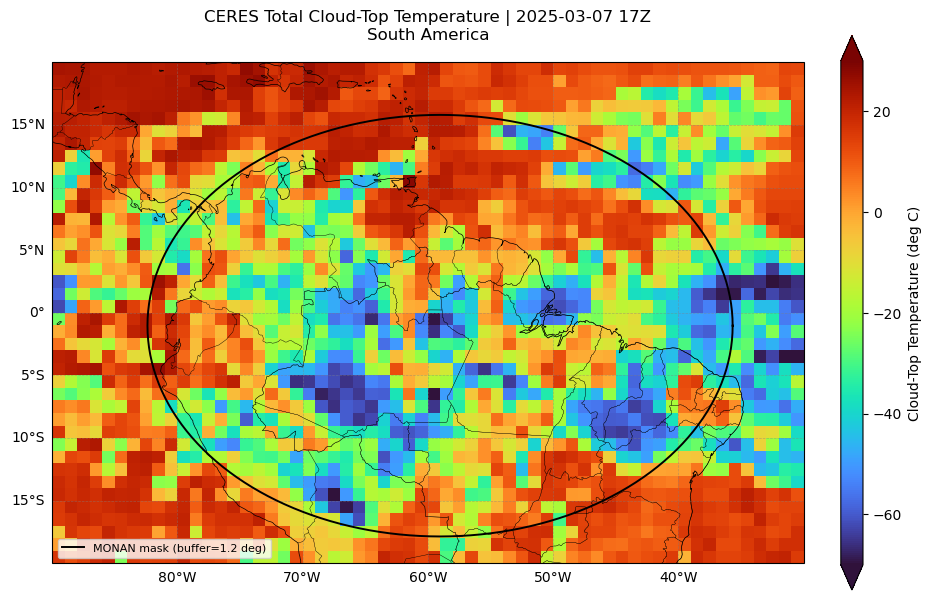

Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//CERES_total_cloud_top_temp_2025030717_Amaz_reg_CTRL.png


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# ======================= CERES total CTT (Celsius) =======================
ceres_var = "obs_cld_top_temp"
if "ceres_selected" not in globals() or "_open_ceres_da" not in globals():
    raise RuntimeError("CERES prep objects not available. Run the CERES prep cell first.")
if not isinstance(ceres_selected, (list, tuple)) or len(ceres_selected) == 0:
    raise RuntimeError("CERES file list is empty. Run the CERES prep cell first.")
if "_select_ceres_time" not in globals():
    raise RuntimeError("Time-selection helper is missing. Run the CERES prep cell first.")

analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H") + pd.Timedelta(hours=1)
analysis_hour = int(analysis_dt.hour)
analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = analysis_dt.strftime("%Y%m%d%H")

ceres_means = []
for ceres_path in ceres_selected:
    da = _open_ceres_da(ceres_path, ceres_var)
    da, selected_time = _select_ceres_time(
        da,
        analysis_dt=analysis_dt,
        analysis_hour=analysis_hour,
        source_name=f"{ceres_var} in {ceres_path.name}",
    )
    if selected_time is not None:
        print(f"{ceres_var}: using {selected_time:%Y-%m-%d %H:%M} from {ceres_path.name}")

    mean_dims = [d for d in da.dims if d not in ["latitude", "longitude", "cloud_layer"]]
    if mean_dims:
        da = da.mean(dim=mean_dims, skipna=True)

    ceres_means.append(da)

ceres_ctt = xr.concat(ceres_means, dim="file").mean(dim="file", skipna=True)

# Select total cloud layer when available.
if "cloud_layer" in ceres_ctt.dims:
    if "cloud_layer_labels" in globals():
        total_layers = [k for k, v in cloud_layer_labels.items() if str(v).strip().lower() == "total"]
    else:
        total_layers = []

    if total_layers:
        total_layer = int(total_layers[0])
    else:
        total_layer = int(np.max(ceres_ctt["cloud_layer"].values))

    ceres_total = ceres_ctt.sel(cloud_layer=total_layer)
else:
    ceres_total = ceres_ctt

# CERES CTT is expected in Kelvin; convert when needed.
ceres_total_vals = np.asarray(ceres_total.values, dtype=float)
if np.nanmax(ceres_total_vals) > 150.0:
    ceres_total_c = ceres_total - 273.15
else:
    ceres_total_c = ceres_total

lon_name = "longitude" if "longitude" in ceres_total.coords else "lon"
lat_name = "latitude" if "latitude" in ceres_total.coords else "lat"
if lon_name not in ceres_total.coords or lat_name not in ceres_total.coords:
    raise KeyError("CERES longitude/latitude coordinates were not found.")

# ======================= MONAN masked-domain outline =======================
if "datetime_analysis" not in globals() or "exps_data" not in globals():
    raise RuntimeError("datetime_analysis/exps_data not found. Run MONAN setup cells first.")

exp = next(iter(exps_data.keys()))
exp_name = exp
ellipse_lons, ellipse_lats = get_monan_mask_outline()

# ======================= Extent: Amaz_reg only =======================
extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
if extent_key is None:
    extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
if extent_key is None:
    raise KeyError("Amaz_reg extent was not found in extents dictionary.")

extent_label = extents[extent_key]["label"]
extent_vals = extents[extent_key]["extent"]

# ======================= Figure: CERES only =======================
plot_vals = np.asarray(ceres_total_c.values, dtype=float)
if np.count_nonzero(np.isfinite(plot_vals)) == 0:
    raise RuntimeError("CERES total cloud-top temperature has no finite values.")

# Match MONAN cloud-top plots: fixed range and colormap.
vmin, vmax = -70.0, 30.0

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

mesh = ax.pcolormesh(
    ceres_total[lon_name].values,
    ceres_total[lat_name].values,
    ceres_total_c.values,
    transform=ccrs.PlateCarree(),
    cmap="turbo",
    vmin=vmin,
    vmax=vmax,
    shading="auto",
)

# MONAN masked-domain outline
ax.plot(
    ellipse_lons,
    ellipse_lats,
    color="black",
    linewidth=1.4,
    linestyle="-",
    transform=ccrs.PlateCarree(),
    zorder=5,
    label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
)

ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES, linewidth=0.2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="both")
cb.set_label("Cloud-Top Temperature (deg C)")

ax.set_title(
    f"CERES Total Cloud-Top Temperature | {analysis_time_str}\n{extent_label}",
    fontsize=12,
    pad=16,
)
ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

plt.tight_layout()
out_png = f"{fig_path}/CERES_total_cloud_top_temp_{analysis_tag}_{extent_key}_{exp_name}.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

In [ ]:
# ERA5 ISR/ISRC and OLR/OLRC maps with MONAN masked-domain outline
# Use datetime_analysis for MONAN and +1h only for CERES/ERA5 matching.
monan_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_dt = monan_dt + pd.Timedelta(hours=1)
analysis_hour = int(analysis_dt.hour)
analysis_time_str = f"MONAN {monan_dt:%Y-%m-%d %HZ} | CERES/ERA5 {analysis_dt:%Y-%m-%d %HZ}"
analysis_tag = analysis_dt.strftime("%Y%m%d%H")
monan_tag = monan_dt.strftime("%Y%m%d%H")
monan_tag = monan_dt.strftime("%Y%m%d%H")
print(f"Stage 1 timing -> MONAN: {monan_dt:%Y-%m-%d %H:%M}Z | CERES/ERA5: {analysis_dt:%Y-%m-%d %H:%M}Z")

if "var_dict" not in globals():
    raise RuntimeError("var_dict is not available. Run setup cells first.")
if "get_monan_mask_outline" not in globals():
    raise RuntimeError("MONAN outline helper is missing. Run the setup cell first.")
if "apply_lon_lat_conventions" not in globals():
    raise RuntimeError("ERA5 lon/lat helper is missing. Run the ERA5 setup cell first.")

ellipse_lons, ellipse_lats = get_monan_mask_outline()

# Use Amaz_reg extent (fallback to any key containing 'amaz')
extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
if extent_key is None:
    extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
if extent_key is None:
    raise KeyError("Amaz_reg extent was not found in extents dictionary.")

extent_label = extents[extent_key]["label"]
extent_vals = extents[extent_key]["extent"]

era5_rad_jobs = [
    {
        "key": "ISR",
        "file": "surface_solar_radiation_downwards.nc",
        "candidates": [var_dict["ISR"].get("era5_name", "ssrd"), var_dict["ISR"].get("era5_longname", ""), "surface_solar_radiation_downwards"],
        "label": var_dict["ISR"]["label"],
        "unit": var_dict["ISR"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["ISR"].get("vmin", 0.0)),
        "vmax": float(var_dict["ISR"].get("vmax", 1300.0)),
        "convert_to_flux": True,
    },
    {
        "key": "ISRC",
        "file": "surface_solar_radiation_downward_clear_sky.nc",
        "candidates": [var_dict["ISRC"].get("era5_name", "ssrdc"), var_dict["ISRC"].get("era5_longname", ""), "surface_solar_radiation_downward_clear_sky"],
        "label": var_dict["ISRC"]["label"],
        "unit": var_dict["ISRC"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["ISRC"].get("vmin", 0.0)),
        "vmax": float(var_dict["ISRC"].get("vmax", 1300.0)),
        "convert_to_flux": True,
    },
    {
        "key": "OLR",
        "file": "top_net_thermal_radiation.nc",
        "candidates": [var_dict["OLR"].get("era5_name", "ttr"), var_dict["OLR"].get("era5_longname", ""), "top_net_thermal_radiation"],
        "label": var_dict["OLR"]["label"],
        "unit": var_dict["OLR"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["OLR"].get("vmin", -400.0)),
        "vmax": float(var_dict["OLR"].get("vmax", 0.0)),
        "convert_to_flux": True,
    },
    {
        "key": "OLRC",
        "file": "top_net_thermal_radiation_clear_sky.nc",
        "candidates": [var_dict["OLRC"].get("era5_name", "ttrc"), var_dict["OLRC"].get("era5_longname", ""), "top_net_thermal_radiation_clear_sky"],
        "label": var_dict["OLRC"]["label"],
        "unit": var_dict["OLRC"].get("unit", "W m^{-2}"),
        "vmin": float(var_dict["OLRC"].get("vmin", -400.0)),
        "vmax": float(var_dict["OLRC"].get("vmax", 0.0)),
        "convert_to_flux": True,
    },
]


def _pick_era5_var(ds, candidates):
    cleaned = [c for c in candidates if c]
    for candidate in cleaned:
        if candidate in ds.data_vars:
            return candidate
    for candidate in cleaned:
        candidate_l = candidate.lower()
        for var_name in ds.data_vars:
            if candidate_l in var_name.lower():
                return var_name
    return list(ds.data_vars)[0]



def _pick_era5_time(da, target_dt):
    time_name = None
    for candidate in ["valid_time", "time"]:
        if candidate in da.coords or candidate in da.dims:
            time_name = candidate
            break
    if time_name is None:
        return da, None

    time_values = pd.to_datetime(da[time_name].values, errors="coerce")
    if np.asarray(time_values).ndim == 0:
        return da, pd.to_datetime(time_values)

    valid_idx = np.where(~pd.isna(time_values))[0]
    if valid_idx.size != len(time_values):
        da = da.isel({time_name: valid_idx})
        time_values = pd.to_datetime(da[time_name].values, errors="coerce")

    if len(time_values) == 0:
        return da, None

    exact_idx = np.where(time_values == target_dt)[0]
    if exact_idx.size > 0:
        selected_time = pd.to_datetime(time_values[int(exact_idx[0])])
        return da.sel({time_name: selected_time}), selected_time

    nearest_idx = int(np.argmin(np.abs(time_values - target_dt)))
    selected_time = pd.to_datetime(time_values[nearest_idx])
    return da.isel({time_name: nearest_idx}), selected_time


for job in era5_rad_jobs:
    era5_path = Path(base_dir) / "era5" / "single_levels" / year / month / job["file"]
    if not era5_path.exists():
        print(f"  ERA5 file not found for {job['key']}: {era5_path}")
        continue

    ds_era5 = xr.open_dataset(era5_path, engine="netcdf4")
    ds_era5 = apply_lon_lat_conventions(ds_era5)

    var_name = _pick_era5_var(ds_era5, job["candidates"])
    da = ds_era5[var_name]
    da, selected_time = _pick_era5_time(da, analysis_dt)
    if selected_time is not None:
        print(f"ERA5 {job['key']}: using {selected_time:%Y-%m-%d %H:%M} from {era5_path.name}")

    time_dim_name = None
    for candidate in ["valid_time", "time"]:
        if candidate in da.dims:
            time_dim_name = candidate
            break
    mean_dims = [dim for dim in da.dims if dim not in ["latitude", "longitude", "lat", "lon", time_dim_name]]
    if mean_dims:
        da = da.mean(dim=mean_dims, skipna=True)

    values = np.asarray(da.values, dtype=float)
    units = str(da.attrs.get("units", "")).strip().lower()
    if job["convert_to_flux"] and ("j" in units or "joule" in units or "mj" in units or np.nanmax(np.abs(values)) > 5000.0):
        values = values / 3600.0

    if job["key"] in ("OLR", "OLRC") and np.nanmean(values) > 0:
        values = -values

    lon_name = "longitude" if "longitude" in da.coords else "lon"
    lat_name = "latitude" if "latitude" in da.coords else "lat"
    if lon_name not in da.coords or lat_name not in da.coords:
        raise KeyError(f"Could not find lon/lat coordinates for ERA5 {job['key']}")

    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

        mesh = ax.pcolormesh(
            da[lon_name].values,
            da[lat_name].values,
            values,
            transform=ccrs.PlateCarree(),
            cmap="turbo",
            vmin=job["vmin"],
            vmax=job["vmax"],
            shading="auto",
        )

        ax.plot(
            ellipse_lons,
            ellipse_lats,
            color="black",
            linewidth=1.4,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=5,
            label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
        )

        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

        cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="both")
        cb.set_label(f"ERA5 {job['label']} ({job['unit']})")

        ax.set_title(
            f"ERA5 {job['key']} | {analysis_time_str}\n{extent_label}",
            fontsize=12,
            pad=16,
        )
        ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

        plt.tight_layout()
        out_png = f"{fig_path}/ERA5_{job['key']}_analysis_{analysis_tag}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        print(f"Saved: {out_png}")
        plt.close(fig)

    ds_era5.close()

ERA5 ISR: using 2025-03-07 17:00 from surface_solar_radiation_downwards.nc
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_ISR_analysis_2025030717_Amaz_reg.png
ERA5 ISRC: using 2025-03-07 17:00 from surface_solar_radiation_downward_clear_sky.nc
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_ISRC_analysis_2025030717_Amaz_reg.png
ERA5 OLR: using 2025-03-07 17:00 from top_net_thermal_radiation.nc
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_OLR_analysis_2025030717_Amaz_reg.png
ERA5 OLRC: using 2025-03-07 17:00 from top_net_thermal_radiation_clear_sky.nc
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_OLRC_analysis_2025030717_Amaz_reg.png


### Pdf and KDE

## Staged workflow: remap -> map check -> PDF/KDE

In [23]:
# Helper fallback for ERA5 longitude/latitude conventions
if "apply_lon_lat_conventions" not in globals():
    def apply_lon_lat_conventions(ds):
        if "longitude" in ds.coords:
            lons = ds["longitude"]
            lons_new = ((lons + 180.0) % 360.0) - 180.0
            ds = ds.assign_coords(longitude=lons_new)
            ds = ds.sortby("longitude")
        elif "lon" in ds.coords:
            lons = ds["lon"]
            lons_new = ((lons + 180.0) % 360.0) - 180.0
            ds = ds.assign_coords(lon=lons_new)
            ds = ds.sortby("lon")

        if "latitude" in ds.coords:
            if ds["latitude"].values[0] > ds["latitude"].values[-1]:
                ds = ds.sortby("latitude")
        elif "lat" in ds.coords:
            if ds["lat"].values[0] > ds["lat"].values[-1]:
                ds = ds.sortby("lat")
        return ds

print("apply_lon_lat_conventions helper is ready.")

apply_lon_lat_conventions helper is ready.


In [24]:
# Stage 1: remap ERA5 and MONAN to CERES grid, apply MONAN mask area
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.interpolate import griddata
from matplotlib.path import Path as MplPath

# Use datetime_analysis for MONAN and +1h only for CERES/ERA5 matching.
monan_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
analysis_dt = monan_dt + pd.Timedelta(hours=1)
analysis_hour = int(analysis_dt.hour)
analysis_time_str = f"MONAN {monan_dt:%Y-%m-%d %HZ} | CERES/ERA5 {analysis_dt:%Y-%m-%d %HZ}"
analysis_tag = analysis_dt.strftime("%Y%m%d%H")
monan_tag = monan_dt.strftime("%Y%m%d%H")

required_names = ["var_dict", "ceres_selected", "_open_ceres_da", "_select_ceres_time", "apply_lon_lat_conventions", "get_monan_mask_outline"]
missing = [n for n in required_names if n not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites for staged workflow: {missing}")


# Helper utilities

def _pick_time(da, target_dt):
    time_name = None
    for candidate in ["valid_time", "time"]:
        if candidate in da.coords or candidate in da.dims:
            time_name = candidate
            break
    if time_name is None:
        return da, None

    tv = pd.to_datetime(da[time_name].values, errors="coerce")
    if np.asarray(tv).ndim == 0:
        return da, pd.to_datetime(tv)
    if len(tv) == 0:
        return da, None

    valid_idx = np.where(~pd.isna(tv))[0]
    if valid_idx.size != len(tv):
        da = da.isel({time_name: valid_idx})
        tv = pd.to_datetime(da[time_name].values, errors="coerce")
        if len(tv) == 0:
            return da, None

    exact = np.where(tv == target_dt)[0]
    if exact.size > 0:
        sel_t = pd.to_datetime(tv[int(exact[0])])
        return da.sel({time_name: sel_t}), sel_t

    # Do not use nearest fallback: require same requested hour (prevents unintended previous-hour picks).
    same_hour_idx = np.where(tv.hour == target_dt.hour)[0]
    if same_hour_idx.size > 0:
        same_day_idx = np.array([i for i in same_hour_idx if pd.to_datetime(tv[i]).date() == target_dt.date()], dtype=int)
        candidate_idx = same_day_idx if same_day_idx.size > 0 else same_hour_idx
        deltas = np.abs(tv[candidate_idx] - target_dt)
        idx = int(candidate_idx[int(np.argmin(deltas))])
        sel_t = pd.to_datetime(tv[idx])
        return da.isel({time_name: idx}), sel_t

    raise ValueError(
        f"ERA5: no exact/same-hour match for {target_dt:%Y-%m-%d %H:%M}. "
        f"Available times: {[t.strftime('%Y-%m-%d %H:%M') for t in tv]}"
    )



def _remap_points_to_ceres(src_lon2d, src_lat2d, src_values2d, tgt_lon2d, tgt_lat2d):
    points = np.column_stack([src_lon2d.ravel(), src_lat2d.ravel()])
    vals = src_values2d.ravel()
    valid = np.isfinite(points[:, 0]) & np.isfinite(points[:, 1]) & np.isfinite(vals)
    points = points[valid]
    vals = vals[valid]
    if points.size == 0:
        return np.full_like(tgt_lon2d, np.nan, dtype=float)

    dst_linear = griddata(points, vals, (tgt_lon2d, tgt_lat2d), method="linear")
    dst_nearest = griddata(points, vals, (tgt_lon2d, tgt_lat2d), method="nearest")
    return np.where(np.isnan(dst_linear), dst_nearest, dst_linear)


# CERES target grid
ceres_ref = _open_ceres_da(ceres_selected[0], var_dict["ISR"]["ceres_name"])
ceres_ref, _ = _select_ceres_time(ceres_ref, analysis_dt=analysis_dt, analysis_hour=analysis_hour, source_name="CERES grid")
if "level" in ceres_ref.dims:
    ceres_ref = ceres_ref.sel(level=ceres_ref["level"].values[-1])
mean_dims = [d for d in ceres_ref.dims if d not in ["longitude", "latitude", "lon", "lat"]]
if mean_dims:
    ceres_ref = ceres_ref.mean(dim=mean_dims, skipna=True)
lon_name = "longitude" if "longitude" in ceres_ref.coords else "lon"
lat_name = "latitude" if "latitude" in ceres_ref.coords else "lat"
ceres_lons = np.asarray(ceres_ref[lon_name].values, dtype=float)
ceres_lats = np.asarray(ceres_ref[lat_name].values, dtype=float)
ceres_lon2d, ceres_lat2d = np.meshgrid(ceres_lons, ceres_lats)

# MONAN masked area on CERES grid
ellipse_lons, ellipse_lats = get_monan_mask_outline()
mask_path = MplPath(np.column_stack([ellipse_lons, ellipse_lats]), closed=True)
mask_inside = mask_path.contains_points(np.column_stack([ceres_lon2d.ravel(), ceres_lat2d.ravel()])).reshape(ceres_lon2d.shape)

rad_jobs_stage = {
    "ISR": {
        "ceres_name": var_dict["ISR"]["ceres_name"],
        "era5_name": var_dict["ISR"].get("era5_name", "ssrd"),
        "era5_longname": var_dict["ISR"].get("era5_longname", "surface_solar_radiation_downwards"),
        "era5_file": "surface_solar_radiation_downwards.nc",
        "monan_name": var_dict["ISR"]["monan_name"],
        "vmin": float(var_dict["ISR"].get("vmin", 0.0)),
        "vmax": float(var_dict["ISR"].get("vmax", 1300.0)),
        "negate_if_positive": False,
    },
    "ISRC": {
        "ceres_name": var_dict["ISRC"]["ceres_name"],
        "era5_name": var_dict["ISRC"].get("era5_name", "ssrdc"),
        "era5_longname": var_dict["ISRC"].get("era5_longname", "surface_solar_radiation_downward_clear_sky"),
        "era5_file": "surface_solar_radiation_downward_clear_sky.nc",
        "monan_name": var_dict["ISRC"]["monan_name"],
        "vmin": float(var_dict["ISRC"].get("vmin", 0.0)),
        "vmax": float(var_dict["ISRC"].get("vmax", 1300.0)),
        "negate_if_positive": False,
    },
    "OLR": {
        "ceres_name": var_dict["OLR"]["ceres_name"],
        "era5_name": var_dict["OLR"].get("era5_name", "ttr"),
        "era5_longname": var_dict["OLR"].get("era5_longname", "top_net_thermal_radiation"),
        "era5_file": "top_net_thermal_radiation.nc",
        "monan_name": var_dict["OLR"]["monan_name"],
        "vmin": float(var_dict["OLR"].get("vmin", -400.0)),
        "vmax": float(var_dict["OLR"].get("vmax", 0.0)),
        "negate_if_positive": True,
    },
    "OLRC": {
        "ceres_name": var_dict["OLRC"]["ceres_name"],
        "era5_name": var_dict["OLRC"].get("era5_name", "ttrc"),
        "era5_longname": var_dict["OLRC"].get("era5_longname", "top_net_thermal_radiation_clear_sky"),
        "era5_file": "top_net_thermal_radiation_clear_sky.nc",
        "monan_name": var_dict["OLRC"]["monan_name"],
        "vmin": float(var_dict["OLRC"].get("vmin", -400.0)),
        "vmax": float(var_dict["OLRC"].get("vmax", 0.0)),
        "negate_if_positive": True,
    },
}

# monan_experiments = list(exps_data.keys())[:3]
monan_experiments = list(exps_data.keys())
remapped_fields = {k: {} for k in rad_jobs_stage.keys()}

for vkey, cfg in rad_jobs_stage.items():
    # CERES on native CERES grid + masked area
    ceres_samples = []
    for ceres_path in ceres_selected:
        da = _open_ceres_da(ceres_path, cfg["ceres_name"])
        da, sel_ceres = _select_ceres_time(da, analysis_dt=analysis_dt, analysis_hour=analysis_hour, source_name=f"CERES {vkey} {ceres_path.name}")
        if sel_ceres is not None:
            print(f"CERES {vkey}: selected {sel_ceres:%Y-%m-%d %H:%M} from {ceres_path.name}")
        if "level" in da.dims:
            level_values = np.asarray(da["level"].values)
            if vkey in ("ISR", "ISRC"):
                if np.any(level_values == 5):
                    selected_level = 5
                else:
                    selected_level = level_values[-1]
            elif vkey in ("OLR", "OLRC"):
                if np.any(level_values == 1):
                    selected_level = 1
                else:
                    selected_level = level_values[0]
            else:
                selected_level = level_values[-1]
            da = da.sel(level=selected_level)
            print(f"CERES {vkey}: using level={selected_level}")
        mean_dims = [d for d in da.dims if d not in ["longitude", "latitude", "lon", "lat"]]
        if mean_dims:
            da = da.mean(dim=mean_dims, skipna=True)
        arr = np.asarray(da.values, dtype=float)
        ceres_samples.append(arr)
    ceres_stack = np.stack(ceres_samples, axis=0)
    valid_count = np.sum(np.isfinite(ceres_stack), axis=0)
    ceres_sum = np.nansum(ceres_stack, axis=0)
    ceres_arr = np.full_like(ceres_sum, np.nan, dtype=float)
    np.divide(ceres_sum, valid_count, out=ceres_arr, where=(valid_count > 0))
    if cfg["negate_if_positive"] and np.nanmean(ceres_arr) > 0:
        ceres_arr = -ceres_arr
    remapped_fields[vkey]["CERES"] = np.where(mask_inside, ceres_arr, np.nan)

    # ERA5 remapped to CERES grid + masked area
    era5_path = Path(base_dir) / "era5" / "single_levels" / year / month / cfg["era5_file"]
    if era5_path.exists():
        ds_era5 = xr.open_dataset(era5_path, engine="netcdf4")
        ds_era5 = apply_lon_lat_conventions(ds_era5)

        era5_var_name = None
        for cand in [cfg["era5_name"], cfg["era5_longname"]]:
            if cand in ds_era5.data_vars:
                era5_var_name = cand
                break
        if era5_var_name is None:
            for vn in ds_era5.data_vars:
                if cfg["era5_name"].lower() in vn.lower() or cfg["era5_longname"].lower() in vn.lower():
                    era5_var_name = vn
                    break
        if era5_var_name is None:
            era5_var_name = list(ds_era5.data_vars)[0]

        da_e = ds_era5[era5_var_name]
        da_e, sel_era5 = _pick_time(da_e, analysis_dt)
        if sel_era5 is not None:
            print(f"ERA5 {vkey}: selected {sel_era5:%Y-%m-%d %H:%M} from {era5_path.name}")
        mean_dims = [d for d in da_e.dims if d not in ["longitude", "latitude", "lon", "lat", "time", "valid_time"]]
        if mean_dims:
            da_e = da_e.mean(dim=mean_dims, skipna=True)

        e_lon_name = "longitude" if "longitude" in da_e.coords else "lon"
        e_lat_name = "latitude" if "latitude" in da_e.coords else "lat"
        e_lons = np.asarray(da_e[e_lon_name].values, dtype=float)
        e_lats = np.asarray(da_e[e_lat_name].values, dtype=float)
        e_vals = np.asarray(da_e.values, dtype=float)

        units = str(da_e.attrs.get("units", "")).strip().lower()
        if ("j" in units or "joule" in units or "mj" in units or np.nanmax(np.abs(e_vals)) > 5000.0):
            e_vals = e_vals / 3600.0
        if cfg["negate_if_positive"] and np.nanmean(e_vals) > 0:
            e_vals = -e_vals

        if e_lons.ndim == 1 and e_lats.ndim == 1 and e_vals.ndim == 2:
            e_lon2d, e_lat2d = np.meshgrid(e_lons, e_lats)
        else:
            e_lon2d = np.asarray(e_lons, dtype=float)
            e_lat2d = np.asarray(e_lats, dtype=float)

        e_on_ceres = _remap_points_to_ceres(e_lon2d, e_lat2d, e_vals, ceres_lon2d, ceres_lat2d)
        remapped_fields[vkey]["ERA5"] = np.where(mask_inside, e_on_ceres, np.nan)
        ds_era5.close()
    else:
        remapped_fields[vkey]["ERA5"] = np.full_like(ceres_lon2d, np.nan, dtype=float)

    # MONAN experiments remapped to CERES grid
    for exp_name in monan_experiments:
        monan_dir = exps_data[exp_name]["dir"]
        f_curr = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{monan_dt.strftime('%Y%m%d%H')}.00.00.{resolution}.nc"
        f_prev = Path(monan_dir) / f"{init}/Model/MONAN_DIAG_G_MOD_{name_initcond}_{init}_{(monan_dt - pd.Timedelta(hours=deltat)).strftime('%Y%m%d%H')}.00.00.{resolution}.nc"

        print(f"MONAN {vkey} {exp_name}: current={monan_dt:%Y-%m-%d %H:%M}, previous={(monan_dt - pd.Timedelta(hours=deltat)):%Y-%m-%d %H:%M}")
        if (not f_curr.exists()) or (not f_prev.exists()):
            remapped_fields[vkey][exp_name] = np.full_like(ceres_lon2d, np.nan, dtype=float)
            continue

        ds_c = xr.open_dataset(f_curr, engine="netcdf4")
        ds_p = xr.open_dataset(f_prev, engine="netcdf4")

        vname = cfg["monan_name"]
        acc_name = f"ac{vname}"
        if acc_name in ds_c.data_vars and acc_name in ds_p.data_vars:
            m_vals = (
                np.asarray(ds_c[acc_name].squeeze(drop=True).values, dtype=float)
                - np.asarray(ds_p[acc_name].squeeze(drop=True).values, dtype=float)
            ) / (deltat * 3600.0)
        elif vname in ds_c.data_vars:
            m_vals = np.asarray(ds_c[vname].squeeze(drop=True).values, dtype=float)
        else:
            remapped_fields[vkey][exp_name] = np.full_like(ceres_lon2d, np.nan, dtype=float)
            ds_c.close()
            ds_p.close()
            continue

        m_lons = np.asarray(ds_c["lonCell"].values, dtype=float)
        m_lats = np.asarray(ds_c["latCell"].values, dtype=float)
        lon_min, lon_max = float(np.nanmin(m_lons)), float(np.nanmax(m_lons))
        lat_min, lat_max = float(np.nanmin(m_lats)), float(np.nanmax(m_lats))
        lon_in_rad = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
        lat_in_rad = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
        if lon_in_rad and lat_in_rad:
            m_lons = np.degrees(m_lons)
            m_lats = np.degrees(m_lats)
        m_lons = ((m_lons + 180.0) % 360.0) - 180.0

        if cfg["negate_if_positive"] and np.nanmean(m_vals) > 0:
            m_vals = -m_vals

        m_on_ceres = _remap_points_to_ceres(m_lons, m_lats, m_vals, ceres_lon2d, ceres_lat2d)
        remapped_fields[vkey][exp_name] = np.where(mask_inside, m_on_ceres, np.nan)

        ds_c.close()
        ds_p.close()

# Persist stage-1 objects for next cells
staged_context = {
    "analysis_tag": analysis_tag,
    "monan_tag": monan_tag,
    "analysis_time_str": analysis_time_str,
    "ceres_lons": ceres_lons,
    "ceres_lats": ceres_lats,
    "ceres_lon2d": ceres_lon2d,
    "ceres_lat2d": ceres_lat2d,
    "mask_inside": mask_inside,
    "rad_jobs_stage": rad_jobs_stage,
    "monan_experiments": monan_experiments,
    "remapped_fields": remapped_fields,
}

print("Stage 1 complete.")
print(f"Experiments considered: {monan_experiments}")
for vkey in ["ISR", "ISRC", "OLR", "OLRC"]:
    print(f"\n{vkey} valid-point counts inside mask:")
    for dname, darr in remapped_fields[vkey].items():
        nvalid = int(np.count_nonzero(np.isfinite(darr)))
        print(f"  {dname}: {nvalid}")

CERES ISR: selected 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
CERES ISR: using level=5
ERA5 ISR: selected 2025-03-07 17:00 from surface_solar_radiation_downwards.nc


MONAN ISR CTRL: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISR TIEDTKE: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISR MESO_cld_monan: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISR MESO_cu_GF: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISR MESO_mp_thompson: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISR MESO_bl_mynn: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISR MESO_mynn_edmf_1: current=2025-03-07 16:00, previous=2025-03-07 15:00
CERES ISRC: selected 2025-03-07 17:00 from CER_SYN1deg-1Hour_Terra-Aqua-NOAA20_Edition4B_415412.20250307.hdf
CERES ISRC: using level=5
ERA5 ISRC: selected 2025-03-07 17:00 from surface_solar_radiation_downward_clear_sky.nc
MONAN ISRC CTRL: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISRC TIEDTKE: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISRC MESO_cld_monan: current=2025-03-07 16:00, previous=2025-03-07 15:00
MONAN ISRC MESO_cu_GF: current

In [25]:
# Stage 2: map check for ISR/ISRC and OLR/OLRC at datetime_analysis
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

if "staged_context" not in globals():
    raise RuntimeError("Stage 1 was not run. Execute the Stage 1 cell first.")

ctx = staged_context
expected_monan_tag = pd.to_datetime(datetime_analysis, format="%Y%m%d%H").strftime("%Y%m%d%H")
expected_ceres_era5_tag = (pd.to_datetime(datetime_analysis, format="%Y%m%d%H") + pd.Timedelta(hours=1)).strftime("%Y%m%d%H")
if ctx.get("monan_tag") != expected_monan_tag or ctx.get("analysis_tag") != expected_ceres_era5_tag:
    raise RuntimeError(
        f"Stage 1 context is stale. Expected MONAN={expected_monan_tag}, CERES/ERA5={expected_ceres_era5_tag}; got MONAN={ctx.get('monan_tag')}, CERES/ERA5={ctx.get('analysis_tag')}. Re-run Cell 59 (Stage 1)."
    )
remapped_fields = ctx["remapped_fields"]
rad_jobs_stage = ctx["rad_jobs_stage"]
analysis_time_str = ctx["analysis_time_str"]
analysis_tag = ctx["analysis_tag"]
ceres_lons = ctx["ceres_lons"]
ceres_lats = ctx["ceres_lats"]
monan_experiments = ctx["monan_experiments"]

plot_order = monan_experiments + ["CERES", "ERA5"]

for vkey in ["ISR", "ISRC", "OLR", "OLRC"]:
    cfg = rad_jobs_stage[vkey]
    ncols = len(plot_order)
    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=(4.8 * ncols, 4.9),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
    )

    for i, dname in enumerate(plot_order):
        ax = axes[0, i]
        data = remapped_fields[vkey].get(dname, None)
        if data is None:
            data = np.full((len(ceres_lats), len(ceres_lons)), np.nan, dtype=float)

        mesh = ax.pcolormesh(
            ceres_lons,
            ceres_lats,
            data,
            transform=ccrs.PlateCarree(),
            cmap="turbo",
            vmin=cfg["vmin"],
            vmax=cfg["vmax"],
            shading="auto",
        )

        ax.plot(
            ellipse_lons,
            ellipse_lats,
            color="black",
            linewidth=1.2,
            transform=ccrs.PlateCarree(),
            zorder=5,
        )
        ax.coastlines(linewidth=0.4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)
        ax.add_feature(cfeature.STATES, linewidth=0.15)

        if "Amaz_reg" in extents:
            ax.set_extent(extents["Amaz_reg"]["extent"], crs=ccrs.PlateCarree())

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = (i == 0)
        gl.bottom_labels = True
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}

        nvalid = int(np.count_nonzero(np.isfinite(data)))
        ax.set_title(f"{dname}\nvalid={nvalid}", fontsize=10)

    cb = fig.colorbar(mesh, ax=axes.ravel().tolist(), shrink=0.85, aspect=35, pad=0.02, extend="both")
    cb.set_label(f"{vkey} ({var_dict[vkey].get('unit', 'W m^{{-2}}')})")

    fig.suptitle(f"Stage 2 check: {vkey} on CERES grid (masked area) | {analysis_time_str}", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    out_png = f"{fig_path}/STAGE2_{vkey}_map_check_on_ceres_grid_{analysis_tag}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)

print("Stage 2 complete.")

/tmp/ipykernel_3578253/2902582245.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//STAGE2_ISR_map_check_on_ceres_grid_2025030717.png


/tmp/ipykernel_3578253/2902582245.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//STAGE2_ISRC_map_check_on_ceres_grid_2025030717.png


/tmp/ipykernel_3578253/2902582245.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//STAGE2_OLR_map_check_on_ceres_grid_2025030717.png


/tmp/ipykernel_3578253/2902582245.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//STAGE2_OLRC_map_check_on_ceres_grid_2025030717.png
Stage 2 complete.


In [36]:
# Ensure figure output directory exists for staged plots
from pathlib import Path
if "fig_path" not in globals() or not str(fig_path).strip():
    fig_path = str(Path.cwd() / "figuras")
Path(fig_path).mkdir(parents=True, exist_ok=True)
print(f"Using figure output directory: {fig_path}")

Using figure output directory: /p/projetos/monan_atm/madeleine.gacita/figuras/


In [26]:
# Stage 3: PDF and KDE using staged remapped fields
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

if "staged_context" not in globals():
    raise RuntimeError("Stage 1 was not run. Execute the Stage 1 cell first.")

ctx = staged_context
expected_monan_tag = pd.to_datetime(datetime_analysis, format="%Y%m%d%H").strftime("%Y%m%d%H")
expected_ceres_era5_tag = (pd.to_datetime(datetime_analysis, format="%Y%m%d%H") + pd.Timedelta(hours=1)).strftime("%Y%m%d%H")
if ctx.get("monan_tag") != expected_monan_tag or ctx.get("analysis_tag") != expected_ceres_era5_tag:
    raise RuntimeError(
        f"Stage 1 context is stale. Expected MONAN={expected_monan_tag}, CERES/ERA5={expected_ceres_era5_tag}; got MONAN={ctx.get('monan_tag')}, CERES/ERA5={ctx.get('analysis_tag')}. Re-run Cell 59 (Stage 1)."
    )
remapped_fields = ctx["remapped_fields"]
rad_jobs_stage = ctx["rad_jobs_stage"]
analysis_time_str = ctx["analysis_time_str"]
analysis_tag = ctx["analysis_tag"]
monan_experiments = ctx["monan_experiments"]

plot_order = monan_experiments + ["CERES", "ERA5"]
plot_styles = {
    "CERES": {"color": "black", "linestyle": "-", "linewidth": 1.5},
    "ERA5": {"color": "#d62728", "linestyle": "-", "linewidth": 1.5},
}

special_styles = {
    "CTRL": {"color": "#e66101", "linestyle": ":", "linewidth": 2.4},
    "MESO_cu_GF": {"color": "#8c564b", "linestyle": "--", "linewidth": 2.4},
    "TIEDTKE": {"color": "#1f3a93", "linestyle": ":", "linewidth": 2.6},
    "MESO_mp_thompson": {"color": "#5a189a", "linestyle": ":", "linewidth": 2.6},
}

monan_color_cycle = [
    "#0b6e4f",
    "#006d77",
    "#1b4332",
    "#283618",
    "#004e89",
    "#3a0ca3",
    "#2d6a4f",
    "#1d3557",
    "#4f772d",
    "#264653",
    "#2a9d8f",
    "#355070",
]
cycle_index = 0
for exp_name in monan_experiments:
    if exp_name in special_styles:
        plot_styles[exp_name] = special_styles[exp_name]
        continue
    color = monan_color_cycle[cycle_index % len(monan_color_cycle)]
    cycle_index += 1
    plot_styles[exp_name] = {"color": color, "linestyle": "--", "linewidth": 2.0}

for vkey in ["ISR", "OLR"]:
    cfg = rad_jobs_stage[vkey]
    x_support = np.linspace(cfg["vmin"], cfg["vmax"], 450)

    fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2), sharey=False)
    ax_pdf, ax_kde = axes

    plotted_any = False
    for dname in plot_order:
        arr = np.asarray(remapped_fields[vkey].get(dname, np.nan), dtype=float)
        finite = arr[np.isfinite(arr)]
        finite = finite[(finite >= cfg["vmin"]) & (finite <= cfg["vmax"])]

        if finite.size < 5:
            print(f"{vkey} | {dname}: insufficient points ({finite.size}), skipping")
            continue

        hist_y, hist_bins = np.histogram(
            finite,
            bins=120 if vkey == "ISR" else 100,
            range=(cfg["vmin"], cfg["vmax"]),
            density=True,
        )
        hist_x = 0.5 * (hist_bins[:-1] + hist_bins[1:])

        try:
            kde_obj = scipy_stats.gaussian_kde(finite)
            kde_y = kde_obj(x_support)
        except Exception as exc:
            print(f"{vkey} | {dname}: KDE failed ({exc})")
            kde_y = np.full_like(x_support, np.nan)

        style = plot_styles.get(dname, {"color": "gray", "linestyle": "-", "linewidth": 1.5})
        # Plot only the top profile of histogram bins for a cleaner PDF view.
        ax_pdf.step(
            hist_x,
            hist_y,
            where="mid",
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            label=dname,
        )
        ax_kde.plot(x_support, kde_y, color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], label=dname)
        plotted_any = True

    if not plotted_any:
        plt.close(fig)
        print(f"No valid distributions found for {vkey}")
        continue

    ax_pdf.set_title(f"{vkey} PDF top profile (inside MONAN mask)")
    ax_pdf.set_xlabel(f"{vkey} ({var_dict[vkey].get('unit', 'W m^{{-2}}')})")
    ax_pdf.set_ylabel("Density")
    ax_pdf.set_xlim(cfg["vmin"], cfg["vmax"])
    ax_pdf.grid(True, alpha=0.25)
    ax_pdf.legend(fontsize=8, framealpha=0.9)

    ax_kde.set_title(f"{vkey} KDE (inside MONAN mask)")
    ax_kde.set_xlabel(f"{vkey} ({var_dict[vkey].get('unit', 'W m^{{-2}}')})")
    ax_kde.set_ylabel("Density")
    ax_kde.set_xlim(cfg["vmin"], cfg["vmax"])
    ax_kde.grid(True, alpha=0.25)
    ax_kde.legend(fontsize=8, framealpha=0.9)

    fig.suptitle(f"Stage 3 distributions on CERES grid | {analysis_time_str}", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    out_png = f"{fig_path}/{vkey}_pdf_kde_on_ceres_grid_{analysis_tag}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)

print("Stage 3 complete.")

Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//ISR_pdf_kde_on_ceres_grid_2025030717.png
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//OLR_pdf_kde_on_ceres_grid_2025030717.png
Stage 3 complete.


## Plot precipitation

In [ ]:
MSWEP_base = '/pesq/dados/monan/users/andre.lyra/MSWEP'
MSWEP_version = 'MSWEP_V315_Saulo'
MSWEP_dir = f'{MSWEP_base}/{MSWEP_version}/202503/'

In [ ]:
# Plot MSWEP precipitation with the same colorscale and norm as MONAN rain
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm

if "analysis_dt" not in globals():
    analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")
if "analysis_time_str" not in globals():
    analysis_time_str = analysis_dt.strftime("%Y-%m-%d %HZ")
if "analysis_tag" not in globals():
    analysis_tag = analysis_dt.strftime("%Y%m%d%H")

# Reuse MONAN precipitation colors if already available; otherwise define the same scale.
if "cmap_rain" not in globals() or "norm" not in globals():
    cores_legenda_rgb = [
        (255, 255, 255),
        (220, 220, 220),
        (180, 180, 180),
        (20, 0, 150),
        (0, 0, 255),
        (0, 100, 100),
        (0, 200, 0),
        (150, 255, 0),
        (255, 255, 0),
        (255, 220, 0),
        (255, 130, 0),
        (230, 25, 25),
        (100, 0, 0),
    ]
    cores_normalizadas_matplotlib = [(r / 255.0, g / 255.0, b / 255.0) for r, g, b in cores_legenda_rgb]
    cmap_rain = ListedColormap(cores_normalizadas_matplotlib)
    clevs = [0, 1, 2, 4, 6, 10, 15, 25, 35, 50, 75, 100, 150]
    norm = BoundaryNorm(clevs, ncolors=len(clevs), extend="max")

if "MSWEP_base" not in globals() or "MSWEP_dir" not in globals():
    raise RuntimeError("MSWEP paths are missing. Run the MSWEP setup cell first.")

julday = analysis_dt.strftime("%j")
file_name = f"{analysis_dt:%Y}{julday}.{analysis_dt:%H}.nc"

if "ds_netcdf" in globals() and ds_netcdf is not None:
    ds_mswep = ds_netcdf
    netcdf_path = None
    print(f"Using already-open MSWEP dataset for {file_name}")
else:
    candidate_paths = [
        Path(MSWEP_dir) / file_name,
        Path(MSWEP_base) / f"{MSWEP_version}_{year}{month}" / file_name,
    ]
    netcdf_path = next((path for path in candidate_paths if path.exists()), None)
    if netcdf_path is None:
        print(f"NetCDF not found for {file_name} in any of the candidate paths {MSWEP_dir}")
    else:
        print(f"Opening: {netcdf_path}")
        ds_mswep = xr.open_dataset(netcdf_path, engine="netcdf4")

if "ds_mswep" in globals():
    if "precipitation" not in ds_mswep.data_vars:
        raise KeyError(f"Variable 'precipitation' not found in the MSWEP dataset")

    da = ds_mswep["precipitation"]
    if "time" in da.coords and da.sizes.get("time", 0) > 1:
        time_values = pd.to_datetime(da["time"].values)
        if analysis_dt in set(time_values):
            selected_time = analysis_dt
        else:
            nearest_idx = int(np.argmin(np.abs(time_values - analysis_dt)))
            selected_time = pd.to_datetime(time_values[nearest_idx])
        da = da.sel(time=selected_time).squeeze(drop=True)
        print(f"Selected MSWEP time: {selected_time:%Y-%m-%d %H:%M}")
    else:
        da = da.squeeze(drop=True)

    lon_name = "lon" if "lon" in da.coords else ("longitude" if "longitude" in da.coords else list(da.dims)[-1])
    lat_name = "lat" if "lat" in da.coords else ("latitude" if "latitude" in da.coords else list(da.dims)[-2])

    mswep_lons = np.asarray(da[lon_name].values, dtype=float)
    mswep_lats = np.asarray(da[lat_name].values, dtype=float)
    mswep_vals = np.asarray(da.values, dtype=float)

    extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
    if extent_key is None:
        extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
    if extent_key is None:
        raise KeyError("Amaz_reg extent was not found in extents dictionary.")
    extent_label = extents[extent_key]["label"]
    extent_vals = extents[extent_key]["extent"]

    ellipse_lons, ellipse_lats = get_monan_mask_outline()

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    mesh = ax.pcolormesh(
        mswep_lons,
        mswep_lats,
        mswep_vals,
        cmap=cmap_rain,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    ax.plot(
        ellipse_lons,
        ellipse_lats,
        color="black",
        linewidth=1.4,
        linestyle="-",
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
    )

    ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="max")
    cb.set_label("MSWEP precipitation")

    ax.set_title(f"MSWEP precipitation | {analysis_time_str}\n{extent_label}", fontsize=12, pad=16)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

    plt.tight_layout()
    out_png = f"{fig_path}/MSWEP_precipitation_analysis_{analysis_tag}_{extent_key}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.close(fig)

    if netcdf_path is not None and "ds_netcdf" not in globals():
        ds_mswep.close()

Opening: /pesq/dados/monan/users/andre.lyra/MSWEP/MSWEP_V315_Saulo/202503/2025066.16.nc
Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MSWEP_precipitation_analysis_2025030723_Amaz_reg.png


### 24-hours accumulates and means

In [ ]:
# 24h accumulated precipitation: MSWEP map + MONAN 3-experiment panel
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.tri import Triangulation

if "analysis_dt" not in globals():
    analysis_dt = pd.to_datetime(datetime_analysis, format="%Y%m%d%H")

# Daily accumulation window closes at 23Z of the analysis date.
accum_end_dt = analysis_dt.normalize() + pd.Timedelta(hours=23)
accum_start_dt = accum_end_dt - pd.Timedelta(hours=23)
analysis_time_str = accum_end_dt.strftime("%Y-%m-%d %HZ")
analysis_tag = accum_end_dt.strftime("%Y%m%d%H")
start_24h_dt = accum_end_dt - pd.Timedelta(hours=24)

if "fig_path" not in globals():
    fig_path = f"{base_dir}/figuras"
Path(fig_path).mkdir(parents=True, exist_ok=True)

# Use MONAN precipitation palette/norm.
if "cmap_rain" not in globals() or "norm" not in globals():
    cores_legenda_rgb = [
        (255, 255, 255),
        (220, 220, 220),
        (180, 180, 180),
        (20, 0, 150),
        (0, 0, 255),
        (0, 100, 100),
        (0, 200, 0),
        (150, 255, 0),
        (255, 255, 0),
        (255, 220, 0),
        (255, 130, 0),
        (230, 25, 25),
        (100, 0, 0),
    ]
    cmap_rain = ListedColormap([(r / 255.0, g / 255.0, b / 255.0) for r, g, b in cores_legenda_rgb])
    clevs = [0, 1, 2, 4, 6, 10, 15, 25, 35, 50, 75, 100, 150]
    norm = BoundaryNorm(clevs, ncolors=len(clevs), extend="max")

extent_key = next((k for k in extents.keys() if str(k).lower() == "amaz_reg"), None)
if extent_key is None:
    extent_key = next((k for k in extents.keys() if "amaz" in str(k).lower()), None)
if extent_key is None:
    raise KeyError("Amaz_reg extent was not found in extents dictionary.")
extent_label = extents[extent_key]["label"]
extent_vals = extents[extent_key]["extent"]

ellipse_lons, ellipse_lats = get_monan_mask_outline()

rain_name = var_dict["RAIN"]["monan_name"]
rainc_name = var_dict["RAINC"]["monan_name"]

# -----------------------
# MSWEP 24h accumulation
# -----------------------
if "MSWEP_base" not in globals() or "MSWEP_version" not in globals():
    raise RuntimeError("MSWEP paths are missing. Run the MSWEP setup cell first.")

hours_24h = pd.date_range(accum_start_dt, accum_end_dt, freq="1h")
mswep_sum = None
mswep_lons = None
mswep_lats = None
found_count = 0

for dt_hour in hours_24h:
    julday = dt_hour.strftime("%j")
    fname = f"{dt_hour:%Y}{julday}.{dt_hour:%H}.nc"

    candidate_paths = []
    if "MSWEP_dir" in globals():
        candidate_paths.append(Path(MSWEP_dir) / fname)
    candidate_paths.append(Path(MSWEP_base) / f"{MSWEP_version}_{dt_hour:%Y%m}" / fname)
    candidate_paths.append(Path(MSWEP_base) / MSWEP_version / f"{dt_hour:%Y%m}" / fname)

    mswep_path = next((p for p in candidate_paths if p.exists()), None)
    if mswep_path is None:
        continue

    with xr.open_dataset(mswep_path, engine="netcdf4") as ds_hour:
        if "precipitation" not in ds_hour.data_vars:
            continue

        da_hour = ds_hour["precipitation"]
        if "time" in da_hour.coords and da_hour.sizes.get("time", 0) > 0:
            time_values = pd.to_datetime(da_hour["time"].values)
            if len(time_values) > 0:
                nearest_idx = int(np.argmin(np.abs(time_values - dt_hour)))
                da_hour = da_hour.isel(time=nearest_idx)

        da_hour = da_hour.squeeze(drop=True)

        lon_name = "lon" if "lon" in da_hour.coords else ("longitude" if "longitude" in da_hour.coords else list(da_hour.dims)[-1])
        lat_name = "lat" if "lat" in da_hour.coords else ("latitude" if "latitude" in da_hour.coords else list(da_hour.dims)[-2])

        vals = np.asarray(da_hour.values, dtype=float)
        vals = np.nan_to_num(vals, nan=0.0)

        if mswep_sum is None:
            mswep_sum = vals.copy()
            mswep_lons = np.asarray(da_hour[lon_name].values, dtype=float)
            mswep_lats = np.asarray(da_hour[lat_name].values, dtype=float)
        else:
            mswep_sum += vals

        found_count += 1

if mswep_sum is None:
    print("MSWEP 24h: no files found in the expected paths.")
else:
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    mesh = ax.pcolormesh(
        mswep_lons,
        mswep_lats,
        mswep_sum,
        cmap=cmap_rain,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree(),
    )

    ax.plot(
        ellipse_lons,
        ellipse_lats,
        color="black",
        linewidth=1.4,
        linestyle="-",
        transform=ccrs.PlateCarree(),
        zorder=5,
        label=f"MONAN mask (buffer={buffer_deg:.1f} deg)",
    )

    ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    cb = plt.colorbar(mesh, ax=ax, shrink=0.72, aspect=25, pad=0.04, extend="max")
    cb.set_label("24h accumulated precipitation (mm)")

    ax.set_title(f"MSWEP 24h accumulated precipitation ({found_count}/24 files) | {analysis_time_str}\\n{extent_label}", fontsize=12, pad=16)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.8)

    plt.tight_layout()
    out_png_mswep = f"{fig_path}/MSWEP_precipitation_24h_accum_{analysis_tag}_{extent_key}.png"
    plt.savefig(out_png_mswep, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png_mswep}")
    plt.close(fig)

# -----------------------
# MONAN 24h 3-exp panel
# -----------------------
def list_monan_files(exp_dir: Path):
    model_dir = exp_dir / f"{init}/Model"
    pattern = f"MONAN_DIAG_G_MOD_*_{init}_*.00.00.{resolution}.nc"
    return sorted(model_dir.glob(pattern))


def extract_dt_from_name(path: Path):
    m = re.search(r"_(\d{10})\.00\.00\.", path.name)
    if m is None:
        return None
    try:
        return pd.to_datetime(m.group(1), format="%Y%m%d%H")
    except Exception:
        return None


def nearest_file_for_time(file_list, target_dt, max_delta_hours=12):
    pairs = []
    for p in file_list:
        file_dt = extract_dt_from_name(p)
        if file_dt is not None:
            pairs.append((p, file_dt))
    if not pairs:
        return None, None

    deltas = [abs((fd - target_dt).total_seconds()) for _, fd in pairs]
    idx = int(np.argmin(deltas))
    best_path, best_dt = pairs[idx]
    if deltas[idx] > max_delta_hours * 3600:
        return None, None
    return best_path, best_dt


panel_jobs = {}
for exp in exps_data.keys():
    exp_name = exp
    monan_dir = Path(exps_data[exp]["dir"])

    file_list = list_monan_files(monan_dir)
    if not file_list:
        print(f"  MONAN 24h: no files found for {exp_name}")
        continue

    curr_path, curr_dt = nearest_file_for_time(file_list, accum_end_dt, max_delta_hours=12)
    if curr_path is None:
        print(f"  MONAN 24h: no current file close to 23Z target for {exp_name}")
        continue

    prev_target = curr_dt - pd.Timedelta(hours=24)
    prev_path, prev_dt = nearest_file_for_time(file_list, prev_target, max_delta_hours=12)
    if prev_path is None:
        print(f"  MONAN 24h: no previous (-24h) file close enough for {exp_name}")
        continue

    print(f"  MONAN 24h {exp_name}: current={curr_path.name} previous={prev_path.name}")

    with xr.open_dataset(curr_path, engine="netcdf4") as ds_curr, xr.open_dataset(prev_path, engine="netcdf4") as ds_prev:
        if "lonCell" not in ds_curr.variables or "latCell" not in ds_curr.variables:
            print(f"  MONAN 24h: no lonCell/latCell for {exp_name}")
            continue
        if rain_name not in ds_curr.data_vars or rainc_name not in ds_curr.data_vars:
            print(f"  MONAN 24h: missing {rain_name}/{rainc_name} in current file for {exp_name}")
            continue
        if rain_name not in ds_prev.data_vars or rainc_name not in ds_prev.data_vars:
            print(f"  MONAN 24h: missing {rain_name}/{rainc_name} in previous file for {exp_name}")
            continue

        raw_lons = np.asarray(ds_curr["lonCell"].values, dtype=float)
        raw_lats = np.asarray(ds_curr["latCell"].values, dtype=float)

        lon_min, lon_max = float(np.nanmin(raw_lons)), float(np.nanmax(raw_lons))
        lat_min, lat_max = float(np.nanmin(raw_lats)), float(np.nanmax(raw_lats))
        lon_in_radians = (-2.0 * np.pi - 0.1 <= lon_min) and (lon_max <= 2.0 * np.pi + 0.1)
        lat_in_radians = (-np.pi / 2.0 - 0.1 <= lat_min) and (lat_max <= np.pi / 2.0 + 0.1)
        if lon_in_radians and lat_in_radians:
            raw_lons = np.degrees(raw_lons)
            raw_lats = np.degrees(raw_lats)

        monan_lons = ((raw_lons + 180.0) % 360.0) - 180.0
        monan_lats = raw_lats
        tri = Triangulation(monan_lons, monan_lats)

        dom_lon_min = float(np.nanmin(monan_lons))
        dom_lon_max = float(np.nanmax(monan_lons))
        dom_lat_min = float(np.nanmin(monan_lats))
        dom_lat_max = float(np.nanmax(monan_lats))
        lon_c = 0.5 * (dom_lon_min + dom_lon_max)
        lat_c = 0.5 * (dom_lat_min + dom_lat_max)
        a = 0.5 * (dom_lon_max - dom_lon_min) - buffer_deg
        b = 0.5 * (dom_lat_max - dom_lat_min) - buffer_deg
        if a <= 0 or b <= 0:
            print(f"  MONAN 24h: buffer too large for {exp_name}")
            continue

        interior_mask = (((monan_lons - lon_c) / a) ** 2 + ((monan_lats - lat_c) / b) ** 2) <= 1.0

        curr_total = np.nan_to_num(np.asarray(ds_curr[rain_name].squeeze(drop=True).values, dtype=float), nan=0.0)
        curr_total += np.nan_to_num(np.asarray(ds_curr[rainc_name].squeeze(drop=True).values, dtype=float), nan=0.0)

        prev_total = np.nan_to_num(np.asarray(ds_prev[rain_name].squeeze(drop=True).values, dtype=float), nan=0.0)
        prev_total += np.nan_to_num(np.asarray(ds_prev[rainc_name].squeeze(drop=True).values, dtype=float), nan=0.0)

        accum_24h = curr_total - prev_total
        accum_24h = np.where(np.isfinite(accum_24h), np.maximum(accum_24h, 0.0), np.nan)
        accum_24h = np.where(interior_mask, accum_24h, np.nan)

        if np.count_nonzero(np.isfinite(accum_24h)) == 0:
            print(f"  MONAN 24h: no valid values for {exp_name}")
            continue

        panel_jobs[exp_name] = {
            "tri": tri,
            "data": np.ma.masked_invalid(accum_24h),
            "curr_dt": curr_dt,
            "prev_dt": prev_dt,
        }

if len(panel_jobs) < 8:
    print(f"MONAN 24h: only {len(panel_jobs)} experiment(s) available for 2x4 panel.")

if not panel_jobs:
    print("MONAN 24h: no experiment available for panel.")
else:
    exp_names = list(panel_jobs.keys())[:8]
    n_rows, n_cols = 2, 4

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.4 * n_cols + 1.3, 4.1 * n_rows + 1.2),
        subplot_kw=dict(projection=ccrs.PlateCarree()),
        squeeze=False,
    )
    axes = axes.flatten()

    fig.subplots_adjust(left=0.04, right=0.90, bottom=0.06, top=0.90, wspace=0.08, hspace=0.12)
    cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])

    mappable = None
    for i, exp_name in enumerate(exp_names):
        ax = axes[i]
        tri = panel_jobs[exp_name]["tri"]
        data = panel_jobs[exp_name]["data"]

        tpc = ax.tripcolor(
            tri,
            data,
            cmap=cmap_rain,
            norm=norm,
            shading="flat",
            rasterized=True,
        )
        if mappable is None:
            mappable = tpc

        ax.plot(
            ellipse_lons,
            ellipse_lats,
            color="black",
            linewidth=1.2,
            linestyle="-",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

        ax.set_extent(extent_vals, crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 9}
        gl.ylabel_style = {"size": 9}
        ax.set_title(exp_name, fontsize=12, fontweight="bold")

    for j in range(len(exp_names), n_rows * n_cols):
        axes[j].set_visible(False)

    fig.colorbar(mappable, cax=cbar_ax, extend="max", label="24h accumulated precipitation (mm)")

    t0_list = [panel_jobs[e]["prev_dt"] for e in exp_names]
    t1_list = [panel_jobs[e]["curr_dt"] for e in exp_names]
    t0 = min(t0_list)
    t1 = max(t1_list)

    fig.suptitle(
        f"MONAN 24h accumulated precipitation - {len(exp_names)} experiments (2x4 panel)\\n{t0:%Y-%m-%d %HZ} to {t1:%Y-%m-%d %HZ}, {extent_label}",
        fontsize=14,
        fontweight="bold",
        y=0.96,
    )

    out_png_monan = f"{fig_path}/MONAN_2set_precipitation_24h_accum_panel_2x4_{init}_{extent_key}.png"
    plt.savefig(out_png_monan, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_png_monan}")
    plt.close(fig)

Saved: /p/projetos/monan_atm/madeleine.gacita/figuras//MSWEP_precipitation_24h_accum_2025030723_Amaz_reg.png
  MONAN 24h CTRL: current=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030723.00.00.x655362L55.nc previous=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030700.00.00.x655362L55.nc
  MONAN 24h TIEDTKE: current=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030723.00.00.x655362L55.nc previous=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030700.00.00.x655362L55.nc
  MONAN 24h MESO_cld_monan: current=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030723.00.00.x655362L55.nc previous=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030700.00.00.x655362L55.nc
  MONAN 24h MESO_cu_GF: current=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030723.00.00.x655362L55.nc previous=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030700.00.00.x655362L55.nc
  MONAN 24h MESO_mp_thompson: current=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030723.00.00.x655362L55.nc previous=MONAN_DIAG_G_MOD_REGNOL2_2025030700_2025030700.00.00.x655362L55.nc
  MONAN 24h MES